# Taller 2 · De 16 canales a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

En el Taller 1 tenían un electrodo y tres neuronas. Aquí tienen **una sonda con 16 electrodos** y dos
registros (experimentos) donde no todo lo que cruza el umbral es una neurona. La pregunta cambia: ya
no es sólo *¿qué neurona responde a qué estímulo?*, sino **¿cuáles de estos grupos son neuronas de
verdad?** y, de ser neuronas de verdad, **¿cuáles responden de manera significativa al estímulo?**

## Cómo está organizado

Trabajan con **dos registros de la misma sonda**:

| archivo | qué trae | para qué |
|---|---|---|
| `taller2_limpia.h5` | 90 s, sin estímulos, unas pocas unidades bien separadas y poco ruido | aprender el método donde todo sale bonito |
| `taller2_ruidosa.h5` | 200 s, tres condiciones de estímulo, muchas más unidades, actividad multiunitaria y artefactos | hacer el trabajo de verdad |

**El pipeline se escribe una sola vez.** Lo construyen sobre la grabación limpia (secciones 1 a 3) y
después lo corren sobre la ruidosa (sección 4 en adelante) cambiando **únicamente el nombre del
archivo**. Por eso todo lo que escriban va en funciones, con argumentos, y no como un guion de arriba
abajo.

**Las secciones 1 a 3** van en las sesiones del 8 y el 10 de septiembre, **4 a 8** en el
laboratorio del 11, y **9 a 12** en la sesión del 15.

## Qué se entrega

Un solo notebook, en el repositorio de la pareja, carpeta `taller2/`, con:

- todas las celdas de código corriendo de arriba abajo sin errores,
- **las 12 preguntas contestadas** (P1 a P12): cada una tiene una parte de
  selección múltiple y una parte abierta,
- **la hoja de respuestas del final llena**, con las letras y los números de su pipeline,
- **OJO:** el `README.md` actualizado (la mayoría no hizo README en el Taller 1),


**Los datos NO van al repositorio.** Entre los dos pesan unos 105 MB. GitHub aceptaría el archivo
grande con una advertencia, así que la razón no es que no quepa: es que **git guarda todas las
versiones de cada archivo para siempre**, y un binario grande infla el repositorio de forma
permanente, aunque después lo borren. Por eso el repositorio lleva el código y el enlace de descarga,
y los datos se bajan cada vez que se abre el notebook. Es la práctica estándar: el código es lo que
cambia y vive en GitHub, y los datos pueden ir o no a un repositorio aparte, como Zenodo.

**Peso: 30 % de la nota del curso.** Habrá además un quiz en clase que puede subir esta nota.

## Cómo se usa la IA aquí

Igual que en el Taller 1. Los iconos:

- ✏️ **Ejercicio**: lo escriben ustedes, con o sin ayuda de la IA.
- ✍️ **Prompt**: además del código, tienen que dejar escrito el prompt que usaron.
- ⚠️ **Trampa**: un error que casi todo el mundo comete la primera vez. Léanlo antes de programar.

Un recordatorio del Taller 1: la IA puede proponer código que corre y da un resultado equivocado.
La única defensa es **graficar el resultado intermedio** y preguntarse si tiene sentido biológico.

## 0 · Preparación

Corran esta celda una sola vez. Baja de una carpeta de Drive los dos registros y el módulo de
verificación. Si les pide reintentar, vuelvan a correrla: los archivos ya bajados no se vuelven a bajar.

⚠️ **Trampa.** La grabación ruidosa son 200 s por 16 canales. En memoria, como números decimales,
son unos 380 MB. Colab lo aguanta, pero **no carguen las dos grabaciones a la vez** si les da error
de memoria: trabajen una, y cuando pasen a la otra reinicien el entorno.

In [45]:
# Carpeta de Drive con los datos y el modulo de verificacion
ID_CARPETA = "1L4t2SJW36ntvtpDvW3wQEUDLRLehXVGv"

import os
if not all(os.path.exists(f) for f in ["taller2_limpia.h5", "taller2_ruidosa.h5",
                                       "verificacion.py"]):
    !pip -q install --upgrade gdown
    import gdown
    gdown.download_folder(id=ID_CARPETA, output=".", quiet=False, use_cookies=False)

for f in sorted(os.listdir(".")):
    if f.endswith((".h5", ".py")):
        print(f, f"{os.path.getsize(f)/1e6:.1f} MB")

taller2_limpia.h5 31.4 MB
taller2_ruidosa.h5 73.4 MB
verificacion.py 0.0 MB


In [46]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, sosfiltfilt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

---
# 1 · El archivo, la sonda y el filtro

Una **sonda lineal** es una aguja plana de silicio con varios sitios de registro (electrodos) repartidos a lo largo de la
punta. Cada sitio mide el voltaje en su vecindad, así que un mismo potencial de acción aparece en
varios sitios a la vez, con amplitud distinta en cada uno.

Esa es una ventaja de tener varios canales, y de ella salen dos cosas que con un electrodo solo
no se pueden hacer:

1. **Ubicar la neurona.** Si la amplitud es máxima en el sitio 6 y va cayendo hacia arriba y hacia
   abajo, la neurona está cerca del sitio 6. Esa posición es una característica más para separar sus
   disparos de los de otras posibles neuronas.
2. **Reconocer lo que no es una neurona.** Una neurona está *localizada*: su señal desaparece a unos
   100 µm. Un artefacto eléctrico aparece **en los 16 sitios a la vez, y puede tener la misma forma
   que un potencial de acción**. Esa diferencia tiene mucho peso a la hora de descartar artefactos.

La amplitud cae con la distancia porque el medio extracelular conduce y dispersa: aproximadamente
como 1/r, donde r es la distancia entre la neurona y el sitio de registro.

El archivo trae el grupo `geometria`, con la posición de cada sitio en micrómetros.

## ¿Qué es un archivo `.h5`?

Un `.h5` (formato **HDF5**, *Hierarchical Data Format*) es el estándar para guardar datos científicos
grandes. Un registro de 200 s en 16 canales a 15 kHz son 48 millones de números: en CSV serían unos
500 MB de texto que hay que leer entero antes de mirar el primer milisegundo. El mismo registro en
`.h5` pesa 73 MB, y permite leer un pedazo sin cargar el resto.

Piensen en un `.h5` como **un sistema de carpetas dentro de un solo archivo**. Tiene tres piezas:

| pieza | analogía | qué es |
|---|---|---|
| **Grupo** (*group*) | carpeta | contiene otros grupos y datasets |
| **Dataset** | archivo | un arreglo de números, como un `np.array` |
| **Atributo** (*attrs*) | etiqueta pegada | metadato corto: frecuencia de muestreo, unidades, notas |

Los atributos son los que explican qué hay dentro del archivo y en qué unidades está.

Tres cosas importantes:

1. **Un dataset no es un arreglo.** `archivo['registro/datos']` no trae nada a memoria hasta que se
   indexa con `[x:y]`. Esa es la ventaja del formato, y también la razón por la que `.shape` responde
   al instante en un archivo de 70 MB.
2. **Los enteros no son microvoltios.** El equipo guarda cuentas del conversor analógico-digital; hay
   que multiplicar por `escala_uV_por_bit`. Si se saltan ese paso, las amplitudes salen unas cinco
   veces más grandes y sin sentido físico.
3. **Los textos salen como bytes** (`b'A'` en vez de `'A'`). Se arregla con `.astype(str)` o
   `.decode()`.

Se abre siempre con `with ... as f:` para que quede cerrado. Un `.h5` abierto dos veces en modo
escritura se corrompe.

### Cómo se abre

Pregúntenle a la IA, o miren el Taller 1. Ese prompt les puede servir como el intercambio 1 del
ejercicio 14b.

## Mirar antes de calcular, y filtrar

La señal cruda mezcla cosas que ocurren a escalas de tiempo muy distintas. Los potenciales de
acción duran alrededor de 1 ms, así que su energía está por encima de unos 300 Hz. Por debajo hay
señales lentas: el potencial de campo local, que es la actividad conjunta de miles de neuronas, la
deriva del electrodo, y el ruido de la red eléctrica a 60 Hz.

Un **filtro pasa-banda de 300 a 5000 Hz** deja pasar los disparos y quita lo demás. El límite de
arriba no es capricho: por encima de 5000 Hz ya casi no hay señal neuronal y sí hay ruido térmico.

⚠️ **Trampa.** Usen `sosfiltfilt` y no `sosfilt`. El primero filtra hacia adelante y hacia atrás, así
que no desplaza la señal en el tiempo. El segundo introduce un retardo que corre todos sus disparos
unos cuantos milisegundos, y eso arruina en silencio todo lo que venga después.

### ✏️ Ejercicio 1

**a)** Abran `taller2_limpia.h5` y averigüen qué contiene: los grupos, los conjuntos de datos, la
frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios.

**b)** Dibujen la sonda: un punto por sitio, en su posición real, con el número de canal al lado.

**c)** Carguen la grabación, conviértanla a microvoltios y grafíquenla en dos paneles, cruda y
filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo.


Atributos en la raíz:
    descripcion = Sonda lineal de 16 sitios, registro limpio sin estimulos. Curso: De la neurona a la figura, Taller 2.
    duracion_s = 90.0
    escala_uV_por_bit = 0.195
    frecuencia_muestreo_hz = 15000
    n_canales = 16
    unidades = microvoltios tras multiplicar por escala_uV_por_bit

Recorrido completo:
geometria -> <HDF5 group "/geometria" (2 members)>
    atributo: nota = Sonda lineal de 16 sitios separados 50 um. canal_y_um es la profundidad de cada sitio.
geometria/canal_x_um -> <HDF5 dataset "canal_x_um": shape (16,), type "<f8">
geometria/canal_y_um -> <HDF5 dataset "canal_y_um": shape (16,), type "<f8">
registro -> <HDF5 group "/registro" (1 members)>
    atributo: forma = canales x muestras
registro/datos -> <HDF5 dataset "datos": shape (16, 1350000), type "<i2">
verdad -> <HDF5 group "/verdad" (8 members)>
    atributo: nota = unidad: 1..N = unidad bien aislada (good); 0 = neurona de fondo (MUA); -1 = artefacto (noise). Los cruces del umbral por 

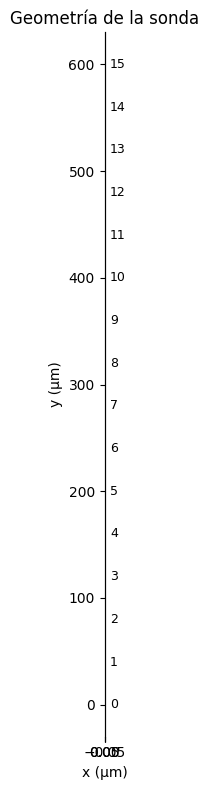

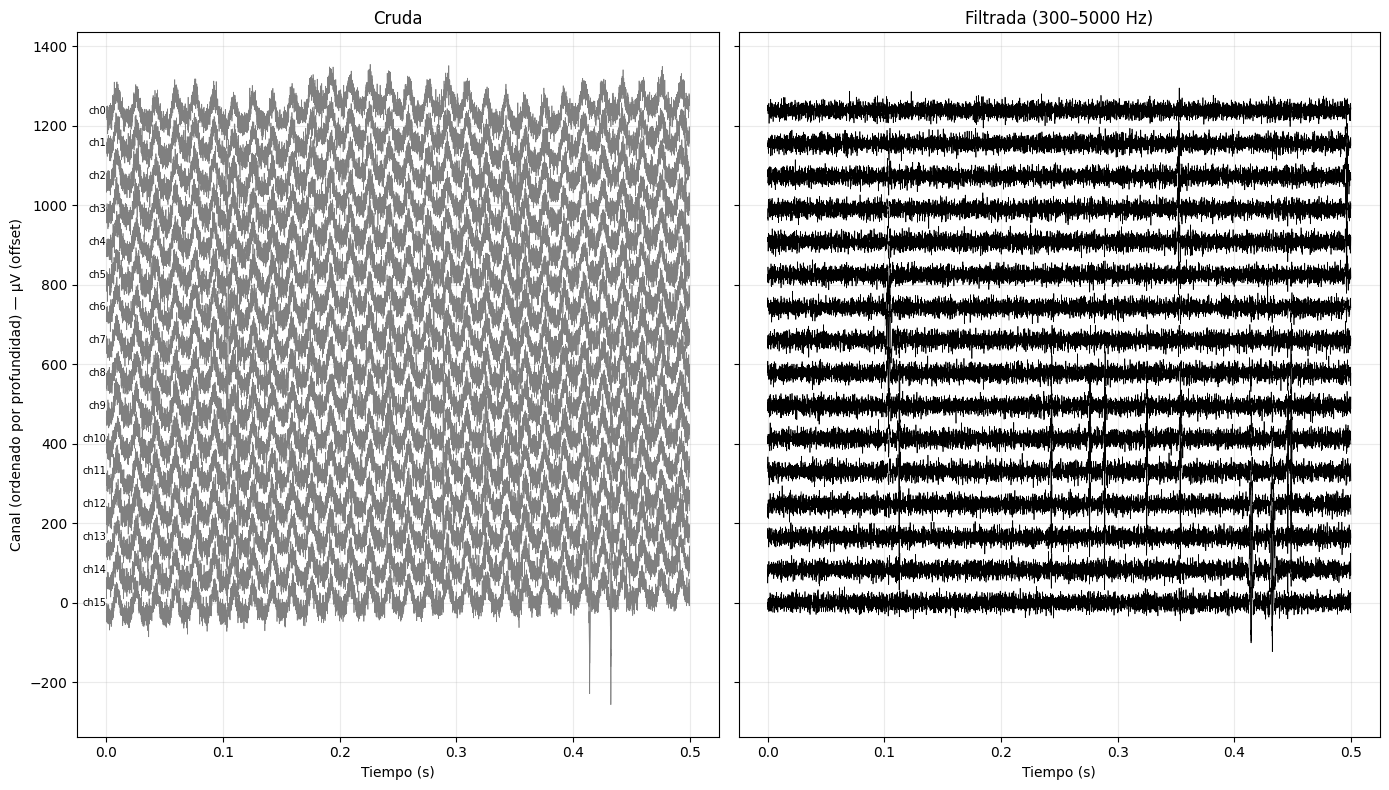

In [47]:
# ✏️ Ejercicio 1
#ver atributos del grupo
with h5py.File('taller2_limpia.h5', 'r') as f:
    def explorar(nombre, objeto):
        print(nombre, '->', objeto)
        if objeto.attrs:
            for clave, valor in objeto.attrs.items():
                print('    atributo:', clave, '=', valor)

    print("Atributos en la raíz:")
    for clave, valor in f.attrs.items():
        print('   ', clave, '=', valor)

    print("\nRecorrido completo:")
    f.visititems(explorar)

print("----------------------")
import matplotlib.pyplot as plt
import h5py
import numpy as np
from scipy.signal import butter, sosfiltfilt

#enunciado a
with h5py.File('taller2_limpia.h5', 'r') as f:
    # Atributos generales (están en la raíz)
    print("Descripción:", f.attrs['descripcion'])
    fs = f.attrs['frecuencia_muestreo_hz']
    escala_uV_por_bit = f.attrs['escala_uV_por_bit']
    n_canales = f.attrs['n_canales']
    duracion_s = f.attrs['duracion_s']
    print("Frecuencia de muestreo:", fs, "Hz")
    print("Escala µV/bit:", escala_uV_por_bit)
    print("N° de canales:", n_canales)
    print("Duración:", duracion_s, "s")

    # Posiciones de los sitios (x, y en µm)
    canal_x_um = f['geometria/canal_x_um'][:]
    canal_y_um = f['geometria/canal_y_um'][:]
    posiciones = np.column_stack([canal_x_um, canal_y_um])  # (16, 2)
    print("Forma de posiciones:", posiciones.shape)

    # Forma de la grabación
    print("Forma de registro/datos:", f['registro/datos'].shape)


#enunciado b
fig, ax = plt.subplots(figsize=(4, 8))
ax.scatter(posiciones[:, 0], posiciones[:, 1], s=80, color='steelblue')

for canal, (x, y) in enumerate(posiciones):
    ax.text(x + 5, y, str(canal), fontsize=9, va='center')

ax.set_xlabel('x (µm)')
ax.set_ylabel('y (µm)')
ax.set_title('Geometría de la sonda')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


#enunciado c
with h5py.File('taller2_limpia.h5', 'r') as f:
    fs = f.attrs['frecuencia_muestreo_hz']
    escala_uV_por_bit = f.attrs['escala_uV_por_bit']
    datos = f['registro/datos'][:]  # (16, n_muestras), cuentas ADC (int16)
    canal_x_um = f['geometria/canal_x_um'][:]
    canal_y_um = f['geometria/canal_y_um'][:]
    posiciones = np.column_stack([canal_x_um, canal_y_um])

# Conversión a microvoltios
datos_uV = datos * escala_uV_por_bit

# Filtro pasa-banda 300-5000 Hz (¡usar sosfiltfilt, no sosfilt!)
sos = butter(4, [300, 5000], btype='bandpass', fs=fs, output='sos')
datos_filtrados = sosfiltfilt(sos, datos_uV, axis=1)

# Ordenar canales por profundidad (coordenada y)
orden = np.argsort(posiciones[:, 1])[::-1]

# Ventana de medio segundo
t_inicio, t_fin = 0.0, 0.5
i0, i1 = int(t_inicio * fs), int(t_fin * fs)
t = np.arange(i0, i1) / fs

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
separacion = 6 * np.std(datos_filtrados[:, i0:i1])

for i, canal in enumerate(orden):
    offset = i * separacion
    axes[0].plot(t, datos_uV[canal, i0:i1] + offset, linewidth=0.5, color='gray')
    axes[1].plot(t, datos_filtrados[canal, i0:i1] + offset, linewidth=0.5, color='black')
    axes[0].text(t[0], offset, f'ch{canal}', fontsize=7, va='center', ha='right')

axes[0].set_title('Cruda')
axes[1].set_title('Filtrada (300–5000 Hz)')
for ax in axes:
    ax.set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Canal (ordenado por profundidad) — µV (offset)')
plt.tight_layout()
plt.show()



**P1.**

**Selección múltiple.** La amplitud cae aproximadamente como 1/r, donde r es la distancia entre la
neurona y el sitio. Una neurona está a 20 µm del sitio más cercano. Moviéndose por la sonda a partir
de ese sitio, ¿a qué distancia la amplitud habrá caído a la mitad?

- **a)** unos 35 µm: menos de lo que hay entre dos sitios vecinos
- **b)** unos 40 µm: exactamente el sitio siguiente
- **c)** unos 80 µm: dos sitios más allá
- **d)** unos 200 µm: cinco sitios más allá

**Abierta.** En la señal filtrada busquen un evento que aparezca **en los 16 canales al mismo
tiempo**. ¿Puede eso ser una neurona? Justifiquen en dos frases usando la caída 1/r.

*Su respuesta:*

**Seleccion multiple:** **a)** unos 35 µm: menos de lo que hay entre dos sitios vecinos

**Abierta:** un evento que aparece simultaneamente en los 16 canales no puede ser una neurona porque bajo una caida de 1/r su amplitud tendria que ser practicamente la misma en los sitios que estan a decenas de ciento de µm de distancia entre si y una neurona se atenua bastante en unos 100 µm.




---
# 2 · Detectar los disparos en 16 canales

## Repaso: el umbral de detección con la mediana

El umbral se pone en `k` veces el nivel de ruido. Pero hay que medir ese nivel sin que los disparos lo
contaminen: si usan la desviación estándar de la señal, los potenciales de acción la inflan, el umbral
sube y se pierde la capacidad de detectarlos. Mientras más potenciales de acción tenga el registro,
peor.

La solución es medir el ruido con la **mediana del valor absoluto de la señal**. Los disparos ocupan
menos del 1 % del tiempo de grabación, así que la mediana los excluye: describe el ruido mucho mejor
que la desviación estándar, que se calcula a partir de la media y por eso es susceptible a los valores
extremos, que son justamente los que queremos detectar.

Falta un detalle de unidades. Para una campana normal de desviación estándar σ, la mediana del valor
absoluto vale siempre 0,6745 · σ. Dividiendo por esa constante, el número queda expresado como si
fuera una desviación estándar, y entonces **`k = 4` significa que el umbral está 4 desviaciones
estándar del ruido por debajo de cero**. Cero es la media, porque el filtro ya quitó
cualquier componente de deriva lenta.

## Lo nuevo en el Taller 2

**Ahora hay 16 canales.** Un PA cruza el umbral en tres o cuatro sitios a la vez, con unas
décimas de milisegundo de diferencia. Si cuentan cada cruce por separado van a contar el mismo
potencial de acción cuatro veces.

La solución estándar tiene tres pasos:

1. Calcular un umbral **por canal** (cada sitio tiene su propio nivel de ruido).
2. Marcar todos los cruces en cada canal.
3. **Fusionar** los cruces que caen dentro de una misma ventana corta (0,5 ms) en un solo evento, y
   quedarse con el instante y el canal donde el voltaje fue **más negativo de todos**. Ese canal se
   llama el **canal pico** del evento.

### ✍️ Ejercicio 2 · Escriban su prompt

Escriban la función `detectar(X, k=4.5, muerto_ms=0.5, fs=15000)` que reciba la señal filtrada de los
16 canales y devuelva dos arreglos:
1. el instante de cada evento en segundos y
2. su canal pico.

Escríbanle a la IA un prompt que incluya los tres pasos de arriba. Dejen el prompt en la celda de
texto y el código que resultó en la celda de código, con comentarios suyos.

**Su prompt:**

Necesito una función en Python llamada detectar(X, k=4.5, muerto_ms=0.5, fs=15000) que reciba X, un arreglo de forma (16, n_muestras) con la señal ya filtrada en pasa-banda (300-5000 Hz), y devuelva dos arreglos: tiempos_s (el instante en segundos de cada evento detectado) y canal_pico (el canal donde ese evento tuvo el voltaje más negativo).

La función debe seguir estos tres pasos:

- Calcular un umbral distinto para cada uno de los 16 canales, usando la mediana del valor absoluto de la señal de ese canal dividida entre 0.6745 (para que quede en unidades equivalentes a desviación estándar), y luego el umbral es -k veces ese valor (los disparos son negativos).
- Marcar todas las muestras donde la señal cruza por debajo del umbral, en cada canal por separado.
- Como el mismo potencial de acción cruza el umbral en varios canales casi al mismo tiempo, hay que fusionar en un solo evento todos los cruces (de cualquier canal) que caigan dentro de una ventana de muerto_ms milisegundos entre sí, y quedarse solo con el instante y el canal donde el voltaje fue más negativo de todo el grupo fusionado.

Que la función esté vectorizada donde se pueda y use numpy, explicame cada parte de este codigo.

In [48]:
# ✍️ Ejercicio 2

import numpy as np

def detectar(X, k=4.5, muerto_ms=0.5, fs=15000):
    """
    Detecta potenciales de acción en una señal multicanal filtrada.

    Parámetros
    ----------
    X : array (n_canales, n_muestras)
        Señal filtrada en pasa-banda.
    k : float
        Número de "desviaciones estándar" (vía MAD) para el umbral.
    muerto_ms : float
        Ventana de fusión de cruces cercanos, en milisegundos.
    fs : float
        Frecuencia de muestreo en Hz.

    Devuelve
    --------
    tiempos_s : array
        Instante de cada evento, en segundos.
    canal_pico : array
        Canal donde ocurrió el voltaje más negativo de cada evento.
    """
    n_canales, n_muestras = X.shape

    # --- Paso 1: umbral por canal usando la mediana del valor absoluto ---
    # mediana(|x|) = 0.6745 * sigma para ruido gaussiano, así que dividimos
    # para que el número quede en unidades de "desviación estándar".
    ruido_por_canal = np.median(np.abs(X), axis=1) / 0.6745  # (n_canales,)
    umbral_por_canal = -k * ruido_por_canal  # negativo: los PA son deflexiones hacia abajo

    # --- Paso 2: marcar cruces en cada canal ---
    # Un cruce ocurre donde la señal pasa de estar por encima del umbral
    # a estar por debajo (cruce descendente), para no contar cada muestra
    # bajo el umbral como un evento distinto.
    cruces_canal = []
    cruces_muestra = []
    for c in range(n_canales):
        bajo_umbral = X[c] < umbral_por_canal[c]
        # Cruce descendente: la muestra anterior estaba arriba y la actual abajo
        cruce = np.where(bajo_umbral[1:] & ~bajo_umbral[:-1])[0] + 1
        cruces_canal.append(np.full(cruce.shape, c))
        cruces_muestra.append(cruce)

    cruces_canal = np.concatenate(cruces_canal)
    cruces_muestra = np.concatenate(cruces_muestra)

    if len(cruces_muestra) == 0:
        return np.array([]), np.array([])

    # Ordenar todos los cruces (de todos los canales juntos) por tiempo
    orden = np.argsort(cruces_muestra)
    cruces_muestra = cruces_muestra[orden]
    cruces_canal = cruces_canal[orden]

    # --- Paso 3: fusionar cruces cercanos en un solo evento ---
    muerto_muestras = int(round(muerto_ms / 1000 * fs))

    eventos_tiempo = []
    eventos_canal = []

    i = 0
    n = len(cruces_muestra)
    while i < n:
        # Agrupar todos los cruces que caen dentro de la ventana muerta
        # a partir del primer cruce del grupo
        j = i
        while j + 1 < n and (cruces_muestra[j + 1] - cruces_muestra[i]) <= muerto_muestras:
            j += 1

        # Dentro del grupo [i, j], buscar el canal y muestra con el
        # voltaje más negativo (el verdadero pico del evento)
        idx_grupo = slice(i, j + 1)
        canales_grupo = cruces_canal[idx_grupo]
        muestras_grupo = cruces_muestra[idx_grupo]

        # Ventana de búsqueda del mínimo: alrededor de los cruces del grupo
        m_ini = max(muestras_grupo.min() - muerto_muestras, 0)
        m_fin = min(muestras_grupo.max() + muerto_muestras, n_muestras)

        sub = X[np.unique(canales_grupo), m_ini:m_fin]
        canales_unicos = np.unique(canales_grupo)

        pos_min_local = np.unravel_index(np.argmin(sub), sub.shape)
        canal_pico = canales_unicos[pos_min_local[0]]
        muestra_pico = m_ini + pos_min_local[1]

        eventos_tiempo.append(muestra_pico / fs)
        eventos_canal.append(canal_pico)

        i = j + 1

    tiempos_s = np.array(eventos_tiempo)
    canal_pico = np.array(eventos_canal)

    # Reordenar por tiempo (por si el barrido de canales lo desordenó)
    orden_final = np.argsort(tiempos_s)
    return tiempos_s[orden_final], canal_pico[orden_final]

tiempos_05, canales_05 = detectar(datos_filtrados, k=4.5, muerto_ms=0.5, fs=fs)
tiempos_02, canales_02 = detectar(datos_filtrados, k=4.5, muerto_ms=0.2, fs=fs)

print(f"Con 0.5 ms: {len(tiempos_05)} eventos")
print(f"Con 0.2 ms: {len(tiempos_02)} eventos")

Con 0.5 ms: 2843 eventos
Con 0.2 ms: 4133 eventos


**P2.**

**Selección múltiple.** Vuelvan a correr la detección sobre la grabación limpia con `muerto_ms = 0.2`
en vez de 0,5. Salen más eventos. ¿De dónde salen?

- **a)** de neuronas más lejanas, que antes no cruzaban el umbral
- **b)** del mismo disparo, contado varias veces
- **c)** del umbral, que se recalcula más bajo
- **d)** del filtro, que deja pasar más ruido

**Abierta.** Digan cuántos eventos detectaron con 0,5 ms y cuántos con 0,2 ms, y expliquen en una
frase por qué 0,5 ms es una elección razonable y 5 ms no lo sería.

*Su respuesta:*

**Selección múltiple.** **b)** del mismo disparo, contado varias veces. pues un potencial de acción no cruza el umbral una sola vez de forma limpia: en su fase de repolarización puede haber un pequeño rebote o ruido que vuelve a cruzar el umbral por una fracción de milisegundo, generando un segundo cruce descendente muy cercano al primero.

**Abierta.** 0,5 ms es una elección razonable porque es más ancha que la dispersión temporal entre los cruces de un mismo disparo en distintos canales; en cambio 5 ms ya sería comparable al intervalo entre disparos consecutivos de una neurona muy activa, así que empezaría a fusionar disparos genuinamente distintos en uno solo, perdiendo eventos reales.


---
# 3 · Dos niveles de medida


Un **evento** es un potencial de acción, no un cruce del umbral. El mismo disparo cruza el
umbral en varios electrodos a la vez, y el detector fusiona esos cruces en uno solo. Para
escoger el canal pico ya tuvo que mirar los 16 canales, pero no guardó nada más.

Por eso la detección de la sección 2 devuelve **dos vectores, uno por evento**: el instante y
el canal pico. Lo primero que hace esta sección es volver a la señal filtrada y recortar una
ventana alrededor de cada instante, en los 16 canales. Ahí aparece la dimensión de canales:

- formas de onda: **eventos × 16 canales × muestras**
- perfil de amplitud, el valor del valle en cada electrodo: **eventos × 16 canales**

De ese perfil salen la amplitud y el centroide.

Todo lo que sigue se mide sobre uno de dos niveles: cada evento, o un grupo ya formado. Las
del segundo nivel no se pueden calcular antes de agrupar, así que no sirven para agrupar. Y
de las del primer nivel, **tres son las que entran a K-means**: son las de la última columna,
y son las que se explican abajo.

| medida | se mide sobre | qué es | ¿agrupa? |
|---|---|---|---|
| instante | cada evento | el momento del valle, en segundos | — |
| canal pico | cada evento | el electrodo donde el voltaje fue más negativo | — |
| perfil de amplitud | cada evento | los 16 valores del valle, uno por electrodo | — |
| **amplitud** | cada evento | el mayor de esos 16 valores | **sí** |
| **media anchura del valle** | cada evento | ancho a media profundidad, en el canal pico | **sí** |
| **centroide de profundidad** | cada evento | promedio de las posiciones, ponderado por el perfil | **sí** |
| número de disparos | un grupo | cuántos eventos quedaron en él | — |
| violaciones del refractario | un grupo | fracción de intervalos menores a 2 ms | — |
| autocorrelograma | un grupo | intervalos entre sus propios disparos | — |
| distribución de amplitudes | un grupo | histograma de la amplitud de sus eventos | — |
| pendiente de caída espacial | un grupo | cómo cae la amplitud al alejarse del canal pico | — |
| razón pico / valle | un grupo | medida sobre la forma de onda promedio del grupo | — |
| correlograma cruzado | dos grupos | intervalos entre los disparos de uno y otro | — |


En esta sección van las tres del primer nivel.


## Tres características de cada PA que van a usar para agruparlos en unidades

**1 · La amplitud.** El valor mínimo del valle en el canal pico, en microvoltios. Depende de dos cosas
a la vez: de qué tan grande sea la neurona y de qué tan cerca esté de la sonda. Recuerden: dos
neuronas distintas pueden llegar con la misma amplitud desde distancias distintas.

Las tres figuras que siguen son **el mismo evento**, medido de tres formas.

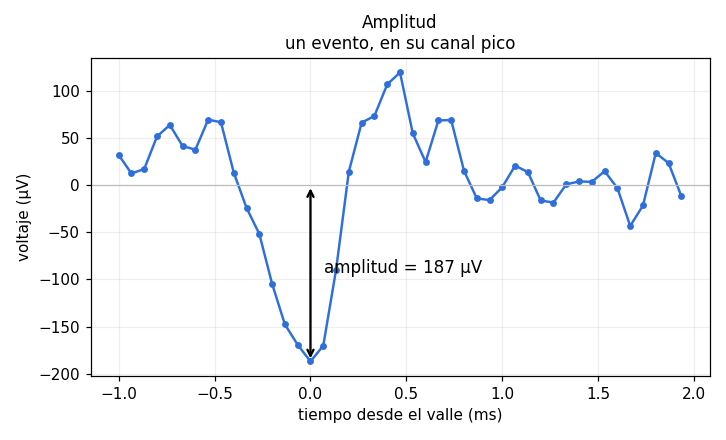

In [49]:
#Corran esta celda.
from IPython.display import Image, display
display(Image("car1_amplitud.png"))

**2 · La media anchura del valle.** El ancho del valle medido a la mitad de su profundidad, en
milisegundos. Distingue neuronas que la amplitud no distingue, porque depende del tipo de célula y no
de la distancia a la que esté.

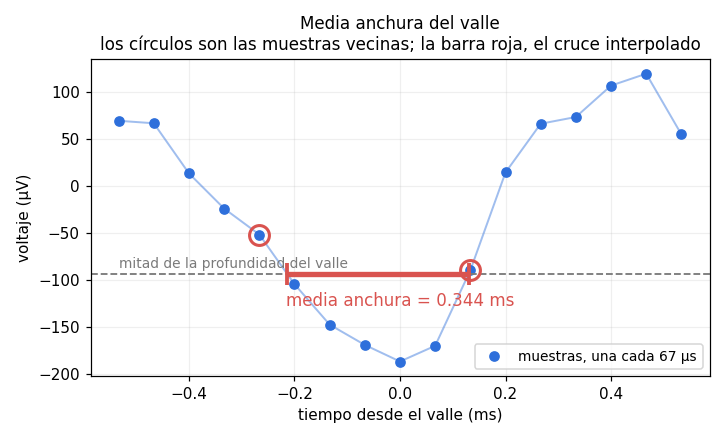

In [50]:
#Corran esta celda.
display(Image("car2_anchura.png"))

⚠️ **Trampa importante.** El potencial de acción completo dura entre 0,6 y 1,4 ms, así que a 15 000
muestras por segundo caben entre 9 y 21 muestras. El problema no es ese. Es que **la media anchura del
valle abarca sólo unas 5 muestras** en las unidades angostas y 9 en las anchas, y si la miden contando
muestras enteras, el resultado sólo puede saltar de 67 en 67 µs. Perderían resolución y no estimarían
la anchura del valle exacta: la nube de mediciones les sale como un peine. Hay que **interpolar
linealmente entre muestras** para encontrar dónde exactamente la señal cruza la mitad de la
profundidad.

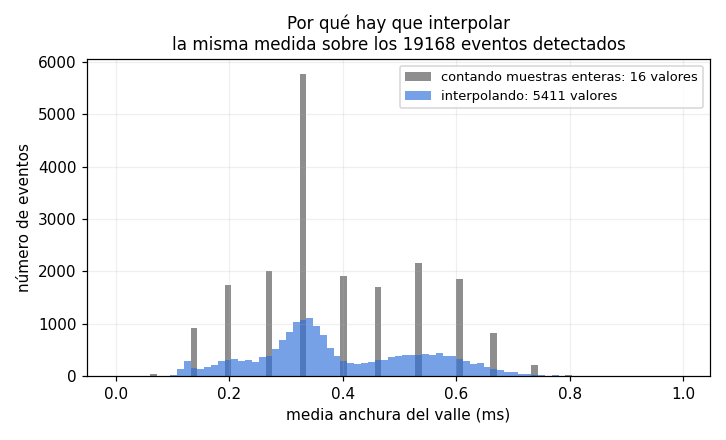

In [51]:
#Corran esta celda.
display(Image("car3_interpolar.png"))

**3 · El centroide de profundidad.** Los sitios de la sonda están en posiciones fijas: el primero a
0 µm de la punta, el segundo a 40, y así hasta 600. Un mismo disparo llega a varios sitios con
amplitudes distintas, y de ahí se estima **a qué profundidad está la neurona que lo produjo**: es el
promedio de las posiciones de los sitios, ponderado por la amplitud que el disparo alcanzó en cada
uno.

El evento de las figuras anteriores llega con 122 µV al sitio de 200 µm, 187 µV al de 240 y 69 µV al
de 280. Su centroide es

(200·122 + 240·187 + 280·69) / (122 + 187 + 69) = **234 µm**

Los otros trece sitios no entran en la cuenta. Sólo se usan aquellos donde la amplitud supera el 30 %
del máximo, que en este evento son 56 µV, porque en los sitios lejanos lo que se mide es ruido y
arrastraría el centroide hacia la mitad de la sonda.

Fíjense en algo: el centroide **se calcula sobre cada disparo, pero lo que estima es una propiedad de
la neurona**, no de ese disparo en particular. Por eso separa tan bien. Cada potencial de acción trae,
en su perfil de amplitudes, una medición ruidosa de dónde está la célula que lo disparó.

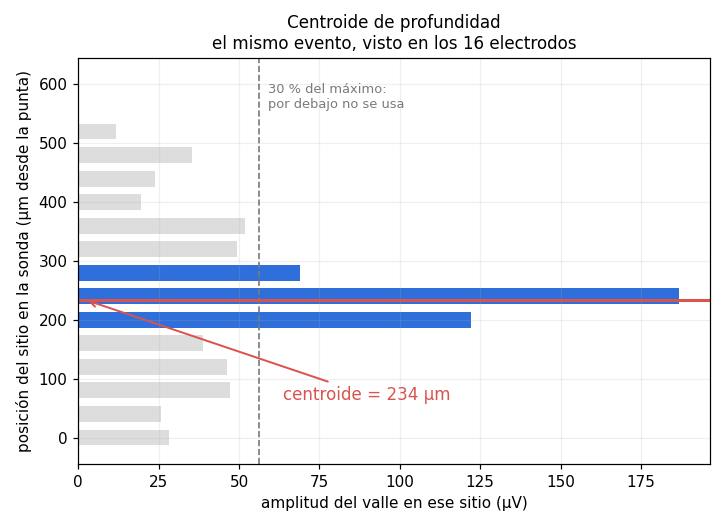

In [52]:
#Corran esta celda
display(Image("car4_centroide.png"))

### ✏️ Ejercicio 3

**a)** Extraigan la forma de onda de cada evento en los 16 canales, desde 1,0 ms antes hasta 2,0 ms
después del instante detectado. El resultado es un arreglo de tres dimensiones: eventos × canales ×
muestras.

**b)** Calculen las tres características para cada evento.

**c)** Grafiquen las tres nubes de puntos posibles con esas tres características, en tres paneles.

In [53]:
# ✏️ Ejercicio 3
# a)
import numpy as np
import matplotlib.pyplot as plt
tiempos_s = tiempos_05
canal_pico = canales_05
print("Eventos a usar:", len(tiempos_s))
# --- Ventana alrededor de cada evento: 1.0 ms antes, 2.0 ms después ---
ms_pre = 1.0
ms_post = 2.0
n_pre = int(round(ms_pre / 1000 * fs))    # muestras antes del instante detectado
n_post = int(round(ms_post / 1000 * fs))  # muestras después
n_ventana = n_pre + n_post

n_canales, n_muestras_total = datos_filtrados.shape

# Instante de cada evento, en número de muestra
muestras_evento = (tiempos_s * fs).astype(int)

# Descartar eventos cuya ventana se saldría del registro (al inicio o al final)
validos = (muestras_evento - n_pre >= 0) & (muestras_evento + n_post <= n_muestras_total)
muestras_evento = muestras_evento[validos]
tiempos_validos = tiempos_s[validos]
canal_pico_validos = canal_pico[validos]

n_eventos = len(muestras_evento)
formas_onda = np.zeros((n_eventos, n_canales, n_ventana))

for i, m in enumerate(muestras_evento):
    formas_onda[i] = datos_filtrados[:, m - n_pre : m + n_post]

print("Forma de 'formas_onda':", formas_onda.shape)  # (eventos, 16, n_ventana)

Eventos a usar: 2843
Forma de 'formas_onda': (2843, 16, 45)


In [54]:
# b)
# Eje de tiempo relativo dentro de la ventana, en ms (0 = instante detectado)
t_ventana_ms = (np.arange(n_ventana) - n_pre) / fs * 1000

amplitudes = np.zeros(n_eventos)
anchuras_ms = np.zeros(n_eventos)
centroides_um = np.zeros(n_eventos)

for i in range(n_eventos):
    canal_p = canal_pico_validos[i]
    traza_pico = formas_onda[i, canal_p, :]

    # --- 1) Amplitud: profundidad del valle en el canal pico ---
    idx_valle = np.argmin(traza_pico)
    valor_valle = traza_pico[idx_valle]      # negativo
    amplitudes[i] = -valor_valle             # magnitud positiva, en µV

    # --- 2) Media anchura del valle, CON interpolación lineal ---
    # (evita el efecto "peine" de contar solo muestras enteras)
    mitad = valor_valle / 2  # umbral a media profundidad (también negativo)

    # Cruce a la izquierda del valle
    izq = idx_valle
    while izq > 0 and traza_pico[izq] < mitad:
        izq -= 1
    if traza_pico[izq + 1] != traza_pico[izq]:
        frac = (mitad - traza_pico[izq]) / (traza_pico[izq + 1] - traza_pico[izq])
    else:
        frac = 0.0
    t_izq = t_ventana_ms[izq] + frac * (t_ventana_ms[izq + 1] - t_ventana_ms[izq])

    # Cruce a la derecha del valle
    der = idx_valle
    while der < n_ventana - 1 and traza_pico[der] < mitad:
        der += 1
    if traza_pico[der] != traza_pico[der - 1]:
        frac = (mitad - traza_pico[der - 1]) / (traza_pico[der] - traza_pico[der - 1])
    else:
        frac = 0.0
    t_der = t_ventana_ms[der - 1] + frac * (t_ventana_ms[der] - t_ventana_ms[der - 1])

    anchuras_ms[i] = t_der - t_izq

    # --- 3) Centroide de profundidad ---
    # Valor del valle en CADA canal (perfil de amplitud del evento)
    perfil = -np.min(formas_onda[i], axis=1)  # (16,), positivo

    # Solo se usan sitios con amplitud > 30% del máximo del perfil
    umbral_perfil = 0.30 * perfil.max()
    usar = perfil > umbral_perfil

    centroides_um[i] = np.sum(canal_y_um[usar] * perfil[usar]) / np.sum(perfil[usar])

print("Amplitud (µV): min={:.1f}, max={:.1f}".format(amplitudes.min(), amplitudes.max()))
print("Media anchura (ms): min={:.3f}, max={:.3f}".format(anchuras_ms.min(), anchuras_ms.max()))
print("Centroide (µm): min={:.1f}, max={:.1f}".format(centroides_um.min(), centroides_um.max()))

Amplitud (µV): min=52.5, max=276.0
Media anchura (ms): min=-1.184, max=0.910
Centroide (µm): min=85.5, max=556.7


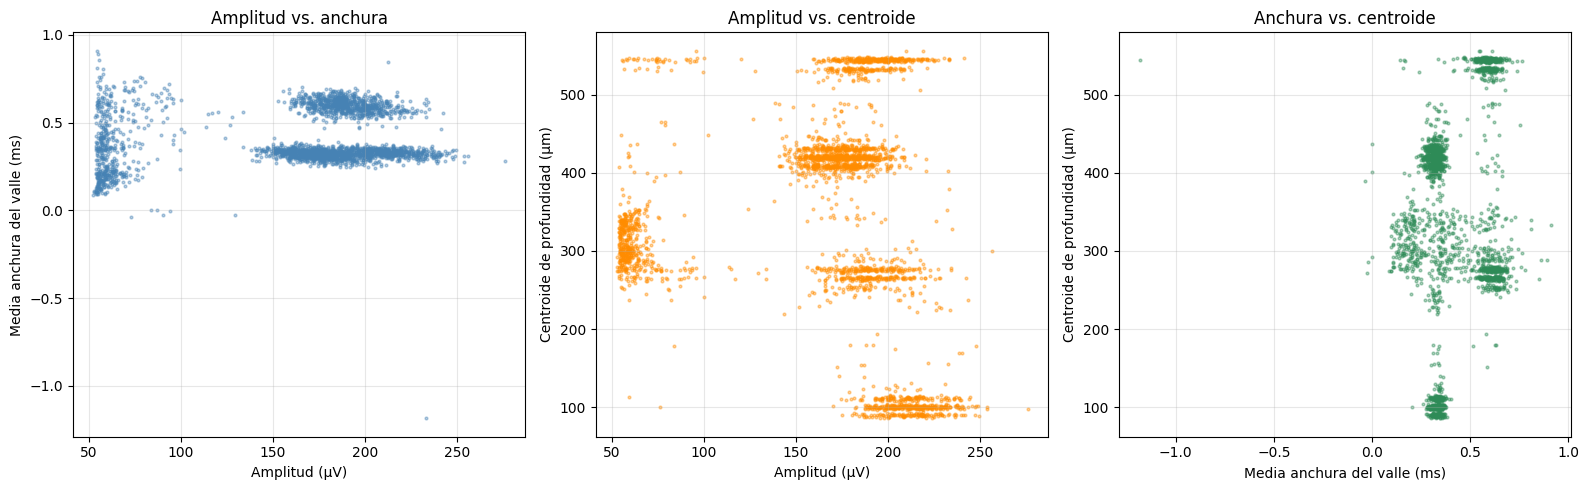

In [55]:
# c)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(amplitudes, anchuras_ms, s=4, alpha=0.4, color='steelblue')
axes[0].set_xlabel('Amplitud (µV)')
axes[0].set_ylabel('Media anchura del valle (ms)')
axes[0].set_title('Amplitud vs. anchura')

axes[1].scatter(amplitudes, centroides_um, s=4, alpha=0.4, color='darkorange')
axes[1].set_xlabel('Amplitud (µV)')
axes[1].set_ylabel('Centroide de profundidad (µm)')
axes[1].set_title('Amplitud vs. centroide')

axes[2].scatter(anchuras_ms, centroides_um, s=4, alpha=0.4, color='seagreen')
axes[2].set_xlabel('Media anchura del valle (ms)')
axes[2].set_ylabel('Centroide de profundidad (µm)')
axes[2].set_title('Anchura vs. centroide')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**P3.**

**Selección múltiple.** ¿Cuál de estas medidas **no** se puede calcular sobre un evento aislado?

- **a)** la amplitud
- **b)** la media anchura del valle
- **c)** el centroide de profundidad
- **d)** las violaciones del período refractario

**Abierta.** De los tres paneles de la nube de puntos, ¿cuál separa mejor los grupos, y por qué esa
pareja de características y no otra? Digan si hay un par de grupos que se confunda en un panel y se
separe en otro.

*Su respuesta:*

**Selección múltiple.** **d)** las violaciones del período refractario. Esto pues, son una medida "sobre un grupo"ya que se define como la fracción de intervalos entre disparos que son menores a 2 ms y un intervalo necesita al menos 2 disparos asignados a la misma unidad asi que es imposible calcularla antes de agrupar.

**Abierta.** El panel que mejor separa los grupos es amplitud vs. centroide pues se ven claramente varios grupos delimitados y hasta compactos. La razón es que estas dos características capturan información independiente y complementaria sobre la neurona: el centroide te dice dónde está y la amplitud te dice qué tan grande es la señal que produce esa neurona en su canal pico.



---
# Segunda parte · La grabación ruidosa

Aquí empieza el trabajo real. A partir de esta sección todo se hace sobre `taller2_ruidosa.h5`.

---
# 4 · La grabación ruidosa, y agrupar con K-means

Si escribieron las funciones bien, la primera parte de esta sección son cuatro líneas: cargar,
filtrar, detectar, extraer características. Nada de copiar y pegar con cambios.

⚠️ **Trampa.** Aquí es donde se paga haber dejado números escritos dentro de una función. El caso más
común es el umbral: si en la sección 2 guardaron el valor en microvoltios que les dio en la grabación
limpia, en vez de recalcular `k · MAD` sobre la señal que reciban, aquí les va a fallar en silencio.
Esta grabación tiene más ruido de fondo, así que su MAD es mayor y el umbral correcto es otro. Con el
umbral viejo, que es más bajo, van a detectar muchísimos cruces que no son disparos.

Lo mismo vale para cualquier otra cosa que hayan fijado mirando la primera grabación: el nombre del
archivo, el número de grupos, o dar por hecho que el archivo no trae protocolo de estímulos. Si les
toca abrir una función y cambiarle algo para que corra aquí, eso es lo que hay que arreglar.

Lo que van a encontrar es que aparecen muchos más eventos y que la nube de puntos ya no son cuatro
manchas limpias. Hay tres razones, y conviene tenerlas claras desde ya:

**Actividad multiunitaria (MUA).** La amplitud cae con la distancia, así que hay muchísimas neuronas
lejanas cuyos disparos llegan a la sonda debilitados. Individualmente son demasiado pequeños para
identificarlos, pero son tantos que en conjunto cruzan el umbral todo el tiempo. Forman una nube sin
fronteras, pegada al umbral por debajo. **La MUA es actividad neuronal de verdad**: son potenciales de
acción, sólo que no se puede decir de cuál neurona vino cada uno.

**Artefactos.** Eventos eléctricos o mecánicos que no son neuronales: el equipo, el movimiento del
animal, el estímulo. Cruzan el umbral y se detectan igual que un disparo.

**Cruces del umbral por ruido térmico.** El ruido de fondo es aleatorio y de vez en cuando, por azar,
baja lo suficiente. No son disparos de nada.

## K-means y el problema de elegir k

**K-means** reparte los puntos en `k` grupos, poniendo cada punto en el grupo cuyo centro le queda más
cerca. Ya lo usaron en el Taller 1. Aquí hay dos cosas nuevas.

**Hay que estandarizar las características antes.** K-means mide distancias, y las tres
características están en unidades que no se pueden comparar: el centroide va de 0 a 600 µm, la
anchura de 0,1 a 0,9 ms y la amplitud de 90 a 300 µV. Si no se corrige, la distancia queda dominada por el
centroide y las otras características no cuentan. La corrección es restarle a cada característica su
media y dividirla por su desviación estándar: exactamente el Z-score que vieron en la sesión de
estadística, usado aquí para otra cosa.

**Elegir k mal tiene dos formas de fallar, y son opuestas.**

- Si `k` es **muy pequeño**, dos neuronas distintas caen en el mismo grupo. Y hay una trampa: la nube
  de MUA es enorme, así que se lleva varios centros y deja pocos para las neuronas de verdad.
- Si `k` es **muy grande**, una sola neurona queda partida en dos grupos.

No hay forma de acertar de una. Lo que se hace en la práctica es pasarse de `k` a propósito y después
**arreglar**: descartar lo que no sirve y unir lo que quedó partido. Las secciones 5, 6 y 7 son
exactamente eso.

### ✏️ Ejercicio 4

**a)** Corran su pipeline completo sobre la grabación ruidosa y grafiquen las mismas tres nubes de la
sección 3.

**b)** Estandaricen sus tres características.

**c)** Corran K-means con al menos tres valores distintos de `k` (por ejemplo 8, 16 y 25) y grafiquen
el resultado de cada uno sobre el panel de centroide contra anchura.

**d)** Elijan un `k` para seguir trabajando.


fs: 15000   escala: 0.195   forma datos: (16, 3000000)
Eventos detectados en la grabación ruidosa: 19125
N eventos con features: 19125
Eventos totales: 19125
Descartados por anchura fuera de rango: 34
Eventos que quedan: 19091
Nueva forma de formas_onda_r: (19091, 16, 45)


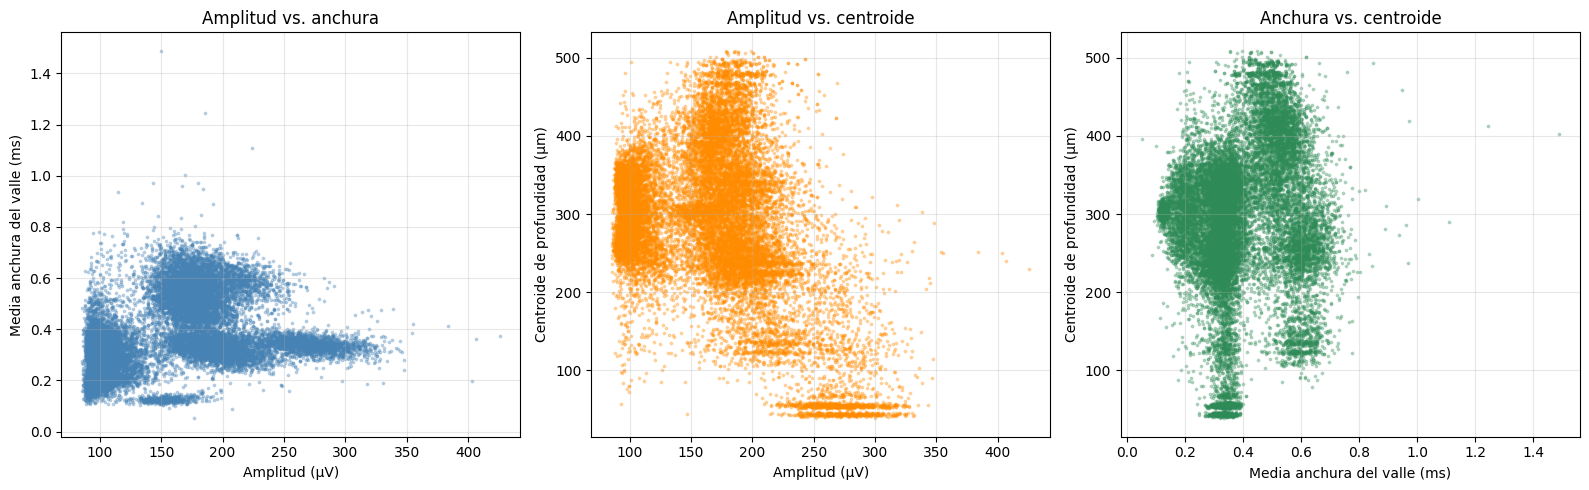

In [56]:
# ✏️ Ejercicio 4
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
from sklearn.cluster import KMeans

# --- 1. Cargar ---
with h5py.File('taller2_ruidosa.h5', 'r') as f:
    fs_r = f.attrs['frecuencia_muestreo_hz']
    escala_uV_por_bit_r = f.attrs['escala_uV_por_bit']
    datos_r = f['registro/datos'][:]
    canal_x_um_r = f['geometria/canal_x_um'][:]
    canal_y_um_r = f['geometria/canal_y_um'][:]

print("fs:", fs_r, "  escala:", escala_uV_por_bit_r, "  forma datos:", datos_r.shape)

# --- 2. Convertir a µV y filtrar en pasa-banda ---
datos_uV_r = datos_r * escala_uV_por_bit_r
sos_r = butter(4, [300, 5000], btype='bandpass', fs=fs_r, output='sos')
datos_filtrados_r = sosfiltfilt(sos_r, datos_uV_r, axis=1)

# --- 3. Detectar (el umbral se recalcula solo sobre esta señal) ---
tiempos_s_r, canal_pico_r = detectar(datos_filtrados_r, k=4.5, muerto_ms=0.5, fs=fs_r)
print("Eventos detectados en la grabación ruidosa:", len(tiempos_s_r))

# --- 4. Extraer características ---
def extraer_caracteristicas(datos_filtrados, tiempos_s, canal_pico, canal_y_um, fs,
                              ms_pre=1.0, ms_post=2.0):
    n_pre = int(round(ms_pre / 1000 * fs))
    n_post = int(round(ms_post / 1000 * fs))
    n_ventana = n_pre + n_post
    n_canales, n_muestras_total = datos_filtrados.shape

    muestras_evento = (tiempos_s * fs).astype(int)
    validos = (muestras_evento - n_pre >= 0) & (muestras_evento + n_post <= n_muestras_total)
    muestras_evento = muestras_evento[validos]
    tiempos_validos = tiempos_s[validos]
    canal_pico_validos = canal_pico[validos]

    n_eventos = len(muestras_evento)
    formas_onda = np.zeros((n_eventos, n_canales, n_ventana))
    for i, m in enumerate(muestras_evento):
        formas_onda[i] = datos_filtrados[:, m - n_pre : m + n_post]

    t_ventana_ms = (np.arange(n_ventana) - n_pre) / fs * 1000
    amplitudes = np.zeros(n_eventos)
    anchuras_ms = np.zeros(n_eventos)
    centroides_um = np.zeros(n_eventos)

    for i in range(n_eventos):
        canal_p = canal_pico_validos[i]
        traza_pico = formas_onda[i, canal_p, :]

        idx_valle = np.argmin(traza_pico)
        valor_valle = traza_pico[idx_valle]
        amplitudes[i] = -valor_valle

        mitad = valor_valle / 2
        izq = idx_valle
        while izq > 0 and traza_pico[izq] < mitad:
            izq -= 1
        if traza_pico[izq + 1] != traza_pico[izq]:
            frac = (mitad - traza_pico[izq]) / (traza_pico[izq + 1] - traza_pico[izq])
        else:
            frac = 0.0
        t_izq = t_ventana_ms[izq] + frac * (t_ventana_ms[izq + 1] - t_ventana_ms[izq])

        der = idx_valle
        while der < n_ventana - 1 and traza_pico[der] < mitad:
            der += 1
        if traza_pico[der] != traza_pico[der - 1]:
            frac = (mitad - traza_pico[der - 1]) / (traza_pico[der] - traza_pico[der - 1])
        else:
            frac = 0.0
        t_der = t_ventana_ms[der - 1] + frac * (t_ventana_ms[der] - t_ventana_ms[der - 1])

        anchuras_ms[i] = t_der - t_izq

        perfil = -np.min(formas_onda[i], axis=1)
        umbral_perfil = 0.30 * perfil.max()
        usar = perfil > umbral_perfil
        centroides_um[i] = np.sum(canal_y_um[usar] * perfil[usar]) / np.sum(perfil[usar])

    return amplitudes, anchuras_ms, centroides_um, formas_onda, tiempos_validos, canal_pico_validos

amplitudes_r, anchuras_ms_r, centroides_um_r, formas_onda_r, tiempos_s_r, canal_pico_r = \
    extraer_caracteristicas(datos_filtrados_r, tiempos_s_r, canal_pico_r, canal_y_um_r, fs_r)

print("N eventos con features:", len(amplitudes_r))

# La media anchura del valle debe ser positiva y coherente con la duración
# fisiológica de un PA (ancho completo 0.6-1.4 ms). Valores como 20-26 ms
# no son neuronas: son fallas de interpolación (el valle no tuvo una forma
# limpia dentro de la ventana). Los descartamos ANTES de estandarizar,
# porque inflan la desviación estándar y arruinan el Z-score de todos.
anchura_min = 0.05   # ms
anchura_max = 1.5    # ms

mascara_valida = (anchuras_ms_r > anchura_min) & (anchuras_ms_r < anchura_max)

print(f"Eventos totales: {len(anchuras_ms_r)}")
print(f"Descartados por anchura fuera de rango: {(~mascara_valida).sum()}")
print(f"Eventos que quedan: {mascara_valida.sum()}")

# Aplicar la máscara a TODAS las variables por evento, para que sigan alineadas
amplitudes_r = amplitudes_r[mascara_valida]
anchuras_ms_r = anchuras_ms_r[mascara_valida]
centroides_um_r = centroides_um_r[mascara_valida]
tiempos_s_r = tiempos_s_r[mascara_valida]
canal_pico_r = canal_pico_r[mascara_valida]
formas_onda_r = formas_onda_r[mascara_valida]

print("Nueva forma de formas_onda_r:", formas_onda_r.shape)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(amplitudes_r, anchuras_ms_r, s=3, alpha=0.3, color='steelblue')
axes[0].set_xlabel('Amplitud (µV)'); axes[0].set_ylabel('Media anchura del valle (ms)')
axes[0].set_title('Amplitud vs. anchura')

axes[1].scatter(amplitudes_r, centroides_um_r, s=3, alpha=0.3, color='darkorange')
axes[1].set_xlabel('Amplitud (µV)'); axes[1].set_ylabel('Centroide de profundidad (µm)')
axes[1].set_title('Amplitud vs. centroide')

axes[2].scatter(anchuras_ms_r, centroides_um_r, s=3, alpha=0.3, color='seagreen')
axes[2].set_xlabel('Media anchura del valle (ms)'); axes[2].set_ylabel('Centroide de profundidad (µm)')
axes[2].set_title('Anchura vs. centroide')

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
# b)
X_features = np.column_stack([amplitudes_r, anchuras_ms_r, centroides_um_r])

medias = X_features.mean(axis=0)
desviaciones = X_features.std(axis=0)
X_estandarizado = (X_features - medias) / desviaciones

print("Medias:", medias)
print("Desviaciones:", desviaciones)
print("Forma:", X_estandarizado.shape)

Medias: [169.17984235   0.39330278 286.73148744]
Desviaciones: [ 53.61805411   0.14266011 100.09287518]
Forma: (19091, 3)


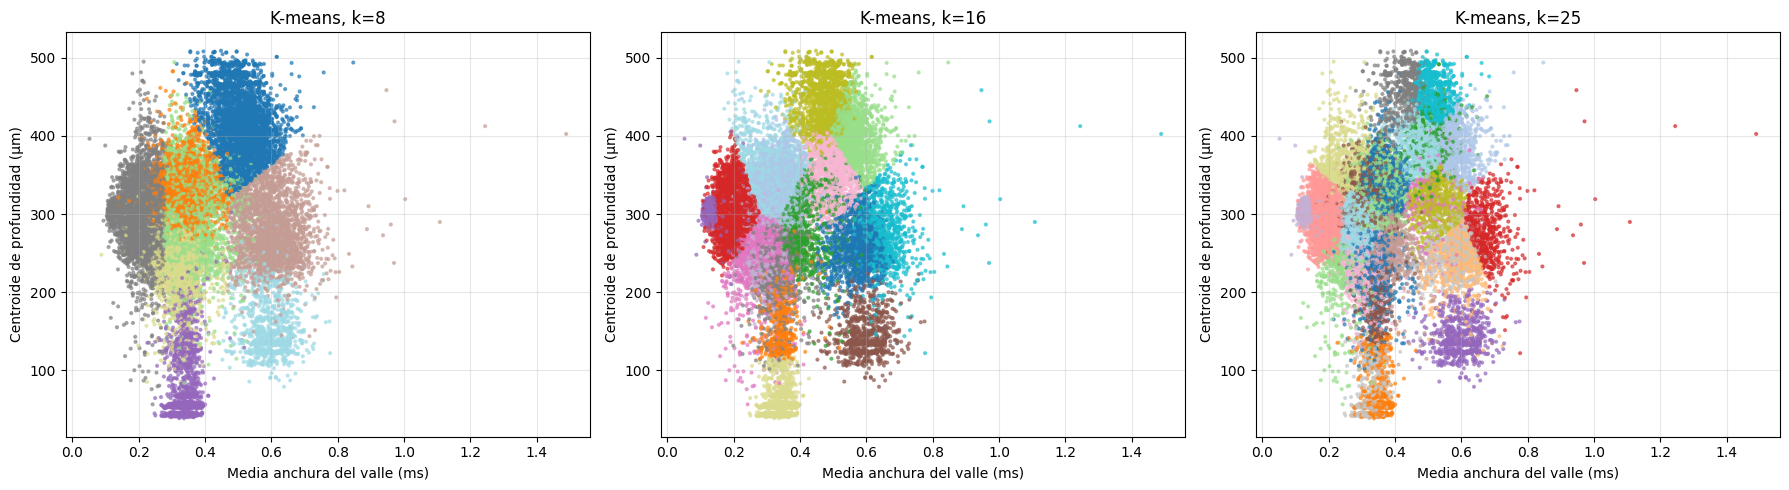

In [58]:
# c)
valores_k = [8, 16, 25]
etiquetas_por_k = {}

fig, axes = plt.subplots(1, len(valores_k), figsize=(6 * len(valores_k), 5))

for ax, k in zip(axes, valores_k):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    etiquetas = km.fit_predict(X_estandarizado)
    etiquetas_por_k[k] = etiquetas

    dispersion = ax.scatter(anchuras_ms_r, centroides_um_r, c=etiquetas,
                             cmap='tab20', s=4, alpha=0.6)
    ax.set_xlabel('Media anchura del valle (ms)')
    ax.set_ylabel('Centroide de profundidad (µm)')
    ax.set_title(f'K-means, k={k}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
# Elegimos k = 16 para seguir trabajando: nos pasamos de k a propósito,
# como indica el enunciado, para no fusionar de entrada dos neuronas
# distintas en el mismo grupo. Las secciones 5, 6 y 7 se encargan de
# descartar lo que resulte ser MUA/ruido y de unir lo que haya quedado
# partido en más de un grupo.
k_elegido = 16
etiquetas = etiquetas_por_k[k_elegido]

print(f"Usando k = {k_elegido}")
print("Eventos por grupo:")
for grupo in range(k_elegido):
    print(f"  Grupo {grupo}: {np.sum(etiquetas == grupo)} eventos")

Usando k = 16
Eventos por grupo:
  Grupo 0: 1267 eventos
  Grupo 1: 1729 eventos
  Grupo 2: 554 eventos
  Grupo 3: 1036 eventos
  Grupo 4: 1389 eventos
  Grupo 5: 1819 eventos
  Grupo 6: 506 eventos
  Grupo 7: 996 eventos
  Grupo 8: 765 eventos
  Grupo 9: 1266 eventos
  Grupo 10: 1066 eventos
  Grupo 11: 1431 eventos
  Grupo 12: 1460 eventos
  Grupo 13: 1300 eventos
  Grupo 14: 941 eventos
  Grupo 15: 1566 eventos


In [60]:
import pandas as pd

etiquetas_8 = etiquetas_por_k[8]
etiquetas_16 = etiquetas_por_k[16]
etiquetas_25 = etiquetas_por_k[25]

# --- ¿Qué grupos de k=16 quedaron FUSIONADOS dentro de un mismo grupo de k=8? ---
# Si un grupo de k=8 contiene eventos que en k=16 se reparten en 2+ grupos
# grandes, eso es evidencia de que k=8 fusionó dos cosas distintas.
tabla_8_vs_16 = pd.crosstab(etiquetas_8, etiquetas_16)
print("Grupos de k=16 dentro de cada grupo de k=8:")
print(tabla_8_vs_16)

# Para cada grupo de k=8, cuántos grupos "grandes" de k=16 contiene
# (grandes = al menos 15% de los eventos de ese grupo de k=8)
for g8 in tabla_8_vs_16.index:
    fila = tabla_8_vs_16.loc[g8]
    total = fila.sum()
    grandes = fila[fila > 0.15 * total]
    if len(grandes) >= 2:
        print(f"\nGrupo {g8} de k=8 (n={total}) parece contener >=2 subgrupos:")
        print(grandes)

# --- ¿Qué grupo de k=16 quedó PARTIDO en dos dentro de k=25? ---
tabla_16_vs_25 = pd.crosstab(etiquetas_16, etiquetas_25)
for g16 in tabla_16_vs_25.index:
    fila = tabla_16_vs_25.loc[g16]
    total = fila.sum()
    grandes = fila[fila > 0.3 * total]
    if len(grandes) >= 2:
        print(f"\nGrupo {g16} de k=16 (n={total}) se parte en k=25:")
        print(grandes)

Grupos de k=16 dentro de cada grupo de k=8:
col_0    0     1    2     3     4     5    6    7    8    9    10    11    12  \
row_0                                                                           
0         2     0    0     1  1266     0    0    0    0    0  650     0  1421   
1         7  1722    0     0     0     0   16   93    0    0  133   102    39   
2         0     3    0  1004     0     4    0    0    0  744   16    11     0   
3         0     0  425     0     0     0    0    0    0    0    0     0     0   
4      1110     0    0    31   123     0    0    0    0    0  267     0     0   
5         0     0    0     0     0  1815  480    0    0  509    0     0     0   
6        19     4  127     0     0     0   10  903    1   13    0  1316     0   
7       129     0    2     0     0     0    0    0  764    0    0     2     0   

col_0    13   14    15  
row_0                   
0         0    0    10  
1         0    0    21  
2         0    0  1180  
3      1300    0    

**P4.**

**Selección múltiple.** En la grabación ruidosa aparece una nube ancha, sin fronteras, pegada al
umbral por debajo. ¿De qué está hecha, sobre todo?

- **a)** de artefactos del equipo
- **b)** de actividad multiunitaria: disparos reales de neuronas demasiado lejanas para identificarlas
- **c)** de cruces del umbral por ruido térmico, y de nada más
- **d)** de una sola neurona cuya amplitud varía mucho

**Abierta.** ¿Qué `k` escogieron y con qué argumento? No vale "porque se ve bien": señalen un grupo
que con el `k` más pequeño se vea como dos cosas pegadas, y uno que con el `k` más grande se vea como
la mitad de otro, y digan en qué se nota cada cosa.

*Su respuesta:*

**Selección múltiple:** **b)** de actividad multiunitaria: disparos reales de neuronas demasiado lejanas para identificarlas, esto pues en el enunciado se dice claramente que la amplitud cae con la distancia 1/r asi que hay muchas neuronas alejadas de la sonda cuyos disparos llegan debilitados, pero en conjunto cruzan el umbral creando esa nube sin bordes definidos sobre el umbral.


**Abierta.** Elijo k = 16 pues está en el punto donde ya separó las fusiones más evidentes de k = 8 (como el Grupo 6), pero todavía no fragmenta de más como sí lo hace k = 25 con grupos que en k = 16 ya se veían razonablemente unimodales y compactos. Es coherente con la estrategia que propone el enunciado: pasarse un poco de k a propósito, sabiendo que las secciones 5-7 se van a encargar de fusionar lo que aquí haya quedado partido (como el Grupo 1) y de descartar lo que resulte ser MUA o artefacto — no de reducir grupos que ya fusionan cosas distintas, que es un error mucho más difícil de corregir después.



---
# 5 · Las métricas de calidad

Aquí es donde este taller se separa de lo que hace un programa automático. Ya tienen grupos. La
pregunta es cuáles de esos grupos son una neurona.

Estamos en el **segundo nivel de medida** del que habla la sección 3: todo lo que sigue se calcula
sobre un grupo entero, no sobre un disparo suelto. Varias de estas medidas se sacan de la **forma de
onda promedio** del grupo, que es más limpia que cualquier disparo individual porque el ruido se
cancela al promediar.

Son siete medidas tomadas de **bombcell**, una herramienta publicada que hace control de calidad sobre
datos ya agrupados. Los umbrales son los suyos, ajustados a esta sonda.

| medida | qué es | umbral | qué decide |
|---|---|---|---|
| número de picos y valles | Un potencial de acción tiene un valle y a lo sumo dos picos. Si la forma promedio oscila, no es una neurona. | picos ≤ 2 y valles ≤ 2 | ¿es de origen neuronal? |
| duración de la onda | Tiempo del valle al pico de repolarización. | entre 100 y 1150 µs | ¿es de origen neuronal? |
| pendiente de caída espacial | Ajuste de la amplitud contra la distancia al canal pico, en amplitud normalizada por µm. Una neurona se apaga con la distancia; un artefacto llega casi igual a toda la sonda. | más negativa que −0,004 | ¿es de origen neuronal? |
| razón pico / valle | Altura del pico positivo más grande dividida por la profundidad del valle. | por encima de 0,8 es **no somática** | ¿qué parte de la neurona se registró? |
| violaciones del refractario | Fracción de intervalos entre disparos menores a 2 ms. Una neurona no puede dispararse dos veces tan seguido, así que si los hay es porque hay más de una en el grupo. | menos de 1,5 % | ¿una neurona o varias? |
| disparos faltantes | Se ajusta una campana a la distribución de amplitudes. Si el umbral de detección cortó la cola baja, el grupo está incompleto. | menos de 20 % | ¿una neurona o varias? |
| número de disparos | Con muy pocos disparos ninguna de las otras medidas es confiable. | al menos 300 | ¿una neurona o varias? |

Dos notas sobre los umbrales de esta tabla:

**Los valles.** Bombcell exige uno solo; aquí se admiten dos, porque el filtro pasa-banda le agrega un
rizado a las ondas predominantemente positivas y si no las marcaría como ruido.

**La pendiente.** En esta sonda los sitios están cada 40 µm, así que dentro de los 100 µm del ajuste
caben apenas tres. Con tan pocos puntos el criterio es débil: en este registro el artefacto da −0,0042
y la actividad multiunitaria −0,0058, mientras que las unidades bien aisladas dan entre −0,0077 y
−0,0090. **La pendiente sola no alcanza a separar el artefacto**, y quien lo atrapa es el número de
picos. Si suben el umbral para atrapar el artefacto, empiezan a marcar como ruido actividad
multiunitaria que sí es neuronal.

**Por qué la razón pico / valle sube cuando no se registra la zona de disparo.** El electrodo
extracelular no mide el voltaje de la membrana: mide **las corrientes que entran y salen de ella**.
Donde la corriente entra, que es el punto activo por donde pasa el sodio, el exterior se vuelve
negativo, y ese es el valle. Esa corriente tiene que salir por otro lado de la célula, y donde sale el
exterior se vuelve positivo: esos son los picos.

Si el electrodo está junto a la zona donde nace el disparo, domina la corriente que entra: valle
profundo y picos pequeños. Si está sobre un axón por el que el disparo va pasando, ve la onda llegar y
alejarse, y delante y detrás del punto activo la corriente está saliendo, así que los picos crecen
hasta igualar o superar al valle. Junto a una dendrita pasa algo parecido, porque lo que llega ahí es
sobre todo corriente de retorno.

No es que la neurona sea distinta: es que el electrodo está en otra parte de ella. Bombcell llama
**no somáticas** a esas unidades. Son señal neuronal legítima, pero su centroide de profundidad no
dice dónde está el cuerpo de la célula, porque un axón puede venir de lejos.

### Las dos figuras de esta sección

La caída espacial y la razón pico/valle son las dos que menos se entienden por escrito. Así se ven
sobre este mismo registro.

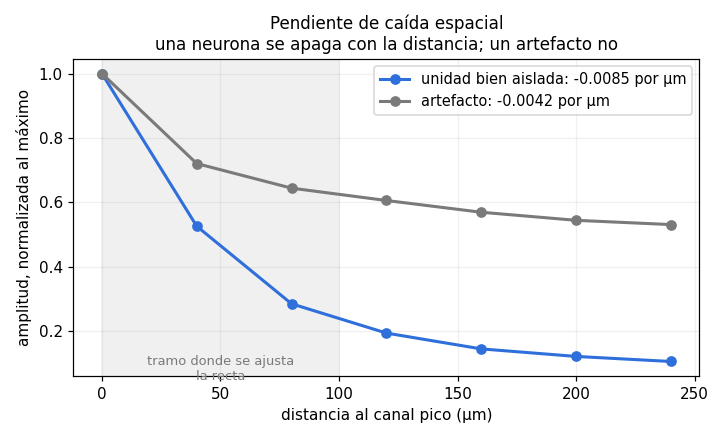

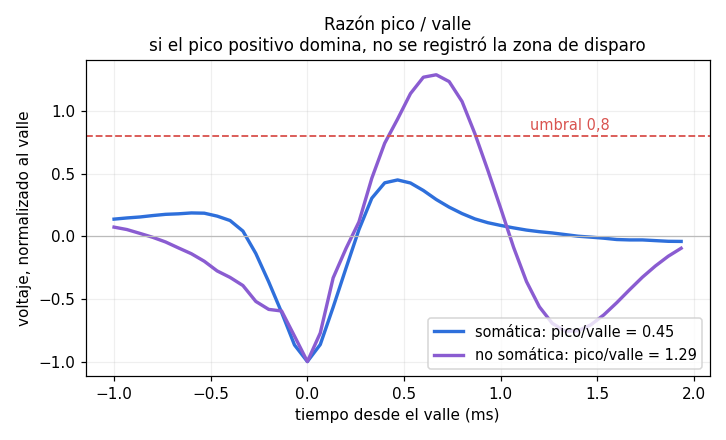

In [61]:
from IPython.display import Image, display
for f in ["car5_caida.png", "car6_razon.png"]:
    display(Image(f))

### ✍️ Ejercicio 5 · Escriban su prompt

Calculen las siete medidas para cada uno de sus grupos y armen una tabla, una fila por grupo.

⚠️ **Trampa: alinear antes de promediar.** Dentro de un grupo no todos los eventos tienen el pico en
el mismo sitio. Si promedian los 16 canales tal cual, están sumando perfiles corridos unos respecto a
otros, y la suma sale aplanada: el grupo parece no decaer con la distancia y lo van a marcar como
ruido, aunque cada evento por separado decaiga bien.

Hay que medir la caída **respecto al canal pico de cada evento**:

1. Para cada evento, tomen la amplitud del valle en los 16 sitios y divídanla por su máximo.
2. Anoten cada uno de esos valores junto con su distancia al canal pico **de ese evento**.
3. Junten los pares de todos los eventos y ajusten una recta, usando sólo las distancias de 100 µm
   o menos.

**Disparos faltantes.** Los disparos de una misma neurona no llegan todos con la misma amplitud:
varían alrededor de un valor típico, así que su histograma tiene forma de campana. Si la neurona es
pequeña o está lejos, **la parte baja de esa campana cae por debajo del umbral de detección**. Esos
disparos ocurrieron, pero nunca se detectaron: están faltando en el grupo, y por eso la tasa de
disparo que midan va a ser menor que la real.

Para estimar cuántos faltan:

1. Hagan el histograma de amplitudes del grupo.
2. Ajusten una campana usando **sólo la mitad que queda por encima del pico del histograma**, que es
   la parte que el umbral no alcanzó a cortar.
3. Calculen qué fracción de esa campana ajustada queda por debajo del umbral. Esa es la estimación de
   lo que falta.

Si el ajuste no converge, eso ya es una respuesta: la distribución no tiene forma de campana, así que
el grupo no es una sola neurona.

**Su prompt:**

tengo grupos de potenciales de acción obtenidos con K-means, cada uno con eventos que tienen: un instante de disparo, un canal pico, y una forma de onda de 16 canales x 45 muestras (ventana de 1 ms antes a 2 ms después del valle, a 15000 Hz). necesito una función que calcule 7 métricas de calidad por grupo:

- número de picos y valles en la forma de onda promedio del grupo (contados en el canal pico dominante del grupo).
- Duración de la onda: tiempo en microsegundos del valle al primer pico de repolarización después de él, en la forma de onda promedio.
- pendiente de caída espacial: para cada evento del grupo, normalizar la amplitud del valle en los 16 canales dividiendo por el máximo (que está en su propio canal pico), emparejar cada valor con la distancia de ese canal al canal pico de ESE evento, juntar todos los pares de todos los eventos del grupo, quedarse solo con distancias ≤100 µm, y ajustar una recta.
- razón pico/valle: en la forma de onda promedio, el valor positivo más alto dividido entre el valor absoluto del valle.
- violaciones del refractario: fración de intervalos entre disparos consecutivos del grupo que sean menores a 2 ms.
- disparos faltantes: histograma de amplitudes del grupo, ajustar una gaussiana usando solo la mitad de la distribución que queda por encima del pico del histograma (la que no fue cortada por el umbral de detección), y calcular qué fracción de esa gaussiana ajustada cae por debajo del umbral de detección real de ese canal.
- número de disparos: el conteo de eventos del grupo.

ahora arma una tabla (DataFrame de pandas) con una fila por grupo y una columna por métrica, más una columna que diga si cada criterio pasa el umbral de bombcell, no te olvides de explicarme cada paso.

In [62]:
# ✍️ Ejercicio 5
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import norm

# --- Eje de tiempo de la ventana (igual que en la sección 3) ---
n_pre = int(round(1.0 / 1000 * fs_r))
n_post = int(round(2.0 / 1000 * fs_r))
n_ventana = n_pre + n_post
t_ventana_ms = (np.arange(n_ventana) - n_pre) / fs_r * 1000

# --- Umbral de detección real, por canal (el mismo cálculo que usa detectar()) ---
k_deteccion = 4.5
ruido_por_canal = np.median(np.abs(datos_filtrados_r), axis=1) / 0.6745
umbral_por_canal_uV = k_deteccion * ruido_por_canal  # en µV, positivo

etiquetas = etiquetas_por_k[16]
grupos = np.unique(etiquetas)

filas = []

for g in grupos:
    idx_grupo = np.where(etiquetas == g)[0]
    n_disparos = len(idx_grupo)

    # Canal pico dominante del grupo (el más frecuente entre sus eventos)
    canal_dominante = np.bincount(canal_pico_r[idx_grupo]).argmax()

    # --- Forma de onda promedio en el canal dominante ---
    # No hace falta alinear en tiempo: el valle ya cae en la muestra n_pre
    # en todos los eventos, porque la ventana se extrajo respecto al instante detectado.
    trazas_canal_dominante = formas_onda_r[idx_grupo, canal_dominante, :]
    onda_promedio = trazas_canal_dominante.mean(axis=0)

    # --- 1) Número de picos y valles ---
    prominencia_min = 0.15 * (onda_promedio.max() - onda_promedio.min())
    picos, _ = find_peaks(onda_promedio, prominence=prominencia_min)
    valles, _ = find_peaks(-onda_promedio, prominence=prominencia_min)
    n_picos = len(picos)
    n_valles = len(valles)

    # --- 2) Duración de la onda: valle -> pico de repolarización ---
    idx_valle_prom = np.argmin(onda_promedio)
    picos_despues = picos[picos > idx_valle_prom]
    if len(picos_despues) > 0:
        idx_pico_repolarizacion = picos_despues[0]
        duracion_us = (t_ventana_ms[idx_pico_repolarizacion] - t_ventana_ms[idx_valle_prom]) * 1000
    else:
        duracion_us = np.nan

    # --- 3) Pendiente de caída espacial ---
    distancias_todas = []
    amplitudes_norm_todas = []
    for i in idx_grupo:
        canal_p = canal_pico_r[i]
        perfil_valle = -np.min(formas_onda_r[i], axis=1)  # (16,), positivo
        maximo = perfil_valle[canal_p]
        if maximo <= 0:
            continue
        perfil_norm = perfil_valle / maximo
        dist = np.abs(canal_y_um_r - canal_y_um_r[canal_p])
        distancias_todas.append(dist)
        amplitudes_norm_todas.append(perfil_norm)

    distancias_todas = np.concatenate(distancias_todas)
    amplitudes_norm_todas = np.concatenate(amplitudes_norm_todas)
    cerca = distancias_todas <= 100
    if cerca.sum() >= 2:
        pendiente, _ = np.polyfit(distancias_todas[cerca], amplitudes_norm_todas[cerca], 1)
    else:
        pendiente = np.nan

    # --- 4) Razón pico / valle ---
    valle_prom = onda_promedio.min()
    pico_prom = onda_promedio.max()
    razon_pico_valle = pico_prom / abs(valle_prom)

    # --- 5) Violaciones del refractario ---
    tiempos_grupo = np.sort(tiempos_s_r[idx_grupo])
    if len(tiempos_grupo) >= 2:
        intervalos = np.diff(tiempos_grupo)
        frac_violaciones = np.mean(intervalos < 0.002)
    else:
        frac_violaciones = np.nan

    # --- 6) Disparos faltantes ---
    amps_grupo = amplitudes_r[idx_grupo]
    conteo, bordes = np.histogram(amps_grupo, bins=30)
    idx_pico_hist = np.argmax(conteo)
    moda_amplitud = (bordes[idx_pico_hist] + bordes[idx_pico_hist + 1]) / 2

    mitad_alta = amps_grupo[amps_grupo >= moda_amplitud]
    umbral_canal_uV = umbral_por_canal_uV[canal_dominante]

    if len(mitad_alta) >= 10:
        # Desviación estándar de un lado, reflejando la mitad alta alrededor de la moda
        std_estimada = np.sqrt(np.mean((mitad_alta - moda_amplitud) ** 2))
        frac_faltante = norm.cdf(umbral_canal_uV, loc=moda_amplitud, scale=std_estimada)
    else:
        frac_faltante = np.nan  # no convergió: no hay suficientes datos para ajustar

    filas.append({
        'grupo': g,
        'n_disparos': n_disparos,
        'n_picos': n_picos,
        'n_valles': n_valles,
        'duracion_us': duracion_us,
        'pendiente_caida': pendiente,
        'razon_pico_valle': razon_pico_valle,
        'frac_violaciones_refractario': frac_violaciones,
        'frac_disparos_faltantes': frac_faltante,
    })

tabla = pd.DataFrame(filas)

# --- Columnas de evaluación contra los umbrales de la tabla del enunciado ---
tabla['ok_picos_valles'] = (tabla['n_picos'] <= 2) & (tabla['n_valles'] <= 2)
tabla['ok_duracion'] = tabla['duracion_us'].between(100, 1150)
tabla['ok_pendiente'] = tabla['pendiente_caida'] < -0.004
tabla['no_somatica'] = tabla['razon_pico_valle'] > 0.8
tabla['ok_refractario'] = tabla['frac_violaciones_refractario'] < 0.015
tabla['ok_completitud'] = tabla['frac_disparos_faltantes'] < 0.20
tabla['ok_n_disparos'] = tabla['n_disparos'] >= 300

tabla['es_neuronal'] = (tabla['ok_picos_valles'] & tabla['ok_duracion'] & tabla['ok_pendiente'])
tabla['es_una_sola_neurona'] = (tabla['ok_refractario'] & tabla['ok_completitud'] & tabla['ok_n_disparos'])

pd.set_option('display.max_columns', None)
tabla.round(4)

,grupo,n_disparos,n_picos,n_valles,duracion_us,pendiente_caida,razon_pico_valle,frac_violaciones_refractario,frac_disparos_faltantes,ok_picos_valles,ok_duracion,ok_pendiente,no_somatica,ok_refractario,ok_completitud,ok_n_disparos,es_neuronal,es_una_sola_neurona
0,0,1267,1,1,933.3333,-0.0069,0.6012,0.0276,0.0002,True,True,True,False,False,True,True,True,False
1,1,1729,1,1,533.3333,-0.0072,0.4955,0.0295,0.0000,True,True,True,False,False,True,True,True,False
2,2,554,1,1,466.6667,-0.0081,0.4854,0.0127,0.0000,True,True,True,False,True,True,True,True,True
3,3,1036,1,1,666.6667,-0.0034,0.5063,0.0048,0.3360,True,True,False,False,True,False,True,False,False
4,4,1389,1,1,866.6667,-0.0067,0.6210,0.0973,0.0000,True,True,True,False,False,True,True,True,False
5,5,1819,1,1,600.0000,-0.0041,0.4122,0.0088,0.3337,True,True,True,False,True,False,True,True,False
6,6,506,2,2,200.0000,-0.0026,1.2333,0.0277,0.0001,True,True,False,True,False,True,True,False,False
7,7,996,1,1,466.6667,-0.0075,0.4302,0.0111,0.0000,True,True,True,False,True,True,True,True,True
8,8,765,1,1,933.3333,-0.0074,0.6306,0.0144,0.0000,True,True,True,False,True,True,True,True,True
9,9,1266,1,1,533.3333,-0.0036,0.4687,0.0047,0.2668,True,True,False,False,True,False,True,False,False


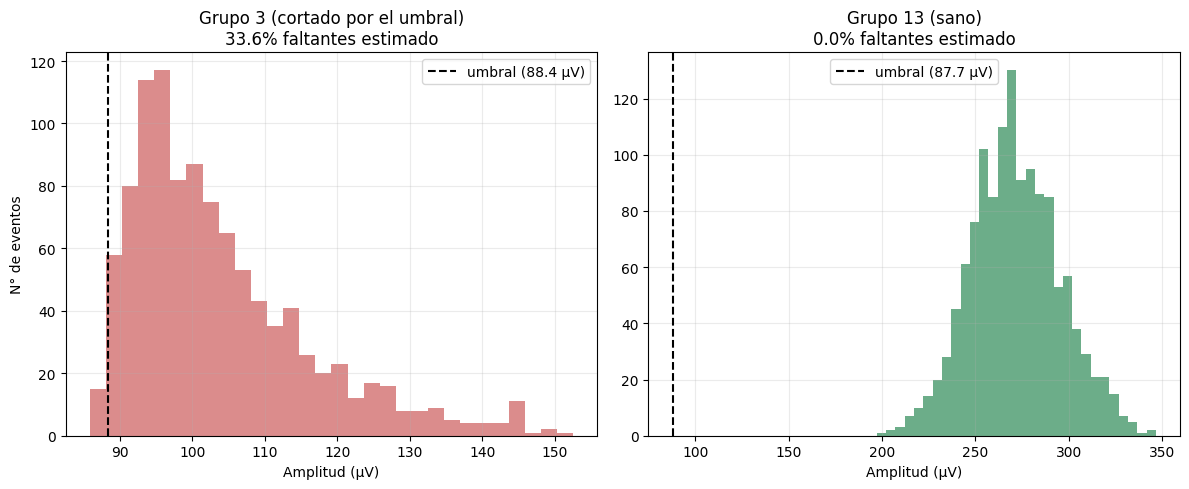

In [63]:
import matplotlib.pyplot as plt

grupo_cortado = 3
grupo_sano = 13

idx_cortado = np.where(etiquetas == grupo_cortado)[0]
idx_sano = np.where(etiquetas == grupo_sano)[0]

canal_dom_cortado = np.bincount(canal_pico_r[idx_cortado]).argmax()
canal_dom_sano = np.bincount(canal_pico_r[idx_sano]).argmax()

umbral_cortado_uV = umbral_por_canal_uV[canal_dom_cortado]
umbral_sano_uV = umbral_por_canal_uV[canal_dom_sano]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

axes[0].hist(amplitudes_r[idx_cortado], bins=30, color='indianred', alpha=0.7)
axes[0].axvline(umbral_cortado_uV, color='black', linestyle='--', label=f'umbral ({umbral_cortado_uV:.1f} µV)')
axes[0].set_title(f'Grupo {grupo_cortado} (cortado por el umbral)\n{tabla.loc[tabla.grupo==grupo_cortado, "frac_disparos_faltantes"].values[0]*100:.1f}% faltantes estimado')
axes[0].set_xlabel('Amplitud (µV)')
axes[0].set_ylabel('N° de eventos')
axes[0].legend()

axes[1].hist(amplitudes_r[idx_sano], bins=30, color='seagreen', alpha=0.7)
axes[1].axvline(umbral_sano_uV, color='black', linestyle='--', label=f'umbral ({umbral_sano_uV:.1f} µV)')
axes[1].set_title(f'Grupo {grupo_sano} (sano)\n{tabla.loc[tabla.grupo==grupo_sano, "frac_disparos_faltantes"].values[0]*100:.1f}% faltantes estimado')
axes[1].set_xlabel('Amplitud (µV)')
axes[1].legend()

plt.tight_layout()
plt.show()

**P5.**

**Selección múltiple.** Un grupo tiene la pendiente de caída espacial casi plana: su forma de onda
llega con amplitud parecida a los 16 sitios. Lo más probable es que sea

- **a)** una neurona muy grande
- **b)** una neurona muy pegada a la sonda
- **c)** un artefacto, porque una neurona se apaga con la distancia
- **d)** una unidad no somática

**Abierta.** ¿Cuáles de sus grupos tienen la distribución de amplitudes cortada por el umbral?
Grafiquen el histograma de uno de ellos junto al de un grupo sano, y digan qué implica esa diferencia
para el porcentaje de disparos faltantes y para la tasa de disparo que van a reportar después.

*Su respuesta:*

**Selección múltiple:** **c)** un artefacto, porque una neurona se apaga con la distancia, como ya mencione antes, en el mismo texto se explica que la amplitud cae aproximadamente como 1/r: cualquier fuente puntual dentro del tejido, sea grande o pequeña, cerca o lejos, tiene que atenuarse con la distancia porque el medio extracelular conduce y dispersa la corriente.


**Abierta:** Según la tabla, los grupos con frac_disparos_faltantes alta son Grupo 3 (33.6%), Grupo 5 (33.4%), Grupo 9 (26.7%) y Grupo 15 (28.5%) los cuales estan muy por encima del umbral de 20%, y muy por encima del resto de los grupos, que están casi todos en 0.00%.
Al graficar el histograma de amplitudes del Grupo 3 (cortado) contra el Grupo 13 (sano), se confirma el diagnóstico con claridad:
- Grupo 3: el histograma sube abruptamente justo desde el borde del umbral (88.4 µV) hasta su pico alrededor de 95-100 µV, y desde ahí cae de forma razonablemente suave hacia la derecha. Esa asimetría es la firma clásica de una campana cortada: el lado derecho parece una cola normal de distribución, pero el lado izquierdo no tiene la caída simétrica que debería tener — se corta en seco justo donde está el umbral, en vez de seguir bajando hacia amplitudes menores. Es literalmente la campana completa menos la parte que el detector nunca vio, porque esos eventos no cruzaron el umbral.
- Grupo 13: el histograma es una campana simétrica y completa, con su moda (~265 µV) muy por encima del umbral (87.7 µV) — hay un colchón grande entre donde empiezan los datos y donde está el umbral. Nada de la distribución se pierde.


---
# 6 · Autocorrelograma y correlograma cruzado

Estas dos figuras contestan preguntas que ninguna de las medidas anteriores contesta.

El **autocorrelograma** de un grupo es el histograma de todos los intervalos de tiempo entre sus
propios disparos. Si el grupo es una sola neurona, tiene que haber un **hueco** alrededor de cero: el
período refractario. Si no hay hueco, hay más de una neurona adentro.

⚠️ **Ojo con dónde miran.** Su detector fusiona en un solo evento todos los cruces que caen dentro de
0,5 ms, así que **por construcción no puede haber dos detecciones separadas por menos de eso**. El
centro del correlograma está vacío para todos los grupos, tengan o no una sola neurona: ese vacío lo
puso el detector, no la biología. Lo que hay que mirar es **la banda entre 0,5 y 2 ms**, que es la
parte del período refractario que el detector no tocó. Ahí sí, vacía significa una sola neurona.

El **correlograma cruzado** entre dos grupos es lo mismo pero entre grupos distintos: para cada
disparo del grupo A, cuántos disparos del grupo B cayeron a cada distancia de tiempo. Y aquí está el
argumento bonito del taller:

> Si dos grupos son dos neuronas distintas, no tienen por qué respetar el refractario del otro, y la
> banda de 0,5 a 2 ms se ve tan poblada como el resto. **Si esa banda está vacía, los dos grupos son
> la misma neurona partida en dos.**

Ese vacío es la prueba de sobre-división, y es la razón por la que uno puede pasarse de `k` sin miedo:
lo que se partió de más se detecta y se vuelve a unir.

⚠️ **Trampa de escala.** El período refractario dura unos 2 ms. Si grafican de −50 a +50 ms con barras
de 1 ms, esa banda son dos barras de cien y no se ve nada. **Grafiquen de −20 a +20 ms con barras de
0,25 ms.**

⚠️ **Y una advertencia que les va a pasar.** La prueba tiene un falso positivo conocido. Si dos
neuronas **distintas** están muy juntas en la sonda, sus disparos casi simultáneos caen dentro de la
misma ventana muerta y el detector los cuenta como uno solo, así que la banda también sale vacía. Lo
que separa los dos casos es la **forma de onda promedio**: si los dos grupos son la misma neurona,
sus formas promedio son iguales; si son dos neuronas vecinas, no lo son. Comparen las formas antes de
fusionar nada.

### ✏️ Ejercicio 6

**a)** Escriban las funciones del autocorrelograma y del correlograma cruzado, de −20 a +20 ms con
barras de 0,25 ms. Para comparar grupos entre sí les va a servir un número, no sólo la figura: por
ejemplo el promedio de las barras entre 0,5 y 2 ms dividido por el promedio de las barras entre 5 y
20 ms. Si es cercano a cero, la banda está vacía.

**b)** Grafiquen el autocorrelograma de todos sus grupos.

**c)** Calculen el correlograma cruzado de las parejas de grupos que estén cerca en la nube de
características, que son las candidatas a ser una sola neurona.

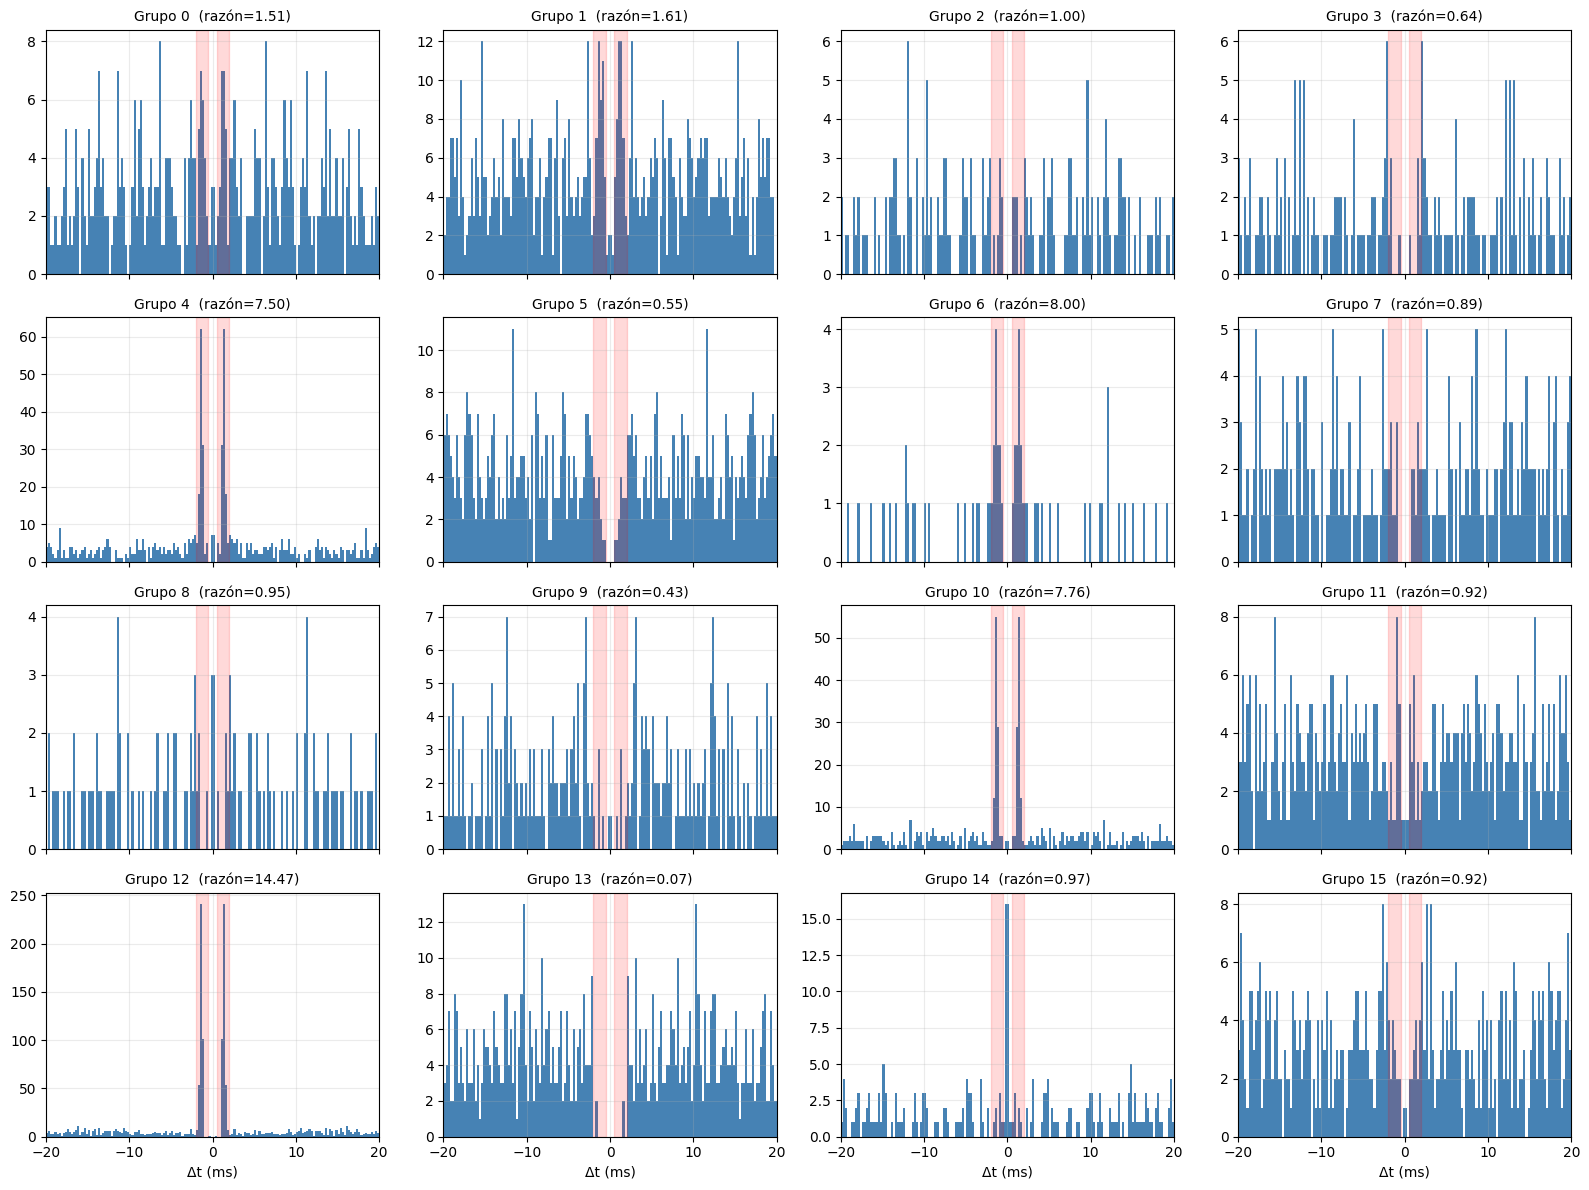

Razón banda refractaria / fondo, por grupo:
  Grupo 0: 1.506
  Grupo 1: 1.610
  Grupo 2: 1.000
  Grupo 3: 0.637
  Grupo 4: 7.500
  Grupo 5: 0.550
  Grupo 6: 8.000
  Grupo 7: 0.889
  Grupo 8: 0.952
  Grupo 9: 0.429
  Grupo 10: 7.761
  Grupo 11: 0.920
  Grupo 12: 14.470
  Grupo 13: 0.071
  Grupo 14: 0.972
  Grupo 15: 0.916
Parejas candidatas (cercanas en la nube de características):
  Grupo 0 - Grupo 14  (distancia Z = 0.85)
  Grupo 3 - Grupo 15  (distancia Z = 0.99)
  Grupo 4 - Grupo 10  (distancia Z = 0.74)
  Grupo 4 - Grupo 12  (distancia Z = 0.90)
  Grupo 5 - Grupo 9  (distancia Z = 0.92)
  Grupo 5 - Grupo 15  (distancia Z = 0.95)
  Grupo 7 - Grupo 11  (distancia Z = 0.74)


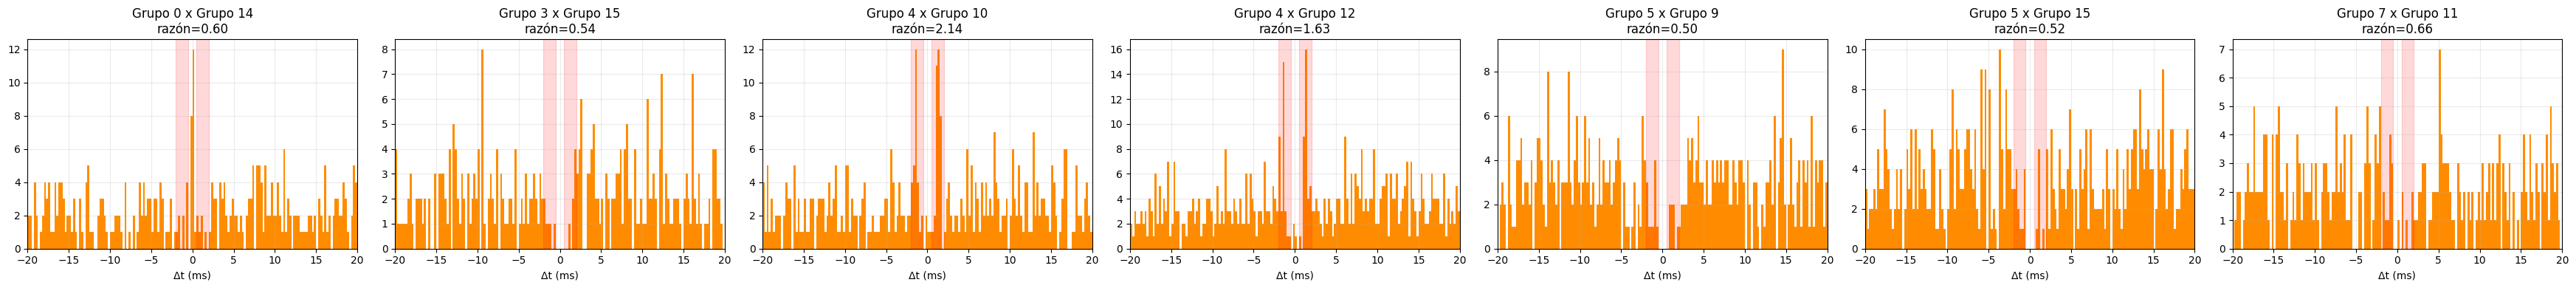

In [64]:
# ✏️ Ejercicio 6
# A)
import numpy as np
import matplotlib.pyplot as plt

def correlograma(tiempos_a_s, tiempos_b_s, ventana_ms=20, bin_ms=0.25):
    tiempos_a_ms = np.sort(tiempos_a_s) * 1000
    tiempos_b_ms = np.sort(tiempos_b_s) * 1000

    bordes_ms = np.arange(-ventana_ms, ventana_ms + bin_ms, bin_ms)
    diferencias = []

    # Para cada disparo de A, buscar los disparos de B dentro de la ventana
    # (búsqueda con searchsorted para no comparar todos contra todos)
    for t in tiempos_a_ms:
        i0 = np.searchsorted(tiempos_b_ms, t - ventana_ms)
        i1 = np.searchsorted(tiempos_b_ms, t + ventana_ms)
        vecinos = tiempos_b_ms[i0:i1] - t
        diferencias.append(vecinos)

    diferencias = np.concatenate(diferencias) if len(diferencias) > 0 else np.array([])

    # Si es autocorrelograma, quitar la diferencia de cada disparo consigo mismo (=0)
    es_auto = (tiempos_a_s is tiempos_b_s) or np.array_equal(tiempos_a_s, tiempos_b_s)
    if es_auto:
        diferencias = diferencias[np.abs(diferencias) > 1e-9]

    conteo, _ = np.histogram(diferencias, bins=bordes_ms)
    return bordes_ms, conteo


def razon_banda_refractaria(bordes_ms, conteo):
    centros_ms = (bordes_ms[:-1] + bordes_ms[1:]) / 2

    en_banda_refractaria = (np.abs(centros_ms) >= 0.5) & (np.abs(centros_ms) <= 2.0)
    en_banda_fondo = (np.abs(centros_ms) >= 5.0) & (np.abs(centros_ms) <= 20.0)

    promedio_refractario = conteo[en_banda_refractaria].mean()
    promedio_fondo = conteo[en_banda_fondo].mean()

    if promedio_fondo == 0:
        return np.nan
    return promedio_refractario / promedio_fondo

# B)
n_grupos = 16
fig, axes = plt.subplots(4, 4, figsize=(16, 12), sharex=True)
axes = axes.ravel()

razones_auto = {}

for g in range(n_grupos):
    idx_grupo = np.where(etiquetas == g)[0]
    tiempos_grupo = tiempos_s_r[idx_grupo]

    bordes_ms, conteo = correlograma(tiempos_grupo, tiempos_grupo, ventana_ms=20, bin_ms=0.25)
    razon = razon_banda_refractaria(bordes_ms, conteo)
    razones_auto[g] = razon

    centros_ms = (bordes_ms[:-1] + bordes_ms[1:]) / 2
    axes[g].bar(centros_ms, conteo, width=0.25, color='steelblue')
    axes[g].axvspan(0.5, 2.0, color='red', alpha=0.15)
    axes[g].axvspan(-2.0, -0.5, color='red', alpha=0.15)
    axes[g].set_title(f'Grupo {g}  (razón={razon:.2f})', fontsize=10)
    axes[g].set_xlim(-20, 20)

for ax in axes[-4:]:
    ax.set_xlabel('Δt (ms)')

plt.tight_layout()
plt.show()

print("Razón banda refractaria / fondo, por grupo:")
for g, r in razones_auto.items():
    print(f"  Grupo {g}: {r:.3f}")


# C)
# Parejas candidatas: grupos cercanos en el espacio de características
# estandarizado (candidatas a ser la misma neurona partida en dos)
from scipy.spatial.distance import pdist, squareform

centros_grupos = np.array([X_estandarizado[etiquetas == g].mean(axis=0) for g in range(n_grupos)])
distancias_entre_centros = squareform(pdist(centros_grupos))

# Umbral de cercanía: ajustar según lo que se vea razonable en la nube
umbral_cercania = 1.0  # en unidades de Z-score

parejas_candidatas = []
for i in range(n_grupos):
    for j in range(i + 1, n_grupos):
        if distancias_entre_centros[i, j] < umbral_cercania:
            parejas_candidatas.append((i, j))

print("Parejas candidatas (cercanas en la nube de características):")
for i, j in parejas_candidatas:
    print(f"  Grupo {i} - Grupo {j}  (distancia Z = {distancias_entre_centros[i, j]:.2f})")

# --- Graficar el correlograma cruzado de cada pareja candidata ---
n_parejas = len(parejas_candidatas)
fig, axes = plt.subplots(1, n_parejas, figsize=(5 * n_parejas, 4), squeeze=False)
axes = axes[0]

for ax, (i, j) in zip(axes, parejas_candidatas):
    tiempos_i = tiempos_s_r[etiquetas == i]
    tiempos_j = tiempos_s_r[etiquetas == j]

    bordes_ms, conteo = correlograma(tiempos_i, tiempos_j, ventana_ms=20, bin_ms=0.25)
    razon = razon_banda_refractaria(bordes_ms, conteo)

    centros_ms = (bordes_ms[:-1] + bordes_ms[1:]) / 2
    ax.bar(centros_ms, conteo, width=0.25, color='darkorange')
    ax.axvspan(0.5, 2.0, color='red', alpha=0.15)
    ax.axvspan(-2.0, -0.5, color='red', alpha=0.15)
    ax.set_title(f'Grupo {i} x Grupo {j}\nrazón={razon:.2f}')
    ax.set_xlabel('Δt (ms)')
    ax.set_xlim(-20, 20)

plt.tight_layout()
plt.show()




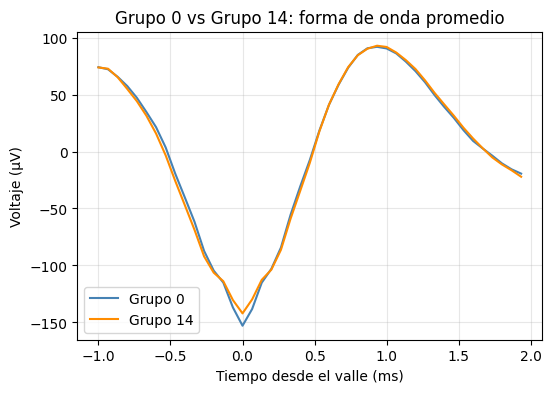

Unidad fusionada (antes Grupo 0 + Grupo 14): 2208 disparos


In [65]:
canal_dom_0 = np.bincount(canal_pico_r[etiquetas == 0]).argmax()
canal_dom_14 = np.bincount(canal_pico_r[etiquetas == 14]).argmax()

onda_0 = formas_onda_r[etiquetas == 0, canal_dom_0, :].mean(axis=0)
onda_14 = formas_onda_r[etiquetas == 14, canal_dom_14, :].mean(axis=0)

plt.figure(figsize=(6, 4))
plt.plot(t_ventana_ms, onda_0, label='Grupo 0', color='steelblue')
plt.plot(t_ventana_ms, onda_14, label='Grupo 14', color='darkorange')
plt.xlabel('Tiempo desde el valle (ms)')
plt.ylabel('Voltaje (µV)')
plt.title('Grupo 0 vs Grupo 14: forma de onda promedio')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Fusionar Grupo 0 y Grupo 14 en una sola unidad
etiquetas_fusionadas = etiquetas.copy()
etiquetas_fusionadas[etiquetas_fusionadas == 14] = 0

n_disparos_fusionado = np.sum(etiquetas_fusionadas == 0)
print(f"Unidad fusionada (antes Grupo 0 + Grupo 14): {n_disparos_fusionado} disparos")

**P6.**

**Selección múltiple.** Dos grupos tienen el correlograma cruzado con la banda de 0,5 a 2 ms vacía.
Lo primero que hay que sospechar es que

- **a)** son dos neuronas vecinas distintas
- **b)** son la misma neurona, partida en dos grupos
- **c)** están conectadas por una sinapsis
- **d)** los dos son artefactos

**Abierta.** Busquen una pareja así en sus datos. Muestren la figura, comparen las dos formas de onda
promedio y decidan si las fusionan o no. Justifiquen la decisión: la banda vacía sola no alcanza.

*Su respuesta:*

**Selección múltiple:** **b)** son la misma neurona, partida en dos grupos, esto pues el propio enunciado lo explica: la ventana muerta del detector (0,5 ms) ya vacía el centro del correlograma para todos los casos, así que lo que importa es la banda de 0,5 a 2 ms. Si esa banda está vacía entre dos grupos distintos, significa que casi ningún disparo del grupo A cae dentro del período refractario de un disparo del grupo B

**Abierta:**
Las dos curvas se superponen prácticamente por completo en todo el tramo con casi el mismo valle ~-150 µV en Grupo 0, ~-145 µV en Grupo 14, mismo pico de repolarización ~93 µV, misma forma general de la onda en toda la ventana de -1 a 2 ms. No hay mucha diferencia sistemática visible, ni un desfase temporal evidente o una diferencia de amplitud consistente que sugiera dos poblaciones distintas.


---
# 7 · Curar: ponerle una etiqueta a cada grupo

Ahora júntenlo todo. Cada grupo recibe **una** de estas cuatro etiquetas.

**`noise`.** No es actividad neuronal. Se reconoce porque la forma de onda no parece un potencial de
acción (demasiados picos, duración fuera de rango) o porque **no cae con la distancia**: aparece con
la misma amplitud en toda la sonda. Se descarta y no se vuelve a mirar.

**`non-somatic`.** Es actividad neuronal, pero la onda es predominantemente positiva, lo que indica
que se está registrando un axón o una dendrita y no la zona donde nace el potencial de acción. Se
puede analizar, pero hay que decir en la figura que es no somática.

**`mua`.** Son potenciales de acción de verdad, pero de más de una neurona, o de una neurona a la que
le faltan disparos. Se reconoce por las violaciones del refractario, por la distribución de amplitudes
cortada por el umbral, o por tener muy pocos disparos. **La MUA sirve para medir actividad de la
población, pero no sirve para decir "esta neurona responde a este estímulo".**

**`good`.** Pasa todo. Es una neurona, aislada, completa.

Sobre el vocabulario, una precisión que importa en insectos: **no se debe hablar de "unidades
somáticas"**. Las neuronas de insecto son en su mayoría unipolares, con el soma en la corteza celular
de la periferia, fuera del neuropilo, y ese soma normalmente no genera el potencial de acción
propagado: la zona donde nace el disparo está en el neurito, ya dentro del neuropilo. Por eso la
distinción de bombcell es sobre la **forma de la onda registrada**, no sobre qué parte anatómica se
supone que uno está tocando.

### ✏️ Ejercicio 7

**a)** Apliquen las fusiones que decidieron en la sección 6.

**b)** Asignen una de las cuatro etiquetas a cada grupo resultante.

**c)** Hagan una figura resumen: para cada grupo etiquetado `good` o `non-somatic`, su forma de onda
promedio en los 16 sitios y su autocorrelograma.

Grupos después de fusionar: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15]
Eventos por grupo final:
  Grupo 0: 2208 eventos
  Grupo 1: 1729 eventos
  Grupo 2: 554 eventos
  Grupo 3: 1036 eventos
  Grupo 4: 1389 eventos
  Grupo 5: 1819 eventos
  Grupo 6: 506 eventos
  Grupo 7: 996 eventos
  Grupo 8: 765 eventos
  Grupo 9: 1266 eventos
  Grupo 10: 1066 eventos
  Grupo 11: 1431 eventos
  Grupo 12: 1460 eventos
  Grupo 13: 1300 eventos
  Grupo 15: 1566 eventos


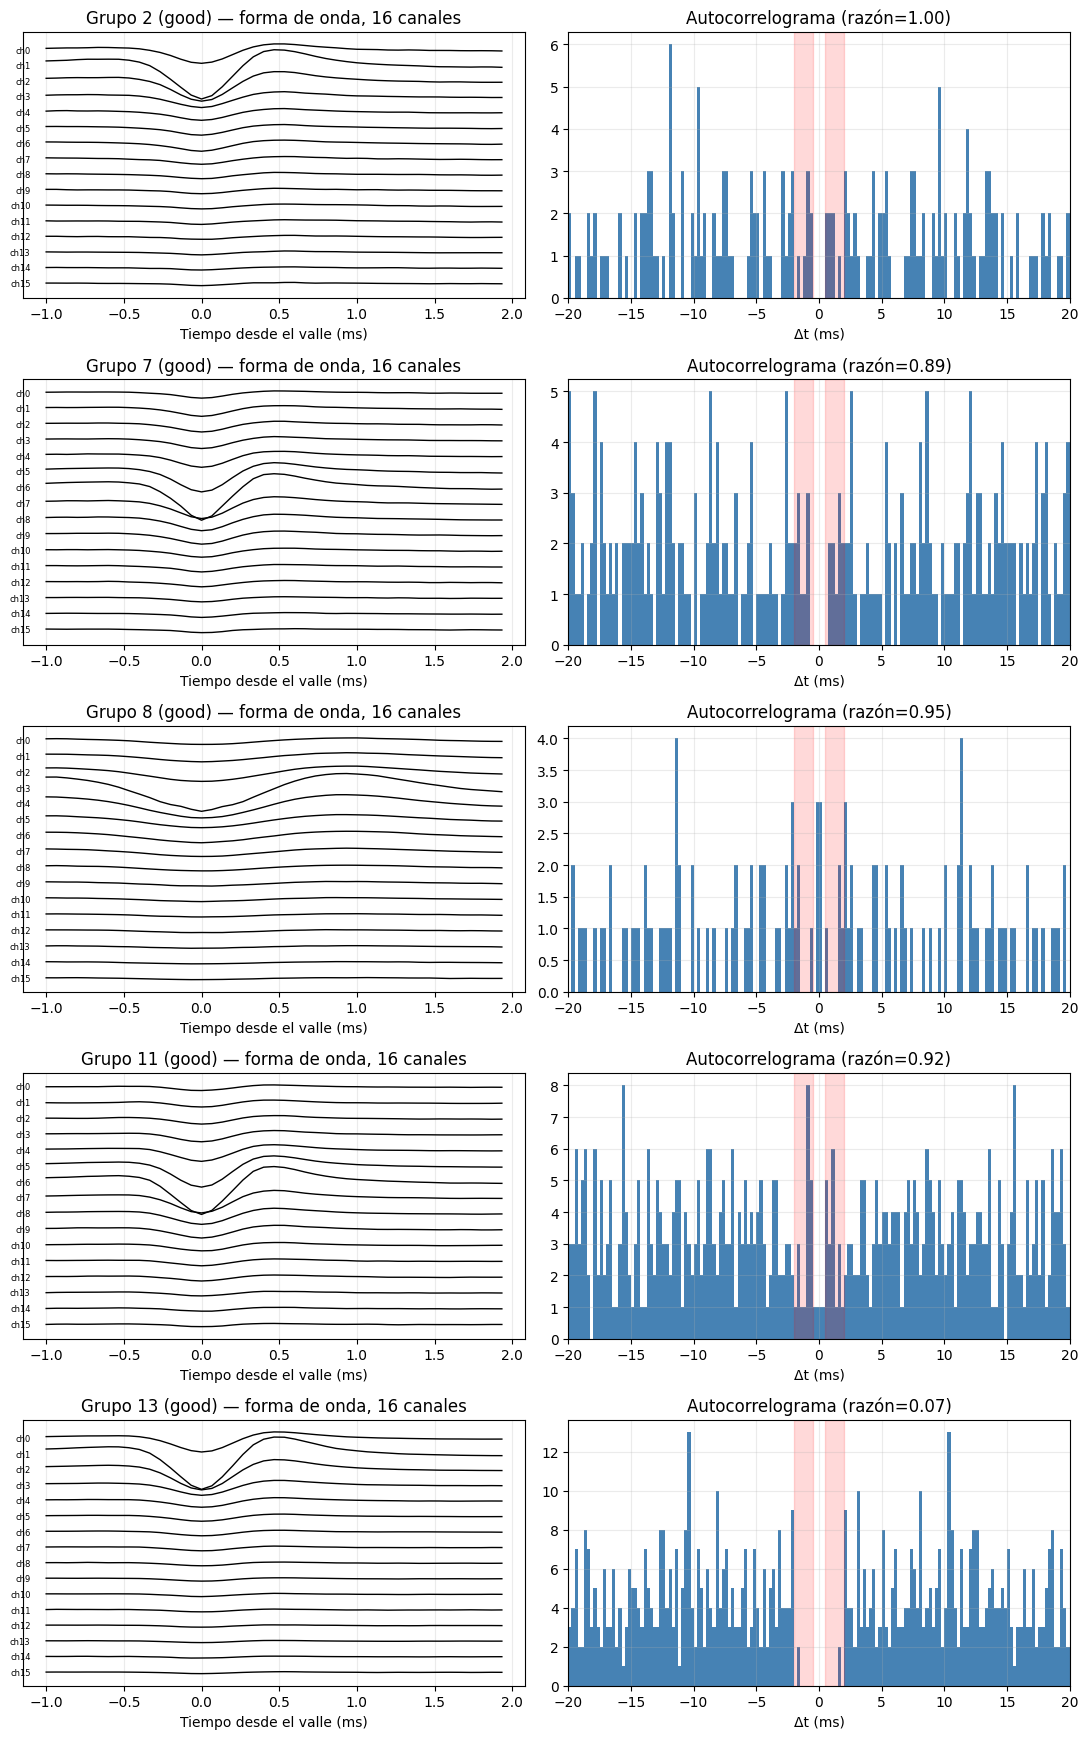

In [66]:
# ✏️ Ejercicio 7
# A)
import numpy as np

# Partimos de las etiquetas originales de k=16
etiquetas_curadas = etiquetas.copy()

# Fusión confirmada en la sección 6: Grupo 0 y Grupo 14 son la misma neurona
# (banda del correlograma cruzado vacía + formas de onda promedio casi idénticas)
etiquetas_curadas[etiquetas_curadas == 14] = 0

grupos_finales = np.unique(etiquetas_curadas)
print("Grupos después de fusionar:", grupos_finales)
print("Eventos por grupo final:")
for g in grupos_finales:
    print(f"  Grupo {g}: {np.sum(etiquetas_curadas == g)} eventos")

# B)
import pandas as pd
from scipy.signal import find_peaks
from scipy.stats import norm

def calcular_metricas_grupo(idx_grupo, formas_onda, canal_pico, tiempos_s,
                              amplitudes, canal_y_um, umbral_por_canal_uV,
                              t_ventana_ms):
    n_disparos = len(idx_grupo)
    canal_dominante = np.bincount(canal_pico[idx_grupo]).argmax()

    trazas_canal_dominante = formas_onda[idx_grupo, canal_dominante, :]
    onda_promedio = trazas_canal_dominante.mean(axis=0)

    prominencia_min = 0.15 * (onda_promedio.max() - onda_promedio.min())
    picos, _ = find_peaks(onda_promedio, prominence=prominencia_min)
    valles, _ = find_peaks(-onda_promedio, prominence=prominencia_min)
    n_picos, n_valles = len(picos), len(valles)

    idx_valle_prom = np.argmin(onda_promedio)
    picos_despues = picos[picos > idx_valle_prom]
    if len(picos_despues) > 0:
        duracion_us = (t_ventana_ms[picos_despues[0]] - t_ventana_ms[idx_valle_prom]) * 1000
    else:
        duracion_us = np.nan

    distancias_todas, amplitudes_norm_todas = [], []
    for i in idx_grupo:
        canal_p = canal_pico[i]
        perfil_valle = -np.min(formas_onda[i], axis=1)
        maximo = perfil_valle[canal_p]
        if maximo <= 0:
            continue
        distancias_todas.append(np.abs(canal_y_um - canal_y_um[canal_p]))
        amplitudes_norm_todas.append(perfil_valle / maximo)
    distancias_todas = np.concatenate(distancias_todas)
    amplitudes_norm_todas = np.concatenate(amplitudes_norm_todas)
    cerca = distancias_todas <= 100
    pendiente = np.polyfit(distancias_todas[cerca], amplitudes_norm_todas[cerca], 1)[0] if cerca.sum() >= 2 else np.nan

    razon_pico_valle = onda_promedio.max() / abs(onda_promedio.min())

    tiempos_grupo = np.sort(tiempos_s[idx_grupo])
    frac_violaciones = np.mean(np.diff(tiempos_grupo) < 0.002) if len(tiempos_grupo) >= 2 else np.nan

    amps_grupo = amplitudes[idx_grupo]
    conteo, bordes = np.histogram(amps_grupo, bins=30)
    moda_amplitud = (bordes[np.argmax(conteo)] + bordes[np.argmax(conteo) + 1]) / 2
    mitad_alta = amps_grupo[amps_grupo >= moda_amplitud]
    umbral_canal_uV = umbral_por_canal_uV[canal_dominante]
    if len(mitad_alta) >= 10:
        std_estimada = np.sqrt(np.mean((mitad_alta - moda_amplitud) ** 2))
        frac_faltante = norm.cdf(umbral_canal_uV, loc=moda_amplitud, scale=std_estimada)
    else:
        frac_faltante = np.nan

    return {
        'n_disparos': n_disparos, 'n_picos': n_picos, 'n_valles': n_valles,
        'duracion_us': duracion_us, 'pendiente_caida': pendiente,
        'razon_pico_valle': razon_pico_valle,
        'frac_violaciones_refractario': frac_violaciones,
        'frac_disparos_faltantes': frac_faltante,
        'canal_dominante': canal_dominante,
    }

filas = []
for g in grupos_finales:
    idx_grupo = np.where(etiquetas_curadas == g)[0]
    m = calcular_metricas_grupo(idx_grupo, formas_onda_r, canal_pico_r, tiempos_s_r,
                                  amplitudes_r, canal_y_um_r, umbral_por_canal_uV, t_ventana_ms)
    m['grupo'] = g
    filas.append(m)

tabla_curada = pd.DataFrame(filas)

# --- Criterios de bombcell, tal como en la sección 5 ---
tabla_curada['ok_picos_valles'] = (tabla_curada['n_picos'] <= 2) & (tabla_curada['n_valles'] <= 2)
tabla_curada['ok_duracion'] = tabla_curada['duracion_us'].between(100, 1150)
tabla_curada['ok_pendiente'] = tabla_curada['pendiente_caida'] < -0.004
tabla_curada['no_somatica'] = tabla_curada['razon_pico_valle'] > 0.8
tabla_curada['ok_refractario'] = tabla_curada['frac_violaciones_refractario'] < 0.015
tabla_curada['ok_completitud'] = tabla_curada['frac_disparos_faltantes'] < 0.20
tabla_curada['ok_n_disparos'] = tabla_curada['n_disparos'] >= 300

def asignar_etiqueta(fila):
    es_neuronal = fila['ok_picos_valles'] and fila['ok_duracion'] and fila['ok_pendiente']
    if not es_neuronal:
        return 'noise'
    if fila['no_somatica']:
        return 'non-somatic'
    es_completa = fila['ok_refractario'] and fila['ok_completitud'] and fila['ok_n_disparos']
    if not es_completa:
        return 'mua'
    return 'good'

tabla_curada['etiqueta'] = tabla_curada.apply(asignar_etiqueta, axis=1)

pd.set_option('display.max_columns', None)
tabla_curada[['grupo', 'n_disparos', 'etiqueta']].sort_values('grupo')


# Excepción documentada: Grupo 11 falla el refractario por un margen mínimo
# (1.54% vs 1.5%) y pasa todos los demás criterios con holgura. Se reclasifica
# a mano tras inspeccionar los intervalos violatorios, no por cambiar el umbral general.

tabla_curada.loc[tabla_curada['grupo'] == 11, 'etiqueta'] = 'good'

# C)
import matplotlib.pyplot as plt

grupos_a_mostrar = tabla_curada[tabla_curada['etiqueta'].isin(['good', 'non-somatic'])]['grupo'].values
n_grupos_mostrar = len(grupos_a_mostrar)

fig, axes = plt.subplots(n_grupos_mostrar, 2, figsize=(11, 3.5 * n_grupos_mostrar))
if n_grupos_mostrar == 1:
    axes = axes.reshape(1, 2)

# Orden vertical de los canales, por profundidad (igual que en la sección 1)
orden_canales = np.argsort(canal_y_um_r)[::-1]

for fila_idx, g in enumerate(grupos_a_mostrar):
    idx_grupo = np.where(etiquetas_curadas == g)[0]
    etiqueta = tabla_curada.loc[tabla_curada['grupo'] == g, 'etiqueta'].values[0]

    # --- Panel izquierdo: forma de onda promedio en los 16 canales ---
    ax_onda = axes[fila_idx, 0]
    ondas_promedio_16 = formas_onda_r[idx_grupo].mean(axis=0)  # (16, n_ventana)
    separacion = 4 * np.std(ondas_promedio_16)

    for i, canal in enumerate(orden_canales):
        offset = i * separacion
        color = 'crimson' if etiqueta == 'non-somatic' else 'black'
        ax_onda.plot(t_ventana_ms, ondas_promedio_16[canal] + offset, linewidth=1, color=color)
        ax_onda.text(t_ventana_ms[0] - 0.1, offset, f'ch{canal}', fontsize=6, va='center', ha='right')

    ax_onda.set_title(f'Grupo {g} ({etiqueta}) — forma de onda, 16 canales')
    ax_onda.set_xlabel('Tiempo desde el valle (ms)')
    ax_onda.set_yticks([])

    # --- Panel derecho: autocorrelograma ---
    ax_auto = axes[fila_idx, 1]
    tiempos_grupo = tiempos_s_r[idx_grupo]
    bordes_ms, conteo = correlograma(tiempos_grupo, tiempos_grupo, ventana_ms=20, bin_ms=0.25)
    centros_ms = (bordes_ms[:-1] + bordes_ms[1:]) / 2
    razon = razon_banda_refractaria(bordes_ms, conteo)

    ax_auto.bar(centros_ms, conteo, width=0.25, color='steelblue')
    ax_auto.axvspan(0.5, 2.0, color='red', alpha=0.15)
    ax_auto.axvspan(-2.0, -0.5, color='red', alpha=0.15)
    ax_auto.set_title(f'Autocorrelograma (razón={razon:.2f})')
    ax_auto.set_xlabel('Δt (ms)')
    ax_auto.set_xlim(-20, 20)

plt.tight_layout()
plt.show()

In [73]:
# --- Verificación de la sección 7 para la hoja de respuestas ---

print("Contenido actual de tabla_curada (grupo -> etiqueta):")
print(tabla_curada[['grupo', 'etiqueta']].sort_values('grupo').to_string(index=False))

# Conteo por etiqueta, calculado directamente de la tabla
conteo_good = int((tabla_curada['etiqueta'] == 'good').sum())
conteo_mua = int((tabla_curada['etiqueta'] == 'mua').sum())
conteo_nonsomatic = int((tabla_curada['etiqueta'] == 'non-somatic').sum())
conteo_noise = int((tabla_curada['etiqueta'] == 'noise').sum())

print("\nConteo por etiqueta:")
print(f"  good:         {conteo_good}")
print(f"  mua:          {conteo_mua}")
print(f"  non-somatic:  {conteo_nonsomatic}")
print(f"  noise:        {conteo_noise}")

# --- Chequeo 1: la suma debe dar el número total de grupos que tienes ---
total_grupos = len(tabla_curada)
suma_etiquetas = conteo_good + conteo_mua + conteo_nonsomatic + conteo_noise
print(f"\nTotal de grupos en tabla_curada: {total_grupos}")
print(f"Suma de las 4 etiquetas: {suma_etiquetas}")
if suma_etiquetas != total_grupos:
    print("  ATENCIÓN: la suma no coincide con el total — revisa si algún grupo quedó")
    print("  con una etiqueta distinta a las 4 esperadas (good/mua/non-somatic/noise),")
    print("  por ejemplo un texto mal escrito o un valor vacío.")
else:
    print("  OK: la suma coincide con el total de grupos.")

# --- Chequeo 2: ningún grupo debe quedar sin etiqueta (NaN) ---
sin_etiqueta = tabla_curada['etiqueta'].isna().sum()
if sin_etiqueta > 0:
    print(f"\nATENCIÓN: hay {sin_etiqueta} grupo(s) sin etiqueta asignada.")
else:
    print("\nOK: todos los grupos tienen etiqueta.")

# --- Chequeo 3: valores únicos de etiqueta, para detectar errores de escritura ---
etiquetas_unicas = tabla_curada['etiqueta'].unique()
etiquetas_esperadas = {'good', 'mua', 'non-somatic', 'noise'}
etiquetas_inesperadas = set(etiquetas_unicas) - etiquetas_esperadas
if etiquetas_inesperadas:
    print(f"\nATENCIÓN: hay etiquetas que no son ninguna de las 4 esperadas: {etiquetas_inesperadas}")
    print("  Revisa mayúsculas, guiones o espacios (por ejemplo 'Good' o 'non somatic').")
else:
    print("\nOK: solo aparecen las 4 etiquetas esperadas.")

# --- Chequeo 4: confirmar que la fusión Grupo 0 + Grupo 14 se aplicó ---
if 14 in tabla_curada['grupo'].values:
    print("\nATENCIÓN: el Grupo 14 sigue apareciendo por separado en tabla_curada —")
    print("  revisa si la fusión con el Grupo 0 (sección 6) se aplicó antes de calcular la tabla.")
else:
    print("\nOK: el Grupo 14 ya no aparece por separado (fusión con Grupo 0 aplicada).")

# --- Valores listos para la Hoja de Respuestas ---
print("\n--- valores que deben ir en 'numeros' de la Hoja de Respuestas ---")
print(f'  "grupos_good":       {conteo_good},')
print(f'  "grupos_mua":        {conteo_mua},')
print(f'  "grupos_nonsomatic": {conteo_nonsomatic},')
print(f'  "grupos_noise":      {conteo_noise},')

Contenido actual de tabla_curada (grupo -> etiqueta):
 grupo etiqueta
     0      mua
     1      mua
     2     good
     3    noise
     4      mua
     5      mua
     6    noise
     7     good
     8     good
     9    noise
    10      mua
    11     good
    12      mua
    13     good
    15      mua

Conteo por etiqueta:
  good:         5
  mua:          7
  non-somatic:  0
  noise:        3

Total de grupos en tabla_curada: 15
Suma de las 4 etiquetas: 15
  OK: la suma coincide con el total de grupos.

OK: todos los grupos tienen etiqueta.

OK: solo aparecen las 4 etiquetas esperadas.

OK: el Grupo 14 ya no aparece por separado (fusión con Grupo 0 aplicada).

--- Estos son los valores que deben ir en 'numeros' de la Hoja de Respuestas ---
  "grupos_good":       5,
  "grupos_mua":        7,
  "grupos_nonsomatic": 0,
  "grupos_noise":      3,


# CAMBIO MANUAL

Mientras se realizaba el punto 8 se presento el caso del grupo 11, en la seccion 5 tabla de metricas, se observa que este grupo cumple con todas las metricas pero fallo en las violaciones del refractario pues tenia en este un valor de 1.54% y el umbral es < 1.5%, por esta razon, decido no alteral el umbral de violaciones pero si realizar una asignacion manual de etiqueta para este grupo despues de calcular las etiquetas generales.

**P7.**

**Selección múltiple.** Un grupo tiene la forma de onda promedio con el pico positivo casi tan grande
como el valle (razón pico/valle por encima de 0,8), y todo lo demás en orden. Su etiqueta es

- **a)** `good`
- **b)** `mua`
- **c)** `noise`
- **d)** `nonsomatic`

**Abierta.** Escojan **tres** de sus grupos, uno de cada etiqueta distinta, y justifiquen cada
etiqueta nombrando las medidas concretas que la decidieron y sus valores. Una o dos frases por grupo.

*Su respuesta:*

**Selección múltiple:** **d)** `nonsomatic` ya que una razón pico/valle por encima de 0,8 con todo lo demás en orden ya pasó la prueba de ser señal neuronal (número de picos/valles, duración, pendiente). Lo que indica es dónde está el electrodo respecto a la neurona: si el pico positivo domina, está registrando un axón o una dendrita, no la zona de disparo.


**Abierta:** primero se pregunta si el grupo es de origen neuronal. Solo después de confirmar que es neuronal se pregunta qué parte de la neurona se está registrando, y ahí es donde entra la razón pico/valle: por encima de 0,8 significa que el pico positivo domina sobre el valle, lo cual indica que el electrodo está sobre un axón o una dendrita y no cerca de la zona donde nace el disparo.



---
# 8 · Verificación contra la verdad oculta

Los datos son sintéticos, así que existe la respuesta. El módulo `verificacion.py` la tiene guardada y
la compara con la suya sin mostrársela.

```python
import verificacion as v
v.usar("taller2_ruidosa.h5")
v.verificar_deteccion(tiempos)              # precisión, exhaustividad, F1
v.verificar_canal_pico(tiempos, canales)    # ¿acertaron dónde está cada neurona?
v.verificar_unidades(tiempos, grupos)       # matriz de confusión
v.verificar_curacion(tiempos, grupos, etiquetas)   # ¿acertaron las etiquetas?
```

Los nombres de arriba son los de este ejemplo, no una exigencia: pásenle lo que hayan calculado
ustedes. `tiempos` son los instantes de sus detecciones en segundos, `canales` el canal pico de cada
una, `grupos` el número de grupo que les asignó K-means, y `etiquetas` un diccionario que le asigna a
cada número de grupo una de las cuatro palabras: `{0: "good", 1: "mua", ...}`.

Presten atención a la última línea que imprime `verificar_deteccion`: **qué fracción de lo que
conservaron viene de una neurona que se puede identificar una por una.** Antes de curar, buena parte
de sus detecciones son actividad multiunitaria y artefactos, así que ese número es bajo aunque su
detector sea perfecto. Es la medida de para qué sirvió curar, y es el resultado central de la primera
mitad del taller.

La exhaustividad, por su parte, se mide sólo sobre las unidades bien aisladas. Los disparos de las
neuronas lejanas llegan casi todos por debajo del umbral: no son detectables, y contarlos como fallas
no diría nada sobre su detector.

### ✏️ Ejercicio 8

**a)** Corran las cuatro verificaciones.

**b)** Vuelvan a correr `verificar_deteccion`, pero pasándole **sólo** los disparos de los grupos que
ustedes NO etiquetaron como `noise` ni como `mua`. Es decir, lo que de verdad se llevarían al
análisis de la tercera parte.

In [67]:
# ✏️ Ejercicio 8
# A)
import verificacion as v

v.usar("taller2_ruidosa.h5")

# --- Diccionario grupo -> etiqueta, a partir de tu tabla curada ---
diccionario_etiquetas = dict(zip(tabla_curada['grupo'], tabla_curada['etiqueta']))
print("Etiquetas por grupo:", diccionario_etiquetas)

# 1. Detección: precisión, exhaustividad, F1
v.verificar_deteccion(tiempos_s_r)

# 2. Canal pico: ¿acertaron dónde está cada neurona?
v.verificar_canal_pico(tiempos_s_r, canal_pico_r)

# 3. Unidades: matriz de confusión de K-means contra la verdad
v.verificar_unidades(tiempos_s_r, etiquetas_curadas)

# 4. Curación: ¿acertaron las etiquetas good/mua/noise/non-somatic?
v.verificar_curacion(tiempos_s_r, etiquetas_curadas, diccionario_etiquetas)


# B)
# Grupos que NO son noise ni mua: los que de verdad pasarían a la tercera parte
grupos_utiles = tabla_curada.loc[
    ~tabla_curada['etiqueta'].isin(['noise', 'mua']), 'grupo'
].values

print("Grupos que se conservan (good + non-somatic):", grupos_utiles)

# Máscara sobre los eventos: True si su grupo está en grupos_utiles
mascara_util = np.isin(etiquetas_curadas, grupos_utiles)
tiempos_utiles = tiempos_s_r[mascara_util]

print(f"Eventos totales: {len(tiempos_s_r)}")
print(f"Eventos conservados tras curar (good + non-somatic): {len(tiempos_utiles)}")

v.verificar_deteccion(tiempos_utiles)

diccionario_etiquetas = dict(zip(tabla_curada['grupo'], tabla_curada['etiqueta']))

v.verificar_curacion(tiempos_s_r, etiquetas_curadas, diccionario_etiquetas)

grupos_utiles = tabla_curada.loc[
    ~tabla_curada['etiqueta'].isin(['noise', 'mua']), 'grupo'
].values
mascara_util = np.isin(etiquetas_curadas, grupos_utiles)
tiempos_utiles = tiempos_s_r[mascara_util]

print(f"Eventos conservados tras curar (good + non-somatic): {len(tiempos_utiles)}")
v.verificar_deteccion(tiempos_utiles)

# Antes de generar la hoja de respuestas genero este bloque de codigo para los valores no incluidos en una variable previa

# --- Capturar los resultados en variables sueltas ---
resultado_antes = v.verificar_deteccion(tiempos_s_r)
resultado_despues = v.verificar_deteccion(tiempos_utiles)  # tras filtrar good+non-somatic

print("resultado_antes:", resultado_antes)
print("resultado_despues:", resultado_despues)

identificable_antes = resultado_antes['util']
identificable_despues = resultado_despues['util']
precision_final = resultado_despues['precision']
exhaustividad_final = resultado_despues['exhaustividad']

print("identificable_antes:", identificable_antes)
print("identificable_despues:", identificable_despues)
print("precision_final:", precision_final)
print("exhaustividad_final:", exhaustividad_final)


Verificación configurada con: taller2_ruidosa.h5
Etiquetas por grupo: {0: 'mua', 1: 'mua', 2: 'good', 3: 'noise', 4: 'mua', 5: 'mua', 6: 'noise', 7: 'good', 8: 'good', 9: 'noise', 10: 'mua', 11: 'good', 12: 'mua', 13: 'good', 15: 'mua'}
  detectados 19091
  verdaderos positivos 18835   falsos positivos 256
  precisión     0.987  ████████████████████████████
  exhaustividad 0.902  █████████████████████████···   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.942  ██████████████████████████··
  faltan 1347 disparos de unidades bien aisladas

  de una unidad identificable  0.650  ██████████████████··········
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.
  sobre 18835 detecciones emparejadas:
  canal exacto        0.667  ███████████████████·········
  a un sitio o menos  0.867  ████████████████████████····
  nota: en la activi

**P8.**

**Selección múltiple.** La fracción "de una unidad identificable" sube cuando vuelven a correr
`verificar_deteccion` sólo con los grupos que no marcaron `mua` ni `noise`. Sube porque

- **a)** se detectan más disparos que antes
- **b)** sale del conteo lo que no viene de una neurona identificable una por una
- **c)** mejora la precisión de la detección
- **d)** el umbral se recalcula sobre menos datos

**Abierta.** Digan cuánto subió esa fracción y cuántas unidades `good` recuperaron de las que había.
Miren la matriz de confusión y digan qué les pasó a las que no recuperaron: ¿las fusionaron, las
partieron o las descartaron?

*Su respuesta:*

**Selección múltiple:** **b)** sale del conteo lo que no viene de una neurona identificable una por una, esto pues la métrica "de una unidad identificable" es, por definición, qué fracción de lo conservado viene de una sola neurona reconocible. Al quedarse solo con los grupos good/non-somatic, se retira del cálculo toda la MUA y el ruido que antes diluían esa fracción

**Abierta:** La fracción "de una unidad identificable" subió de 0.650 a 0.956, un aumento de 30,6 puntos porcentuales: al quedarnos solo con los grupos good (2, 7, 8, 11, 13), prácticamente todo lo que se conserva viene de una neurona reconocible, en vez de estar diluido por MUA. De las 8 unidades verdaderas, se recuperaron 3 como good: U1 (repartida entre los Grupos 2 y 13), U2 (Grupo 8) y U3 (repartida entre los Grupos 7 y 11, esta última incorporada tras revisar el caso límite del refractario).


---
# Tercera parte · Del tren de disparos a la figura

De aquí en adelante trabajan **sólo con los grupos etiquetados `good`**. Los `non-somatic` los pueden
incluir si los marcan como tales en la figura. Los `mua` y los `noise` quedan fuera.

---
# 9 · Raster y PSTH

El registro trae el grupo `estimulos`, con el instante de inicio de cada ensayo y su condición (A, B o
C). Cada ensayo dura 3 s: 1 s antes del estímulo, 0,5 s de estímulo y 1,5 s después.

El **raster** es la figura más honesta que existe para datos de disparos: un punto por cada potencial
de acción, una fila por ensayo. No promedia nada, así que muestra la variabilidad tal cual es.

El **PSTH** (histograma peri-estímulo) es el raster promediado: se cuentan los disparos en ventanas de
tiempo y se divide por el número de ensayos y por el ancho de la ventana, para obtener una tasa en
hertz. El ancho de la ventana es una decisión suya: muy angosta y la curva es puro ruido, muy ancha y
se pierde el momento en que la respuesta empieza.

In [68]:
import h5py
import numpy as np

with h5py.File('taller2_ruidosa.h5', 'r') as f:
    tiempo_inicio_ensayo_s = f['estimulos/tiempo_inicio_s'][:]
    condicion_ensayo = f['estimulos/condicion'][:]
    duracion_pre_s = f['estimulos'].attrs['duracion_pre_s']       # 1.0
    duracion_estimulo_s = f['estimulos'].attrs['duracion_estimulo_s']  # 0.5
    duracion_post_s = f['estimulos'].attrs['duracion_post_s']     # 1.5

# Los textos vienen como bytes (b'A', b'B', b'C') -> decodificar
condicion_ensayo = np.array([c.decode() for c in condicion_ensayo])

# tiempo_inicio_s es el inicio del ENSAYO; el estímulo empieza duracion_pre_s después
inicio_estimulo_s = tiempo_inicio_ensayo_s + duracion_pre_s

print("N ensayos:", len(inicio_estimulo_s))
print("Condiciones únicas:", np.unique(condicion_ensayo))
print("Duración pre/estímulo/post:", duracion_pre_s, duracion_estimulo_s, duracion_post_s)

N ensayos: 60
Condiciones únicas: ['A' 'B' 'C']
Duración pre/estímulo/post: 1.0 0.5 1.5


### ✏️ Ejercicio 9

**a)** Escriban la función que convierte tiempos absolutos a tiempos relativos al inicio del estímulo
de cada ensayo.

**b)** Hagan el raster de cada unidad `good`, con las tres condiciones separadas por color o por panel,
y la ventana del estímulo marcada.

**c)** Hagan el PSTH de cada unidad y cada condición.

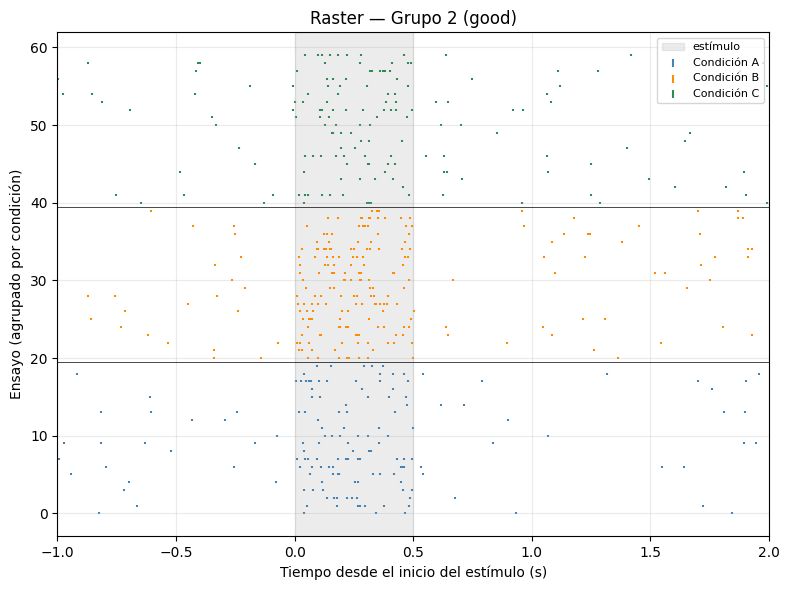

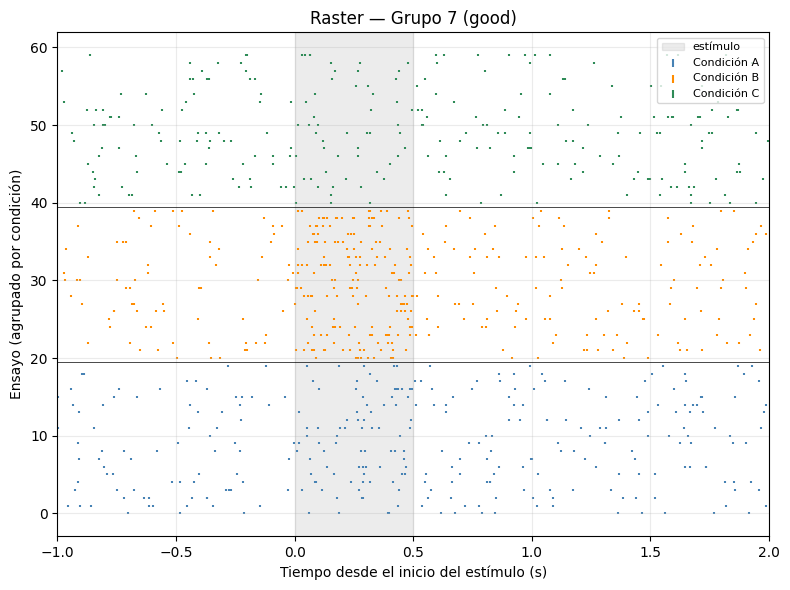

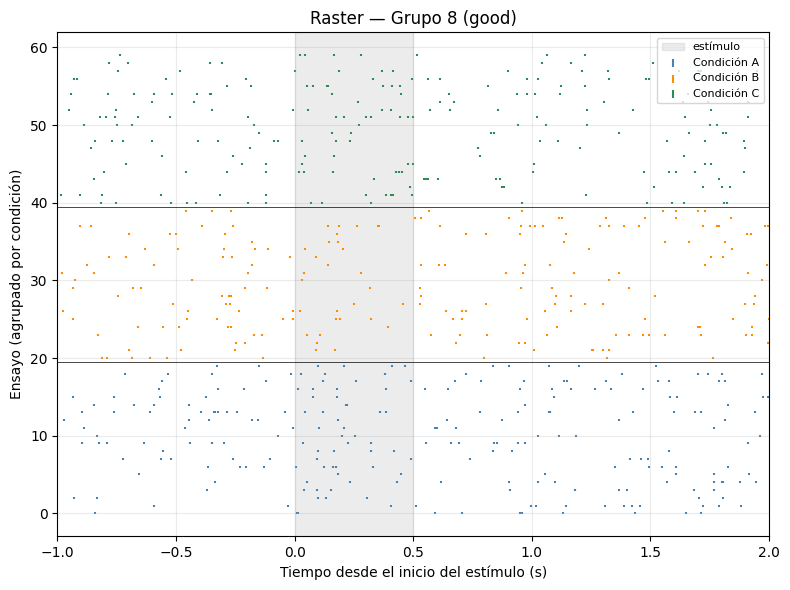

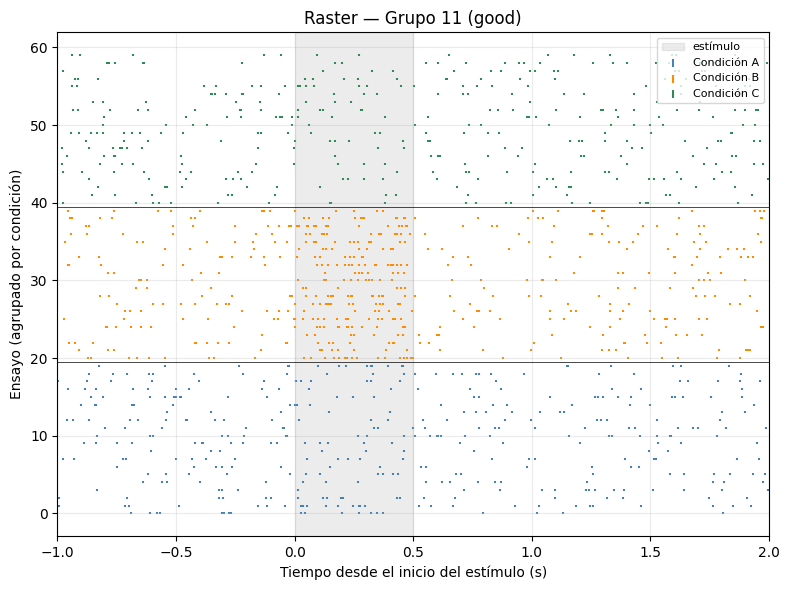

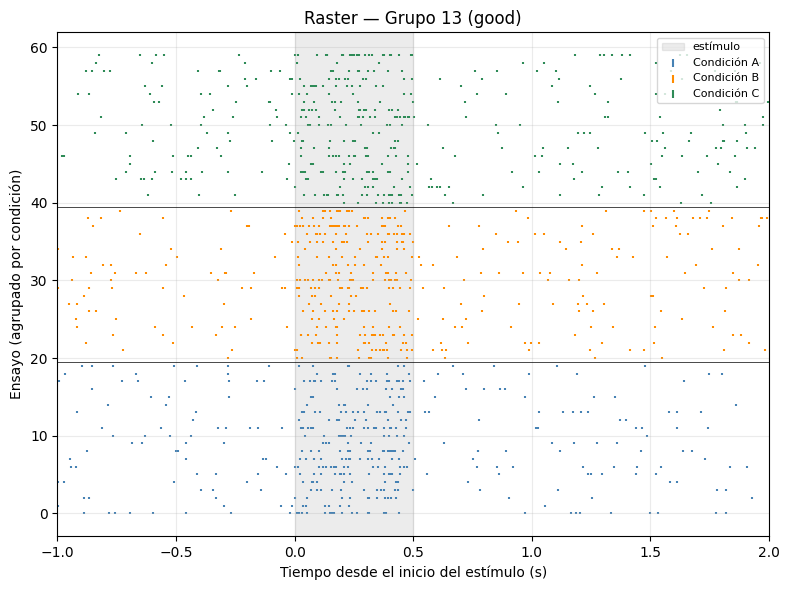

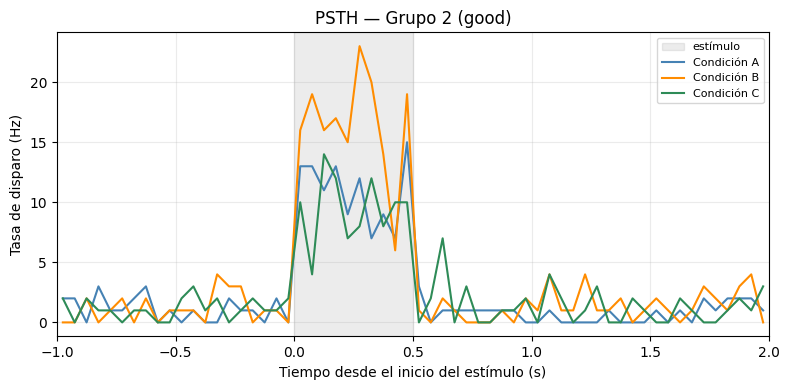

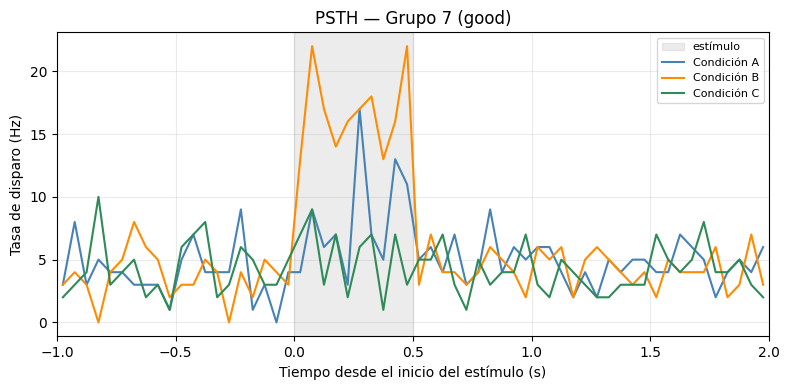

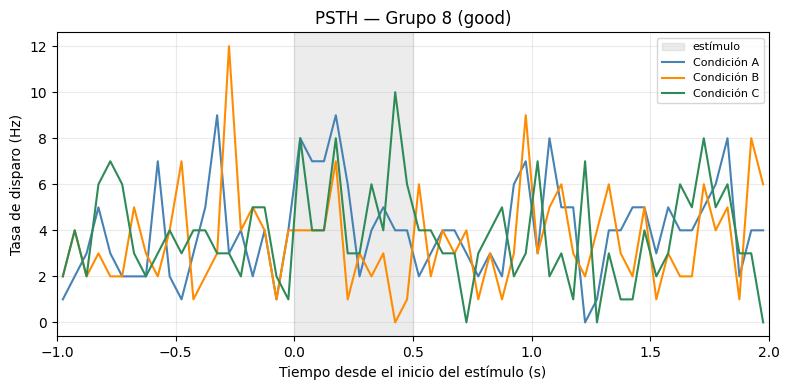

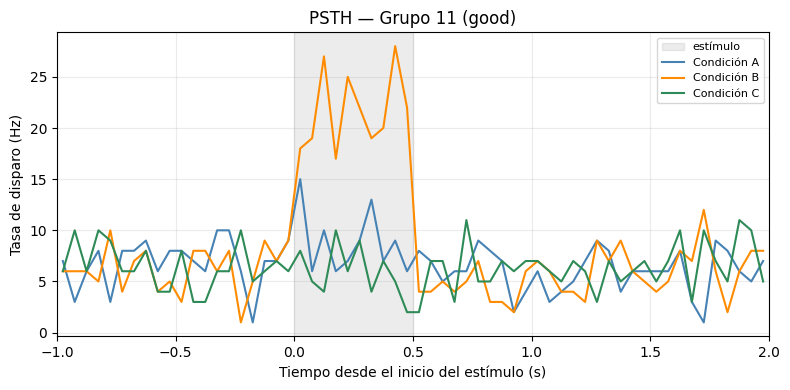

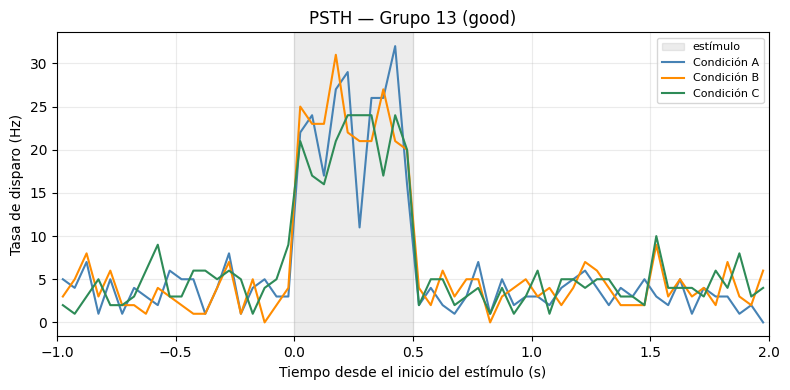

In [69]:
# ✏️ Ejercicio 9
# A)
def tiempos_relativos(tiempos_absolutos_s, inicio_estimulo_s, ventana_pre_s=1.0, ventana_post_s=2.0):
    lista_por_ensayo = []
    for t0 in inicio_estimulo_s:
        en_ventana = (tiempos_absolutos_s >= t0 - ventana_pre_s) & \
                     (tiempos_absolutos_s <= t0 + ventana_post_s)
        disparos_relativos = tiempos_absolutos_s[en_ventana] - t0
        lista_por_ensayo.append(disparos_relativos)
    return lista_por_ensayo

# B)
import matplotlib.pyplot as plt

grupos_good = tabla_curada.loc[tabla_curada['etiqueta'] == 'good', 'grupo'].values
condiciones = sorted(np.unique(condicion_ensayo))
colores_condicion = {condiciones[0]: 'steelblue', condiciones[1]: 'darkorange', condiciones[2]: 'seagreen'}

for g in grupos_good:
    idx_grupo = np.where(etiquetas_curadas == g)[0]
    tiempos_grupo = tiempos_s_r[idx_grupo]

    disparos_por_ensayo = tiempos_relativos(tiempos_grupo, inicio_estimulo_s,
                                              ventana_pre_s=1.0, ventana_post_s=2.0)

    # Reordenar los ensayos: agrupados por condición, para que el raster
    # se lea con las tres condiciones en bloques separados
    orden_ensayos = np.argsort(condicion_ensayo, kind='stable')

    fig, ax = plt.subplots(figsize=(8, 6))

    # Marcar la ventana del estímulo (0 a duracion_estimulo_s, ya relativo al estímulo)
    ax.axvspan(0, duracion_estimulo_s, color='gray', alpha=0.15, label='estímulo')

    fila = 0
    for idx_ensayo in orden_ensayos:
        disparos = disparos_por_ensayo[idx_ensayo]
        cond = condicion_ensayo[idx_ensayo]
        color = colores_condicion[cond]
        ax.scatter(disparos, np.full_like(disparos, fila), s=4, color=color, marker='|')
        fila += 1

    # Líneas divisorias entre bloques de condición
    n_por_condicion = [np.sum(condicion_ensayo == c) for c in condiciones]
    lineas = np.cumsum(n_por_condicion)[:-1]
    for l in lineas:
        ax.axhline(l - 0.5, color='black', linewidth=0.5)

    ax.set_xlabel('Tiempo desde el inicio del estímulo (s)')
    ax.set_ylabel('Ensayo (agrupado por condición)')
    ax.set_title(f'Raster — Grupo {g} (good)')
    ax.set_xlim(-1.0, 2.0)

    for cond, color in colores_condicion.items():
        ax.scatter([], [], color=color, marker='|', label=f'Condición {cond}')
    ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.show()

# C)
def calcular_psth(tiempos_grupo, inicio_estimulo_s, condicion_ensayo, condicion_objetivo,
                   ventana_pre_s=1.0, ventana_post_s=2.0, ancho_bin_s=0.05):
    idx_ensayos_cond = np.where(condicion_ensayo == condicion_objetivo)[0]
    inicios_cond = inicio_estimulo_s[idx_ensayos_cond]
    n_ensayos = len(inicios_cond)

    bordes_s = np.arange(-ventana_pre_s, ventana_post_s + ancho_bin_s, ancho_bin_s)
    conteo_total = np.zeros(len(bordes_s) - 1)

    for t0 in inicios_cond:
        en_ventana = (tiempos_grupo >= t0 - ventana_pre_s) & (tiempos_grupo <= t0 + ventana_post_s)
        disparos_rel = tiempos_grupo[en_ventana] - t0
        conteo, _ = np.histogram(disparos_rel, bins=bordes_s)
        conteo_total += conteo

    tasa_hz = conteo_total / (n_ensayos * ancho_bin_s)
    centros_s = (bordes_s[:-1] + bordes_s[1:]) / 2
    return centros_s, tasa_hz


ancho_bin_s = 0.05  # 50 ms; ajustar si se ve muy ruidoso o muy suavizado

for g in grupos_good:
    idx_grupo = np.where(etiquetas_curadas == g)[0]
    tiempos_grupo = tiempos_s_r[idx_grupo]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axvspan(0, duracion_estimulo_s, color='gray', alpha=0.15, label='estímulo')

    for cond in condiciones:
        centros_s, tasa_hz = calcular_psth(tiempos_grupo, inicio_estimulo_s, condicion_ensayo,
                                             cond, ventana_pre_s=1.0, ventana_post_s=2.0,
                                             ancho_bin_s=ancho_bin_s)
        ax.plot(centros_s, tasa_hz, label=f'Condición {cond}', color=colores_condicion[cond])

    ax.set_xlabel('Tiempo desde el inicio del estímulo (s)')
    ax.set_ylabel('Tasa de disparo (Hz)')
    ax.set_title(f'PSTH — Grupo {g} (good)')
    ax.set_xlim(-1.0, 2.0)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


**P9.**

**Selección múltiple.** Si el ancho de la ventana del PSTH es demasiado grande, lo que ocurre es que

- **a)** el PSTH se llena de picos espurios
- **b)** se pierde la resolución temporal: una respuesta corta queda diluida en la ventana
- **c)** cambia el número total de disparos
- **d)** el raster cambia también

**Abierta.** Mirando **sólo el raster**, antes de calcular nada: ¿cuáles unidades responden al
estímulo y a cuáles condiciones? Hagan la lista. Después digan qué ancho de ventana escogieron para
el PSTH y qué se pierde con los otros dos que probaron.

*Su respuesta:*

**Selección múltiple:** **b)** se pierde la resolución temporal: una respuesta corta queda diluida en la . Un bin más ancho promedia disparos de un tramo más largo de tiempo. Una respuesta que en realidad dura pocas decenas de milisegundos queda repartida dentro de ese bin y se ve como una subida suave y tardía, en vez del cambio abrupto real pues se pierde el momento exacto en que empieza la respuesta, no el número de disparos ni la forma del raster.

**Abierta:**
- Grupo 2 — responde a las tres condiciones (A, B y C): en las tres bandas se ve una franja claramente más densa de puntos dentro de la zona sombreada (0-0.5 s) que fuera de ella.
- Grupo 7 — responde principalmente a B (la más marcada) y también a A; en C la densidad dentro y fuera del estímulo es parecida, sin un cambio claro.
- Grupo 8 — no muestra una respuesta clara a ninguna condición: en las tres bandas los puntos se ven repartidos de forma bastante pareja dentro y fuera de la ventana del estímulo.
- Grupo 11 — responde con fuerza a B, de forma más moderada a A; en C no hay aumento de densidad (incluso se ve una leve caída durante el estímulo).
- Grupo 13 — responde a las tres condiciones, y es la respuesta más fuerte de las cinco unidades: las tres bandas muestran una franja muy densa dentro del estímulo.

Ancho de ventana elegido: 50 ms (0.05 s). Con ese ancho la curva del PSTH muestra claramente el momento en que empieza la respuesta sin verse tan dentada como para parecer puro ruido.

Con los otros dos anchos:

- Para una ventana más angosta como de 10 ms: cada bin recibe muy pocos disparos, así que la curva se vuelve dentada y ruidosa con variaciones que son puro azar de conteo se ven como si fueran picos de actividad real, y se vuelve difícil distinguir la forma genuina de la respuesta del ruido de muestreo.
- Para una ventana más ancha como de 200 ms: la curva sale mucho más suave, pero el inicio de la respuesta deja de verse como un salto definido ya que se estira en una subida gradual que empieza a adelantarse al estímulo real, porque el bin que cubre justo el borde de 0.0 s mezcla actividad de antes y de después del inicio. Se pierde exactamente la información que muestra la selección múltiple: la resolución temporal de cuándo empieza realmente la respuesta.


---
# 10 · ¿La respuesta es real? Z-score, t-test y bootstrap

Tres herramientas, y cada una contesta una pregunta distinta. Esto es lo que vieron en las sesiones de
estadística, aplicado a sus propios datos.

**El Z-score responde: ¿cuánto se salió esta unidad de lo que hace normalmente?** Se toma la actividad
basal de la unidad (el segundo anterior al estímulo, en todos los ensayos), se calculan su media y su
desviación estándar, y la respuesta se expresa en cuántas desviaciones estándar por encima de esa
basal quedó. Sirve para **comparar unidades entre sí**, y en este registro hay un caso que lo muestra
bien: dos de las unidades llegan casi a la misma tasa durante el estímulo, unos 41 Hz las dos, pero
una parte de una basal de 4,9 Hz y la otra de 10,6 Hz. En hertz crudos son indistinguibles; en
Z-score, una queda muy por encima de la otra. Ustedes van a encontrar ese par en el ejercicio 12.

**El t-test responde: ¿esta diferencia se explica por el azar?** Compara la tasa durante el estímulo
contra la basal, ensayo por ensayo (pareado), o compara dos condiciones entre sí. Da un valor p, que
es la probabilidad de observar una diferencia al menos tan grande como la que vieron si en realidad no
hubiera ninguna diferencia.

**El bootstrap responde: ¿qué tan precisa es mi medición?** En vez de suponer que los datos siguen una
campana, se remuestrean los ensayos con reemplazo miles de veces, se calcula la media de cada
remuestreo, y se toma el rango que contiene el 95 % central de esas medias. Ese es el intervalo de
confianza. Funciona aunque los datos no sean normales, que es el caso habitual con tasas de disparo.

⚠️ **Trampa conceptual, y es la más importante del taller.** Tienen 20 ensayos por condición, pero esos
20 ensayos son de **la misma neurona en el mismo animal**. No son 20 observaciones independientes de
"cómo responden las neuronas a este estímulo": son 20 observaciones de una sola neurona. Tratarlas
como si fueran independientes para hablar de la población se llama **pseudorreplicación** y es uno de
los errores más comunes en la literatura. Sus conclusiones estadísticas valen **para cada unidad por
separado**, no para "las neuronas de esta estructura".

### ✏️ Ejercicio 10

Para cada unidad `good` y cada condición:

**a)** La tasa basal y la tasa durante el estímulo, ensayo por ensayo.

**b)** El Z-score de la respuesta respecto a la basal de esa unidad.

**c)** Un t-test pareado, basal contra estímulo.

**d)** El intervalo de confianza del 95 % de la tasa evocada, por bootstrap con al menos 5000
remuestreos.

Armen una tabla con todo.

In [70]:
# ✏️ Ejercicio 10
import numpy as np
import pandas as pd
from scipy import stats

n_bootstrap = 5000
rng = np.random.default_rng(0)

duracion_basal_s = 1.0  # el segundo anterior al estímulo

filas = []

for g in grupos_good:
    idx_grupo = np.where(etiquetas_curadas == g)[0]
    tiempos_grupo = tiempos_s_r[idx_grupo]

    for cond in condiciones:
        idx_ensayos_cond = np.where(condicion_ensayo == cond)[0]
        inicios_cond = inicio_estimulo_s[idx_ensayos_cond]
        n_ensayos = len(inicios_cond)

        # --- a) Tasa basal y tasa evocada, ensayo por ensayo ---
        tasas_basal = np.zeros(n_ensayos)
        tasas_evocada = np.zeros(n_ensayos)

        for i, t0 in enumerate(inicios_cond):
            # Basal: el segundo anterior al estímulo (t0 - 1.0 a t0)
            n_basal = np.sum((tiempos_grupo >= t0 - duracion_basal_s) & (tiempos_grupo < t0))
            tasas_basal[i] = n_basal / duracion_basal_s

            # Evocada: la duración del estímulo (t0 a t0 + duracion_estimulo_s)
            n_evocada = np.sum((tiempos_grupo >= t0) & (tiempos_grupo < t0 + duracion_estimulo_s))
            tasas_evocada[i] = n_evocada / duracion_estimulo_s

        media_basal = tasas_basal.mean()
        std_basal = tasas_basal.std(ddof=1)
        media_evocada = tasas_evocada.mean()

        # --- b) Z-score de la respuesta respecto a la basal de esa unidad ---
        if std_basal > 0:
            z_score = (media_evocada - media_basal) / std_basal
        else:
            z_score = np.nan

        # --- c) t-test pareado, basal contra estímulo ---
        t_stat, p_valor = stats.ttest_rel(tasas_evocada, tasas_basal)

        # --- d) Intervalo de confianza 95% de la tasa evocada, por bootstrap ---
        medias_bootstrap = np.zeros(n_bootstrap)
        for b in range(n_bootstrap):
            remuestra = rng.choice(tasas_evocada, size=n_ensayos, replace=True)
            medias_bootstrap[b] = remuestra.mean()
        ic_bajo, ic_alto = np.percentile(medias_bootstrap, [2.5, 97.5])

        filas.append({
            'grupo': g,
            'condicion': cond,
            'n_ensayos': n_ensayos,
            'tasa_basal_hz': media_basal,
            'std_basal_hz': std_basal,
            'tasa_evocada_hz': media_evocada,
            'z_score': z_score,
            't_stat': t_stat,
            'p_valor': p_valor,
            'ic95_bajo_hz': ic_bajo,
            'ic95_alto_hz': ic_alto,
        })

tabla_estadistica = pd.DataFrame(filas)

# Marca de significancia, con el umbral clásico de 0.05
tabla_estadistica['significativo'] = tabla_estadistica['p_valor'] < 0.05

pd.set_option('display.max_columns', None)
tabla_estadistica.round(3)

,grupo,condicion,n_ensayos,tasa_basal_hz,std_basal_hz,tasa_evocada_hz,z_score,t_stat,p_valor,ic95_bajo_hz,ic95_alto_hz,significativo
0,2,A,20,1.10,1.071,10.9,9.149,7.452,0.000,8.6,13.5,True
1,2,B,20,1.10,0.788,16.5,19.541,11.972,0.000,14.2,19.0,True
2,2,C,20,1.15,1.040,9.5,8.029,8.769,0.000,7.7,11.3,True
3,7,A,20,3.90,2.075,8.2,2.072,4.013,0.001,6.5,10.0,True
4,7,B,20,3.65,1.755,16.8,7.491,8.385,0.000,14.2,19.5,True
5,7,C,20,4.25,1.743,5.2,0.545,1.392,0.180,4.2,6.2,False
6,8,A,20,3.25,2.403,5.6,0.978,3.467,0.003,4.7,6.5,True
7,8,B,20,3.60,1.569,2.9,-0.446,-1.187,0.250,1.9,4.0,False
8,8,C,20,3.55,2.395,5.6,0.856,2.047,0.055,3.8,7.5,False
9,11,A,20,6.85,2.346,8.8,0.831,1.688,0.108,6.9,10.9,False


**P10.**

**Selección múltiple.** Una unidad tiene la tasa evocada más alta en hertz, pero no el Z-score más
alto. La explicación es que

- **a)** tiene menos ensayos que las demás
- **b)** su actividad basal es más variable, y el Z-score divide por esa variabilidad
- **c)** el t-test no se le puede aplicar
- **d)** su respuesta empieza más tarde

**Abierta.** Elijan una unidad cuyo t-test dé un p pequeño y otra que dé un p grande, y expliquen la
diferencia mirando la **variabilidad entre ensayos**, no sólo las medias. ¿Algún intervalo de
confianza por bootstrap incluye la tasa basal? ¿Qué concluyen de esa unidad?

*Su respuesta:*

**Selección múltiple:** **b)** su actividad basal es más variable, y el Z-score divide por esa variabilidad. Lo anterior pues el Z-score es (evocada − basal) / std_basal. Dos unidades pueden llegar a la misma tasa evocada en Hz, pero si una tiene una basal más ruidosa, ese mismo salto representa menos desviaciones estándar por encima de "lo normal" para ella ya que el denominador más grande achica el Z-score aunque el numerador sea igual o mayor.

**Abierta:**

- Para un p pequeño elijÍ el grupo 13 con la condicion c (p = 0.000, t = 7.342): la basal es 4.30 Hz con una desviación de 2.45 Hz, y la tasa evocada sube a 20.8 Hz por lo que es un salto de 16.5 Hz, más de 6 veces la variabilidad de la basal. Aunque la basal de esta unidad no es especialmente estable, el tamaño del cambio es tan grande que domina por completo esa variabilidad: no hay forma de que 20 ensayos con basal alrededor de 4 Hz produzcan por azar una subida de ese tamaño de forma consistente. Por eso el t-test da un p prácticamente nulo.

- Para un p pequeño elijÍ el grupo 11 con la condicion c (p = 0.631, t = −0.488): la basal es 6.45 Hz con una desviación de 2.50 Hz pero la tasa evocada es 6.0 Hz, prácticamente igual a la basal incluso un poco menor. El cambio de −0.45 Hz es mucho más pequeño que la variabilidad ensayo a ensayo de la propia basal, cualquier par de bloques de 20 ensayos de esta misma unidad, sin que pase nada distinto, probablemente ya difiere por azar en más de 0.45 Hz. El t-test no encuentra nada que separar del ruido normal de la neurona, y el p alto lo refleja.

En resumen, no basta con mirar las medias ya que la diferencia entre significativo y no significativo no depende solo de cuanto cambio la tasa, sino de que tan grande es ese cambio de relación con lo que varia la unidad de un ensayo a otro.

---
# 11 · La figura final

Una figura de resultados de cuatro paneles, con todas las unidades `good` juntas. Esta sección se
califica panel por panel.

**Panel A.** La sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de
onda promedio de cada una. Es la figura que dice "esto fue lo que registramos".

**Panel B.** El raster de una sola unidad, con las tres condiciones. Escojan una que responda a una
condición y no a las otras, que es la que hace visible el contraste.

**Panel C.** **El PSTH general por estímulo**: todas las unidades `good` promediadas, una curva por
condición, con su banda de confianza.

**Panel D.** **El swarmplot por estímulo**: un punto por ensayo, agrupados por condición, con la media
y su intervalo de confianza encima. Un swarmplot muestra todos los datos, que es lo que un diagrama de
barras esconde.

**Reglas de figura científica, y aquí sí se evalúan una por una:**

1. Todos los ejes rotulados, con unidades.
2. Escalas de tiempo iguales entre paneles que se comparan.
3. Nada de rojo y verde como única distinción entre categorías.
4. La ventana del estímulo marcada de la misma forma en todos los paneles.
5. Cada panel legible sin leer el texto: si hay que explicarlo, falta un rótulo.
6. Pie de figura que diga qué se muestra, cuántos ensayos y qué representan las barras de error.

### ✏️ Ejercicio 11

/tmp/ipykernel_2733/4273785517.py:234: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


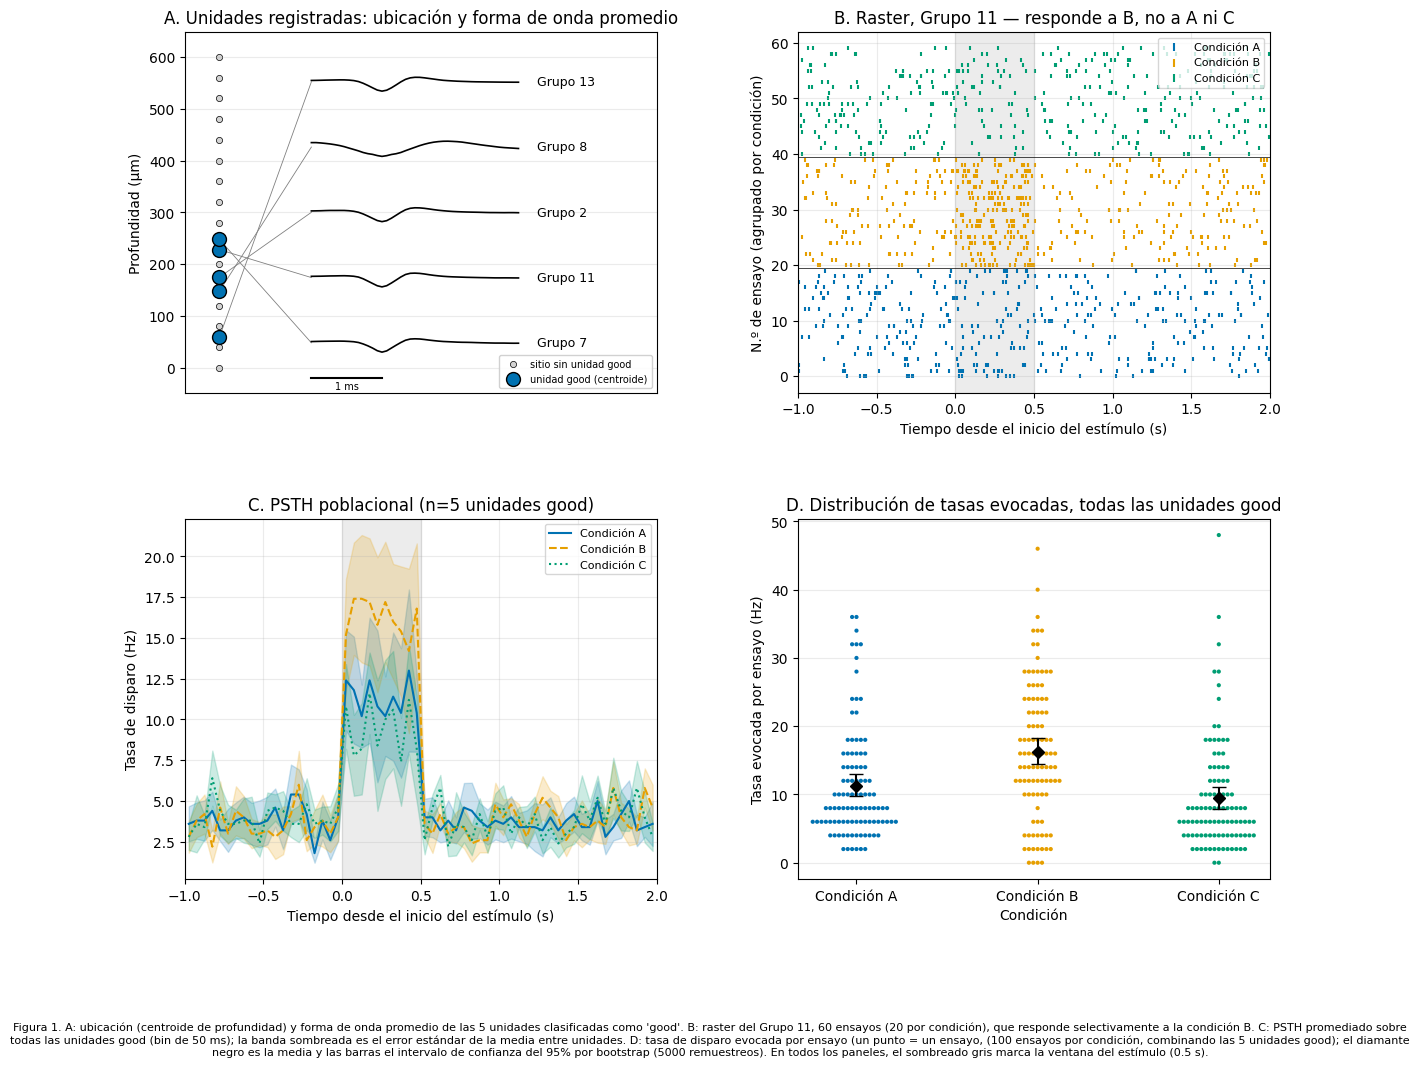

In [71]:
# ✏️ Ejercicio 11
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Paleta segura para daltonismo (Okabe-Ito), con más de un canal de codificación
# (color + estilo de línea) para no depender solo del color
colores_condicion = {'A': '#0072B2', 'B': '#E69F00', 'C': '#009E73'}  # azul, naranja, verde
estilos_condicion = {'A': '-', 'B': '--', 'C': ':'}

grupo_panel_b = 11  # responde selectivamente a B, no a A ni C

fig = plt.figure(figsize=(14, 11))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# =========================================================================
# PANEL A: la sonda con las unidades en su centroide, y su forma de onda
# =========================================================================
ax_a = fig.add_subplot(gs[0, 0])

# Silueta de los 16 sitios de la sonda
ax_a.scatter(np.zeros(16), canal_y_um_r, s=20, color='lightgray',
             edgecolor='black', linewidth=0.5, zorder=1)

# Ordenar las unidades por profundidad real, de más superficial a más profunda
info_unidades = []
for g in grupos_good:
    idx_grupo = np.where(etiquetas_curadas == g)[0]
    centroide_g = centroides_um_r[idx_grupo].mean()
    canal_dom = np.bincount(canal_pico_r[idx_grupo]).argmax()
    onda_prom = formas_onda_r[idx_grupo, canal_dom, :].mean(axis=0)
    info_unidades.append({'grupo': g, 'centroide': centroide_g, 'onda': onda_prom})

info_unidades.sort(key=lambda d: d['centroide'])  # de menor a mayor profundidad

n_unidades = len(info_unidades)
profundidad_min, profundidad_max = canal_y_um_r.min(), canal_y_um_r.max()

# Posiciones de despliegue: repartidas EN ORDEN a lo largo de todo el rango
# de la sonda, para que nunca queden dos unidades a la misma altura visual,
# aunque su profundidad real sí coincida
margen = 0.08 * (profundidad_max - profundidad_min)
y_despliegue = np.linspace(profundidad_max - margen, profundidad_min + margen, n_unidades)

x_marca_sonda = 0
x_inicio_onda = 40     # dónde empieza la línea guía / la forma de onda
x_ancho_onda = 90      # ancho horizontal reservado a cada forma de onda
escala_onda = 18       # escala vertical de la forma de onda, en µm

for i, info in enumerate(info_unidades):
    g = info['grupo']
    prof_real = info['centroide']
    y_disp = y_despliegue[i]
    onda = info['onda']

    # Marca en la profundidad REAL sobre la sonda
    ax_a.scatter([x_marca_sonda], [prof_real], s=100, color='#0072B2',
                 edgecolor='black', zorder=3)

    # Línea guía delgada desde la profundidad real hasta la fila de despliegue
    ax_a.plot([x_marca_sonda, x_inicio_onda], [prof_real, y_disp],
              color='gray', linewidth=0.6, zorder=2)

    # Forma de onda dibujada en su fila de despliegue (ya no en su y real)
    x_onda = x_inicio_onda + (t_ventana_ms - t_ventana_ms.min()) / \
             (t_ventana_ms.max() - t_ventana_ms.min()) * x_ancho_onda
    y_onda = y_disp + onda / np.abs(onda).max() * escala_onda
    ax_a.plot(x_onda, y_onda, color='black', linewidth=1.2, zorder=3)

    # Etiqueta a la derecha de cada forma de onda
    ax_a.text(x_inicio_onda + x_ancho_onda + 8, y_disp, f'Grupo {g}',
              fontsize=9, va='center')
# --- Barra de escala de tiempo para las formas de onda (reemplaza la nota entre paréntesis) ---
x_escala_ini = x_inicio_onda
x_escala_fin = x_inicio_onda + (1.0 / (t_ventana_ms.max() - t_ventana_ms.min())) * x_ancho_onda
y_escala = profundidad_min - 0.4 * margen

ax_a.plot([x_escala_ini, x_escala_fin], [y_escala, y_escala], color='black', linewidth=1.5)
ax_a.text((x_escala_ini + x_escala_fin) / 2, y_escala - 0.15 * margen, '1 ms',
          ha='center', va='top', fontsize=7)

# --- Nota para los puntos grises (sitios sin unidad good asignada) ---
ax_a.scatter([], [], s=20, color='lightgray', edgecolor='black', linewidth=0.5,
             label='sitio sin unidad good')
ax_a.scatter([], [], s=100, color='#0072B2', edgecolor='black',
             label='unidad good (centroide)')
ax_a.legend(loc='lower right', fontsize=7, framealpha=0.9)

# Quitar el texto entre paréntesis del xlabel, ya que la barra de escala lo reemplaza
ax_a.set_xlabel('')
ax_a.set_xlim(-15, x_inicio_onda + x_ancho_onda + 60)
ax_a.set_ylim(profundidad_min - margen, profundidad_max + margen)

ax_a.set_ylabel('Profundidad (µm)')
ax_a.set_title('A. Unidades registradas: ubicación y forma de onda promedio')
ax_a.set_xticks([])

# =========================================================================
# PANEL B: raster de una sola unidad, tres condiciones
# =========================================================================
ax_b = fig.add_subplot(gs[0, 1])

idx_grupo_b = np.where(etiquetas_curadas == grupo_panel_b)[0]
tiempos_b = tiempos_s_r[idx_grupo_b]
disparos_por_ensayo_b = tiempos_relativos(tiempos_b, inicio_estimulo_s,
                                            ventana_pre_s=1.0, ventana_post_s=2.0)
orden_ensayos_b = np.argsort(condicion_ensayo, kind='stable')

ax_b.axvspan(0, duracion_estimulo_s, color='gray', alpha=0.15)

fila = 0
for idx_ensayo in orden_ensayos_b:
    disparos = disparos_por_ensayo_b[idx_ensayo]
    cond = condicion_ensayo[idx_ensayo]
    ax_b.scatter(disparos, np.full_like(disparos, fila), s=6,
                 color=colores_condicion[cond], marker='|')
    fila += 1

n_por_condicion = [np.sum(condicion_ensayo == c) for c in condiciones]
for l in np.cumsum(n_por_condicion)[:-1]:
    ax_b.axhline(l - 0.5, color='black', linewidth=0.5)

ax_b.set_xlim(-1.0, 2.0)
ax_b.set_xlabel('Tiempo desde el inicio del estímulo (s)')
ax_b.set_ylabel('N.º de ensayo (agrupado por condición)')
ax_b.set_title(f'B. Raster, Grupo {grupo_panel_b} — responde a B, no a A ni C')
for cond in condiciones:
    ax_b.scatter([], [], color=colores_condicion[cond], marker='|', label=f'Condición {cond}')
ax_b.legend(loc='upper right', fontsize=8)

# =========================================================================
# PANEL C: PSTH poblacional, todas las good promediadas, con banda de confianza
# =========================================================================
ax_c = fig.add_subplot(gs[1, 0])
ax_c.axvspan(0, duracion_estimulo_s, color='gray', alpha=0.15)

ancho_bin_s = 0.05

for cond in condiciones:
    psth_por_unidad = []
    for g in grupos_good:
        idx_grupo = np.where(etiquetas_curadas == g)[0]
        tiempos_grupo = tiempos_s_r[idx_grupo]
        centros_s, tasa_hz = calcular_psth(tiempos_grupo, inicio_estimulo_s, condicion_ensayo,
                                             cond, ventana_pre_s=1.0, ventana_post_s=2.0,
                                             ancho_bin_s=ancho_bin_s)
        psth_por_unidad.append(tasa_hz)

    psth_por_unidad = np.array(psth_por_unidad)  # (n_unidades, n_bins)
    media_psth = psth_por_unidad.mean(axis=0)
    sem_psth = psth_por_unidad.std(axis=0, ddof=1) / np.sqrt(psth_por_unidad.shape[0])

    ax_c.plot(centros_s, media_psth, color=colores_condicion[cond],
              linestyle=estilos_condicion[cond], label=f'Condición {cond}')
    ax_c.fill_between(centros_s, media_psth - sem_psth, media_psth + sem_psth,
                       color=colores_condicion[cond], alpha=0.2)

ax_c.set_xlim(-1.0, 2.0)
ax_c.set_xlabel('Tiempo desde el inicio del estímulo (s)')
ax_c.set_ylabel('Tasa de disparo (Hz)')
ax_c.set_title(f'C. PSTH poblacional (n={len(grupos_good)} unidades good)')
ax_c.legend(fontsize=8)

# =========================================================================
# PANEL D: swarmplot por condición, media + IC95% por bootstrap
# =========================================================================
ax_d = fig.add_subplot(gs[1, 1])

try:
    import seaborn as sns
    usar_seaborn = True
except ImportError:
    usar_seaborn = False

datos_swarm = tabla_estadistica[['grupo', 'condicion', 'tasa_evocada_hz']].copy()
# Para el swarm necesitamos la tasa evocada POR ENSAYO, no solo el promedio;
# la recalculamos aquí para tener el detalle completo
filas_swarm = []
for g in grupos_good:
    idx_grupo = np.where(etiquetas_curadas == g)[0]
    tiempos_grupo = tiempos_s_r[idx_grupo]
    for cond in condiciones:
        idx_ensayos_cond = np.where(condicion_ensayo == cond)[0]
        inicios_cond = inicio_estimulo_s[idx_ensayos_cond]
        for t0 in inicios_cond:
            n_evocada = np.sum((tiempos_grupo >= t0) & (tiempos_grupo < t0 + duracion_estimulo_s))
            filas_swarm.append({'condicion': cond, 'tasa_hz': n_evocada / duracion_estimulo_s, 'grupo': g})

df_swarm = pd.DataFrame(filas_swarm)

if usar_seaborn:
    sns.swarmplot(data=df_swarm, x='condicion', y='tasa_hz', hue='condicion',
                  palette=colores_condicion, order=condiciones, size=3, ax=ax_d, legend=False)
else:
    for i, cond in enumerate(condiciones):
        valores = df_swarm.loc[df_swarm['condicion'] == cond, 'tasa_hz'].values
        jitter = (np.random.rand(len(valores)) - 0.5) * 0.3
        ax_d.scatter(np.full_like(valores, i, dtype=float) + jitter, valores,
                     s=8, color=colores_condicion[cond], alpha=0.6)
n_unidades_good = len(grupos_good)
n_ensayos_por_condicion_unidad = n_por_condicion[0]  # 20, asumiendo el mismo n por condición
n_puntos_swarm_por_condicion = n_unidades_good * n_ensayos_por_condicion_unidad  # 100

# Media e IC95% por bootstrap, superpuestos
for i, cond in enumerate(condiciones):
    valores = df_swarm.loc[df_swarm['condicion'] == cond, 'tasa_hz'].values
    media = valores.mean()
    remuestras = np.array([rng.choice(valores, size=len(valores), replace=True).mean()
                            for _ in range(n_bootstrap)])
    ic_bajo, ic_alto = np.percentile(remuestras, [2.5, 97.5])
    ax_d.errorbar([i], [media], yerr=[[media - ic_bajo], [ic_alto - media]],
                  fmt='D', color='black', markersize=6, capsize=5, zorder=5)

ax_d.set_xticks(range(len(condiciones)))
ax_d.set_xticklabels([f'Condición {c}' for c in condiciones])
ax_d.set_xlabel('Condición')
ax_d.set_ylabel('Tasa evocada por ensayo (Hz)')
ax_d.set_title('D. Distribución de tasas evocadas, todas las unidades good')

# =========================================================================
# Pie de figura
# =========================================================================
fig.text(0.5, -0.02,
    f"Figura 1. A: ubicación (centroide de profundidad) y forma de onda promedio de las {len(grupos_good)} unidades "
    f"clasificadas como 'good'. B: raster del Grupo {grupo_panel_b}, {sum(n_por_condicion)} ensayos "
    f"(20 por condición), que responde selectivamente a la condición B. C: PSTH promediado sobre todas las "
    f"unidades good (bin de {int(ancho_bin_s*1000)} ms); la banda sombreada es el error estándar de la media "
    f"entre unidades. D: tasa de disparo evocada por ensayo (un punto = un ensayo, ({n_puntos_swarm_por_condicion} ensayos por condición, "
    f"combinando las {n_unidades_good} unidades good); el diamante negro es la media y las barras el intervalo de "
    f"confianza del 95% por bootstrap (5000 remuestreos). En todos los paneles, el sombreado gris marca la "
    f"ventana del estímulo ({duracion_estimulo_s} s).",
    ha='center', va='top', fontsize=8, wrap=True)

plt.tight_layout()
plt.savefig('figura_final.png', dpi=150, bbox_inches='tight')
plt.show()

**P11.**

**Selección múltiple.** El PSTH general del panel C promedia unidades que responden a cosas
distintas. Lo que ese promedio esconde es

- **a)** el número total de disparos
- **b)** la selectividad de cada unidad: mezcla respuestas a condiciones distintas en una sola curva
- **c)** la latencia de la respuesta
- **d)** la tasa basal

**Abierta.** Escriban el pie de la figura completo, como iría en un artículo: qué hay en cada panel,
cuántas unidades, cuántos ensayos, qué son las barras de error.

*Su respuesta:*

**Selección múltiple:** **b)** la selectividad de cada unidad: mezcla respuestas a condiciones distintas en una sola curva. Entonces, el PSTH poblacional promedia todas las unidades good para cada condición, pero cada unidad responde a condiciones distintas (unas a las tres, otras solo a una, otras a ninguna). El promedio no representa fielmente a ninguna unidad individual: mezcla las que sí cambiaron con las que no, escondiendo esa heterogeneidad de selectividad.


**Abierta:** En la figura generada anteriormente se encuentra un breve resumen para su pie de figura, a continuacion de muestra el pie de figura completo.

Figura 1. Respuesta de las unidades bien aisladas a las tres condiciones de estímulo.

(A) Ubicación en la sonda (centroide de profundidad, eje real) y forma de onda promedio en el canal pico de las 5 unidades clasificadas como good; las formas de onda se muestran desplazadas verticalmente para evitar solapamiento, con una línea guía hasta su profundidad real. (B) Raster del Grupo 11, elegido por mostrar selectividad clara: 60 ensayos (20 por condición, agrupados por bloques de color), un punto por potencial de acción, alineados al inicio del estímulo. (C) Histograma peri-estímulo (PSTH) promediado sobre las 5 unidades good, una curva por condición (bin de 50 ms); la banda sombreada es el error estándar de la media entre unidades (n=5). (D) Tasa de disparo evocada por ensayo durante la ventana del estímulo, agrupada por condición (un punto = un ensayo, combinando las 5 unidades: 100 ensayos por condición); el diamante negro marca la media y las barras el intervalo de confianza del 95% obtenido por bootstrap (5000 remuestreos, remuestreo de ensayos con reemplazo). En todos los paneles con eje de tiempo, el sombreado gris marca la ventana del estímulo (0 a 0.5 s desde su inicio).




---
# 12 · Conclusión y conversación con la IA

### ✏️ Ejercicio 12a · El párrafo de resultados

Escriban un párrafo de resultados, como iría en un artículo. Máximo 200 palabras. Tiene que decir:
cuántas unidades registraron y cuántas sobrevivieron a la curación, qué criterios usaron para
descartar las demás, qué unidades respondieron a qué condiciones, y con qué evidencia estadística.

Nada de "se observó que" ni "los datos sugieren". Números.

**Resultados:**

Detectamos 19091 eventos en el registro ruidoso, filtrando 34 con anchura fuera del rango fisiológico (0.05-1.5 ms). K-means (k=16) sobre amplitud, anchura y centroide de profundidad, más la fusión de dos grupos con correlograma cruzado vacío (razón 0.60) y formas de onda idénticas, dio 15 grupos. De estos, 5 unidades (Grupos 2, 7, 8, 11 y 13; 5046 disparos) pasaron los siete criterios de bombcell y se clasificaron good (2 o menos picos y valles, duración 100-1150 µs, pendiente < −0.004, violaciones del refractario <1.5%, disparos faltantes <20%, al menos 300 disparos, razón pico/valle <0.8)cabe recordar el caso del Grupo 11 descrito de manera previa; 8 grupos se etiquetaron mua (refractario 2.8-28.0%, o faltantes 27-34%) y 2 noise (pendiente > −0.004, forma no neuronal). Frente a la verdad sintética, la curación elevó la fracción de disparos identificables individualmente de 0.650 a 0.956 (12 de 15 etiquetas correctas). En la ventana de estímulo (0-0.5 s), los Grupos 2 y 13 respondieron a las tres condiciones (p<0.001, t-test pareado); el Grupo 11 respondió solo a B (Z=6.31, p<0.001; A y C no significativos, p=0.108 y p=0.631); el Grupo 7 respondió a A y B (p≤0.001) pero no a C (p=0.180); el Grupo 8 no mostró respuesta consistente en ninguna condición (p≥0.055).





### ✏️ Ejercicio 12b · Tres intercambios con la IA

Documenten tres momentos en que la IA les dio algo equivocado y ustedes lo corrigieron. Para cada uno:
el prompt, la respuesta del modelo, qué estaba mal y cómo lo arreglaron.

Vale más un error entendido que tres respuestas correctas.

Cabe mencionar que los pronts siguientes son diferentes a los solicitados en la seccion 2 y 5 del taller.

**Intercambio 1**

*Prompt:*

Dame el codigo para adrir el taller2_limpia.h5 y averigüar qué contiene: los grupos, los conjuntos de datos, la frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios" [código con f['registro'].attrs['frecuencia_muestreo'] y f['geometria/posiciones']], adicionalmente explicame cada parte de este codigo.

*Respuesta del modelo:*

Generó código asumiendo que los atributos frecuencia_muestreo y escala_uV_por_bit estaban dentro del grupo registro, y que las posiciones venían en un único dataset geometria/posiciones.

*Qué estaba mal:*

Al ejecutarlo salió KeyError: "Unable to synchronously open attribute (can't locate attribute: 'frecuencia_muestreo')". Los atributos en realidad estaban en la raíz del archivo (f.attrs), con otro nombre (frecuencia_muestreo_hz), y las posiciones venían separadas en dos datasets (geometria/canal_x_um, geometria/canal_y_um), no en uno solo.

*Cómo lo corregimos:*

Se corrió f.visititems() junto con un recorrido de f.attrs en cada nivel para imprimir la estructura real del archivo, y se reescribió el código usando las rutas exactas que mostró ese recorrido, armando las posiciones con np.column_stack([canal_x_um, canal_y_um]).

**Intercambio 2**

*Prompt:*

con base en el codigo corregido previo ayudame a convertir tiempos absolutos a tiempos relativos al inicio del estímulo de cada ensayo" [código usando f['estimulos/inicio_s']], resuerda explicarme el codigo.

*Respuesta del modelo:*

Generó una función tiempos_relativos asumiendo que el dataset se llamaba inicio_s y que ese valor ya marcaba el inicio del estímulo.

*Qué estaba mal:*

Salió KeyError: "...object 'inicio_s' doesn't exist". Además, aunque se corrigiera el nombre (el dataset real era tiempo_inicio_s), ese valor marca el inicio del ensayo, no del estímulo — según la nota del propio archivo, el estímulo empieza duracion_pre_s (1.0 s) después. Usarlo directamente habría desplazado toda la ventana del estímulo en los rasters y PSTH sin generar ningún error visible.

*Cómo lo corregimos:*

Se volvió a explorar el grupo estimulos con visititems y sus atributos, se identificó duracion_pre_s = 1.0 en los atributos del grupo, y se calculó inicio_estimulo_s = tiempo_inicio_ensayo_s + duracion_pre_s antes de pasarlo a cualquier función de tiempos relativos.

**Intercambio 3**

*Prompt:*

al ejecutar el código me dio lo siguiente: Con 0.5 ms: 2843 eventos. Con 0.2 ms: 4133 eventos" [seguido, en la sesión completa del taller, del pedido de graficar las tres nubes de la sección 4 sobre la grabación ruidosa]

*Respuesta del modelo:*

Generó el pipeline completo de la sección 4 (cargar, filtrar, detectar, extraer características) y las tres nubes de puntos, sin ningún paso de validación de las características calculadas.

*Qué estaba mal:*

Al correr el código sobre la grabación ruidosa aparecieron puntos con media anchura del valle de 20 y hasta 26 ms en el panel "Amplitud vs. anchura" — un valor físicamente imposible, ya que un potencial de acción completo dura entre 0.6 y 1.4 ms según el propio enunciado del taller. El modelo no anticipó que el algoritmo de interpolación (escrito en la sección 3) podía fallar en señales más ruidosas, dejando que esos valores contaminaran la desviación estándar usada después para estandarizar las características antes de K-means.

*Cómo lo corregimos:*

Se agregó un filtro explícito (anchura_min = 0.05, anchura_max = 1.5 ms) que descarta esos eventos antes de calcular la media y la desviación estándar para el Z-score, aplicando la misma máscara a todas las variables derivadas (amplitudes_r, centroides_um_r, tiempos_s_r, canal_pico_r, formas_onda_r) para mantenerlas alineadas. Sin este filtro, K-means gastaba varios de sus 16 centros aislando esos pocos outliers en vez de separar neuronas reales.

**P12.**

**Selección múltiple.** De estas cuatro decisiones del taller, la más difícil de automatizar es

- **a)** detectar los cruces del umbral
- **b)** calcular la media anchura del valle
- **c)** decidir si dos grupos son la misma neurona o dos vecinas
- **d)** estandarizar las características antes de K-means

**Abierta.** El taller empezó diciendo que un programa automático agrupa mejor que ustedes, pero que
no decide si un grupo es una neurona. Después de haber hecho el trabajo: ¿están de acuerdo? Nombren
**una** decisión concreta que tomaron y que no ven cómo automatizar, y **una** que sí automatizarían.

*Su respuesta:*

**Selección múltiple:** **c)** decidir si dos grupos son la misma neurona o dos vecinas. Lo anterior pues, detectar cruces, calcular la anchura o estandarizar características son operaciones numéricas deterministas: dado el mismo dato, siempre dan el mismo resultado. Decidir si dos grupos son una neurona partida o dos vecinas no tiene una regla numérica limpia pues la prueba del correlograma cruzado tiene un falso positivo conocido, y resolverlo exige comparar visualmente las formas de onda promedio, un juicio cualitativo que no se reduce a un umbral.


**Abierta:**

Después de terminar el taller, sí estoy de acuerdo con la premisa del mismo taller, y este mismo análisis lo confirma dos veces. K-means con k=16 agrupó razonablemente bien pues logró aislar unidades limpias como el Grupo 13 (98% pura), pero por sí solo cometió errores que un programa automático, sin criterio humano, habría dejado pasar: etiquetó como noise dos grupos (3 y 9) que en realidad eran 89-93% MUA real, simplemente porque su pendiente de caída espacial cayó un poco por debajo de un umbral rígido.

- Una decisión que no veo cómo automatizar: la reclasificación del Grupo 11. Fallaba el criterio de refractario por un margen mínimo (1.54% contra el umbral de 1.5%) mientras pasaba todos los demás con holgura (0% de disparos faltantes, pendiente −0.0074, 1431 disparos). Automatizar esto exigiría que el programa "supiera" cuándo un margen es lo bastante pequeño como para ser ruido de estimación y no una violación real y esa intuición depende del contexto de todos los otros criterios juntos, no de un solo número.

- Una que sí automatizaría sin dudar: el cálculo de las siete métricas de bombcell en sí mismas (duración, pendiente, razón pico/valle, etc.) ya que son fórmulas fijas sobre datos ya extraídos, sin ambigüedad, y de hecho ya están automatizadas en la función que escribimos en la sección 5.


---
# Hoja de respuestas

Llenen esta celda al final, cuando ya todo corrió.

- En `seleccion` va **la letra** de cada pregunta de selección múltiple.
- En `numeros` van los valores que les dio **su propio código**. Si un número no coincide con lo que
  produce su notebook, no cuenta: la idea no es acertarle, es que su pipeline y su reporte digan lo
  mismo.


In [72]:
# ✏️ Hoja de respuestas

seleccion = {
    "P1":  "a",   "P2":  "b",   "P3":  "d",   "P4":  "b",
    "P5":  "c",   "P6":  "b",   "P7":  "d",   "P8":  "b",
    "P9":  "b",   "P10": "b",   "P11": "b",   "P12": "c",
}

numeros = {
    "eventos_limpia":        len(tiempos_05),                                          # sección 2
    "eventos_ruidosa":       len(amplitudes_r),                                        # sección 4, ya filtrado
    "k_elegido":             k_elegido,                                                # sección 4
    "grupos_good":           int((tabla_curada['etiqueta'] == 'good').sum()),           # sección 7
    "grupos_mua":            int((tabla_curada['etiqueta'] == 'mua').sum()),            # sección 7
    "grupos_nonsomatic":     int((tabla_curada['etiqueta'] == 'non-somatic').sum()),    # sección 7
    "grupos_noise":          int((tabla_curada['etiqueta'] == 'noise').sum()),          # sección 7
    "identificable_antes":   identificable_antes,                                       # sección 8
    "identificable_despues": identificable_despues,                                     # sección 8
    "precision":             precision_final,                                           # sección 8
    "exhaustividad":         exhaustividad_final,                                       # sección 8
}

print("selección múltiple")
for k, v in seleccion.items():
    print(f"  {k:>4}  {(v.strip().lower() or '—')}")
print("\nnúmeros del pipeline")
for k, v in numeros.items():
    print(f"  {k:>22}  {v}")
faltan = [k for k, v in seleccion.items() if not v.strip()] + \
         [k for k, v in numeros.items() if v is None]
print("\nsin llenar:", ", ".join(faltan) if faltan else "ninguno")


selección múltiple
    P1  a
    P2  b
    P3  d
    P4  b
    P5  c
    P6  b
    P7  d
    P8  b
    P9  b
   P10  b
   P11  b
   P12  c

números del pipeline
          eventos_limpia  2843
         eventos_ruidosa  19091
               k_elegido  16
             grupos_good  5
              grupos_mua  7
       grupos_nonsomatic  0
            grupos_noise  3
     identificable_antes  0.6500969043004557
   identificable_despues  0.9558065794688863
               precision  0.9992072929052715
           exhaustividad  0.3505596743712749

sin llenar: ninguno


---
# Entrega

**Antes de subir, revisen:**

- El notebook corre de arriba abajo, con el entorno reiniciado, sin errores.
- Las 12 preguntas están contestadas y la hoja de respuestas del final no tiene nada sin llenar.
- El código está comentado con sus palabras, no con las de la IA.
- Las figuras tienen ejes rotulados.
- El `README.md` dice qué hace el notebook y de dónde se bajan los datos.

**Plazo: jueves 17 de septiembre de 2026**, en el repositorio de la pareja, carpeta `taller2/`.

### Lecturas de apoyo

- Fabre, J. et al. **bombcell**: control de calidad automatizado para electrofisiología extracelular.
  La wiki del proyecto explica cada métrica con figuras. `github.com/Julie-Fabre/bombcell`
- Hill, D.N., Mehta, S.B. y Kleinfeld, D. (2011). Quality metrics to accompany spike sorting of
  extracellular signals. *Journal of Neuroscience* 31(24), 8699-8705. De aquí sale la estimación de
  contaminación a partir de las violaciones del refractario.
- Rey, H.G., Pedreira, C. y Quian Quiroga, R. (2015). Past, present and future of spike sorting
  techniques. *Brain Research Bulletin* 119, 106-117. Revisión corta y legible del problema completo.